<a href="https://colab.research.google.com/github/neerajsivadask002/ADS_Commodity_Price_Index_Analysis/blob/pathwayGNNaddedClusters/NewPathwayGNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install Neccessary Dependencies**

In [1]:
try:
    import torch_geometric
except ImportError:
    !pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.1 MB/s eta 0:00:00


In [2]:
!pip install umap-learn

In [3]:
!pip install scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

In [4]:
!pip install scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 5.0 MB/s eta 0:00:00


In [5]:
!pip install python-igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.9 MB/s eta 0:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import neccessary libraries**

In [7]:
import pandas as pd
import numpy as np
import scanpy as sc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, confusion_matrix
from sklearn.decomposition import PCA
import umap
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, ranksums
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

In [11]:
!pip install hdbscan

**KMeans, Leiden, HDBSCAN, GMM, Spectral Clusterings**

In [17]:
# @title
import os
import hdbscan
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering

# ---- DEVICE SETUP ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Using device:", device)

# ---- 1. SCTransform-like Preprocessing----
def preprocess_sctransform(adata, regress_vars=None, hvg_n=2000):
    print("[INFO] Preprocessing with SCTransform-like workflow...")
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=hvg_n)
    adata = adata[:, adata.var['highly_variable']]
    if regress_vars is not None:
        sc.pp.regress_out(adata, regress_vars)
    sc.pp.scale(adata)
    print("[INFO] Preprocessing completed.")
    return adata

def construct_pathway_bipartite_graphs(
    adata,
    pathway_genes,
    k=5,
    min_expression=0.25,          # absolute floor for expression to count as an edge
    gene_percentile=75,           # per-gene percentile threshold
    min_genes_required=5,         # skip pathways with < this many genes in data
    min_edges_per_gene=2,         # require at least this many edges per gene on avg
    fallback_topk=True            # if too sparse, rescue with top-k per cell
):
    """
    Build bipartite graphs (genes ↔ cells) per pathway using selective edges:
      - add an edge gene⊕cell only if expression > max(gene-specific percentile, min_expression)
      - if graph is too sparse, optionally fall back to top-k per cell for that pathway
    """
    print("[INFO] Building bipartite graphs (thresholded + optional top-k fallback)...")
    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    graphs = {}

    for pathway_name, genes in pathway_genes.items():
        available_genes = [g for g in genes if g in expr.columns]
        if len(available_genes) < min_genes_required:
            continue

        G = nx.Graph()
        G.add_nodes_from(available_genes, bipartite=0, node_type='gene')
        G.add_nodes_from(expr.index, bipartite=1, node_type='cell')

        # ---- selective edges by threshold ----
        edges_added = 0
        for gene in available_genes:
            gene_expr = expr[gene]
            # robust per-gene threshold on non-zero values
            if (gene_expr > 0).sum() > 0:
                per_gene_thr = np.percentile(gene_expr[gene_expr > 0], gene_percentile)
            else:
                per_gene_thr = float('inf')  # no non-zero expression; skip adding edges

            thr = max(per_gene_thr, min_expression)

            # add edges for cells where expression is "meaningfully high"
            high_cells = gene_expr.index[gene_expr > thr]
            for cell in high_cells:
                val = gene_expr.loc[cell]
                # Handle both scalar and non-scalar cases
                val_scalar = val.iloc[0] if hasattr(val, 'iloc') else val
                if val_scalar > 0:
                    # weight can be raw or normalized; keep raw for interpretability
                    G.add_edge(gene, cell, weight=float(val_scalar))
                    edges_added += 1

        # ---- density check + fallback ----
        needed_edges = len(available_genes) * min_edges_per_gene
        if edges_added < needed_edges and fallback_topk:
            # rescue sparsity by adding top-k per cell
            pathway_expr = expr[available_genes].to_numpy()
            # normalize per cell to avoid scale dominance
            row_max = pathway_expr.max(axis=1, keepdims=True)
            row_max[row_max == 0] = 1.0
            norm_expr = pathway_expr / row_max

            for i, cell in enumerate(expr.index):
                cell_vec = norm_expr[i]
                # choose top-k genes among available genes (skip zeros)
                k_eff = min(k, (cell_vec > 0).sum()) if (cell_vec > 0).any() else 0
                if k_eff > 0:
                    top_idx = np.argpartition(cell_vec, -k_eff)[-k_eff:]
                    for gi in top_idx:
                        gene = available_genes[gi]
                        if not G.has_edge(gene, cell):
                            raw_val = pathway_expr[i, gi]  #raw_val = expr.at[cell, gene]
                            if raw_val > 0:
                                G.add_edge(gene, cell, weight=float(raw_val))
                                edges_added += 1

        if edges_added >= needed_edges:
            graphs[pathway_name] = G
            print(f"  [INFO] {pathway_name}: {len(available_genes)} genes, {edges_added} edges")
        else:
            # too sparse even after fallback; drop it
            pass

    print(f"[INFO] Graph building completed. Kept pathways: {len(graphs)}")
    return graphs

# ---- 3. Node Features: [mean, std, degree, type] + PCA profile (cells) + pathway membership (genes) ----
def node_features_bipartite_enhanced(G, expr, pathway_genes=None, pathway=None, n_pca=5):
    genes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'gene']
    cells = [n for n, d in G.nodes(data=True) if d['node_type'] == 'cell']

    # PCA for cells
    if len(genes) > 1 and len(cells) > 1:
        pca = PCA(n_components=min(n_pca, len(genes)))
        cell_pca = pca.fit_transform(expr.loc[cells, genes])
        pca_dim = cell_pca.shape[1]
    else:
        cell_pca = np.zeros((len(cells), n_pca))
        pca_dim = n_pca

    features = []
    # --- Genes ---
    for gene in genes:
        vals = expr[gene] if gene in expr.columns else np.zeros(len(cells))
        pathway_score = len(pathway_genes[pathway]) if pathway_genes and pathway else 0
        vec = [np.mean(vals), np.std(vals), G.degree(gene), 1, 0]  # base features
        vec += [pathway_score]                                     # pathway info
        vec += [0.0] * pca_dim                                     # pad PCA slots
        features.append(vec)

    # --- Cells ---
    for i, cell in enumerate(cells):
        vals = expr.loc[cell, genes] if cell in expr.index else np.zeros(len(genes))
        vec = [np.mean(vals), np.std(vals), G.degree(cell), 0, 1]  # base features
        vec += [0.0]                                               # dummy pathway score slot
        vec += list(cell_pca[i])                                   # real PCA profile
        features.append(vec)

    x = np.array(features, dtype=np.float32)
    return x, genes, cells

# ---- 4. Different Models ----
class UnifiedGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, gnn_type='gcn', heads=2):
        super().__init__()
        self.gnn_type = gnn_type.lower()
        self.heads = heads
        if self.gnn_type == 'gcn':
            self.conv1 = GCNConv(in_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, out_dim)
        elif self.gnn_type == 'sage':
            self.conv1 = SAGEConv(in_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, out_dim)
        elif self.gnn_type == 'gat':
            self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, concat=False)
            self.conv2 = GATConv(hidden_dim, out_dim, heads=heads, concat=False)
        else:
            raise ValueError("gnn_type must be one of: 'gcn', 'sage', 'gat'")

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# ---- 5. Contrastive Loss (with dropout-based augmentation) ----
def contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5):
    # Dropout-based augmentation
    mask = (torch.rand_like(cell_emb) > drop_prob).float()
    cell_emb_aug = cell_emb * mask
    N = cell_emb.shape[0]
    z1 = F.normalize(cell_emb, dim=1)
    z2 = F.normalize(cell_emb_aug, dim=1)
    representations = torch.cat([z1, z2], dim=0)
    similarity_matrix = torch.matmul(representations, representations.T)
    mask_eye = torch.eye(2*N, dtype=torch.bool, device=cell_emb.device)
    similarity_matrix = similarity_matrix.masked_fill(mask_eye, -9e15)
    positives = torch.cat([torch.diag(similarity_matrix, N), torch.diag(similarity_matrix, -N)], dim=0)
    negatives = similarity_matrix[~mask_eye].view(2*N, -1)
    logits = torch.cat([positives.unsqueeze(1), negatives], dim=1) / temperature
    labels = torch.zeros(2*N, dtype=torch.long, device=cell_emb.device)
    loss = F.cross_entropy(logits, labels)
    return loss.item(), loss

# ---- 6. Train GNNs only (early stopping) ----
def train_pathway_gnns(graphs, expr, pathway_genes, model_type='sage', hidden_dim=32, out_dim=16,
                       epochs=100, early_stop_patience=15, early_stop_delta=1e-4, device="cuda"):
    print(f"[INFO] Training GNNs ({model_type}) with contrastive loss and early stopping on {device}...")
    pathway_names = list(graphs.keys())
    cells_list = list(expr.index)
    pathway_embs = []

    for pathway in pathway_names:
        G = graphs[pathway]
        x, genes, cells = node_features_bipartite_enhanced(G, expr, pathway_genes, pathway)
        all_nodes = genes + cells
        node_to_idx = {n: i for i, n in enumerate(all_nodes)}
        edges = [(node_to_idx[a], node_to_idx[b]) for a, b in G.edges() if a in node_to_idx and b in node_to_idx]
        if not edges: continue

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)
        x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

        model = UnifiedGNN(x.shape[1], hidden_dim, out_dim, gnn_type=model_type).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        best_loss = float("inf")
        patience = 0

        for epoch in range(epochs):
            optimizer.zero_grad()
            emb = model(x_tensor, edge_index)
            cell_emb = emb[len(genes):]
            loss_val, loss = contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5)
            loss.backward()
            optimizer.step()

            if loss_val + early_stop_delta < best_loss:
                best_loss = loss_val
                patience = 0
            else:
                patience += 1

            if patience > early_stop_patience:
                print(f"[INFO] Early stopped at epoch {epoch+1} for pathway '{pathway}' (best loss: {best_loss:.4f})")
                break

            if (epoch+1) % 50 == 0 or epoch == 0:
                print(f"[INFO] Pathway '{pathway}' epoch {epoch+1}, contrastive loss: {loss_val:.4f}")

        cell_emb = emb[len(genes):].detach().cpu().numpy()
        cell_emb_dict = {cell: cell_emb[i] for i, cell in enumerate(cells)}
        emb_reordered = np.array([cell_emb_dict.get(cell, np.zeros(out_dim)) for cell in cells_list])
        pathway_embs.append(emb_reordered)

    if not pathway_embs:
        print("[WARNING] No pathway embeddings were generated. Returning empty tensors.")
        return torch.empty(0, 0, 0), [], cells_list # Return empty tensors if no pathways were processed

    pathway_embs = np.stack(pathway_embs, axis=1)  # (cells, pathways, dim)
    pathway_embs_tensor = torch.tensor(pathway_embs, dtype=torch.float32).to(device)

    print(f"[INFO] Finished training GNNs. Pathway embeddings shape = {pathway_embs_tensor.shape}")
    return pathway_embs_tensor, pathway_names, cells_list


# ---- 7. Pathway Attention ----
class PathwayAttention(nn.Module):
    def __init__(self, pathway_dim, num_pathways, temperature=1.0, entropy_reg=0.01):
        super().__init__()
        self.attn_layer = nn.Linear(pathway_dim, 1, bias=False)
        self.temperature = temperature
        self.entropy_reg = entropy_reg

    def forward(self, pathway_embs):
        attn_scores = self.attn_layer(pathway_embs)[:,:,0]  # (cells, pathways)
        attn_weights = F.softmax(attn_scores / self.temperature, dim=1)  # scaled softmax
        weighted_emb = torch.sum(pathway_embs * attn_weights.unsqueeze(-1), dim=1)  # (cells, dim)
        entropy = -torch.sum(attn_weights * torch.log(attn_weights + 1e-10), dim=1).mean()
        return weighted_emb, attn_weights, entropy * self.entropy_reg


# ---- 8. Helper: Run Attention with multiple temps ----
def run_attention(pathway_embs_tensor, pathway_names, cells,
                  temperatures=[0.33, 0.7, 0.9, 1.2, 1.5], entropy_reg=0.01, device="cuda"):
    results = {}
    pathway_embs_tensor = pathway_embs_tensor.to(device)

    # Check if pathway_embs_tensor is empty, if so, return empty results
    if pathway_embs_tensor.numel() == 0:
        print("[WARNING] Pathway embeddings tensor is empty. Skipping attention.")
        return results

    for T in temperatures:
        print(f"\n[INFO] Running attention with temperature={T} on {device}...")
        attn_model = PathwayAttention(
            pathway_dim=pathway_embs_tensor.shape[-1],
            num_pathways=pathway_embs_tensor.shape[1],
            temperature=T,
            entropy_reg=entropy_reg
        ).to(device)
        attn_model.eval()
        with torch.no_grad():
            final_emb_tensor, attn_weights_tensor, entropy_loss = attn_model(pathway_embs_tensor)
        final_emb = final_emb_tensor.cpu().numpy()
        attn_weights = attn_weights_tensor.cpu().numpy()
        results[T] = {
            "final_emb": final_emb,
            "attn_weights": attn_weights,
            "entropy_loss": entropy_loss.item()
        }
        print(f"[INFO] Attention done (T={T}). Entropy={entropy_loss.item():.4f}")
    return results

# ---- 8. Leiden and KMeans Clustering, Evaluation ----
def cluster_and_eval_scanpy(final_emb, cells, adata, n_clusters=None, leiden_res_list=None, current_temperature=None):
    print("[INFO] Running clustering (Leiden + KMeans + HDBSCAN + GMM + Spectral)...")

    # Default Leiden resolutions to test
    if leiden_res_list is None:
        leiden_res_list = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

    # Add embeddings to AnnData
    adata.obsm['X_gnn'] = final_emb
    sc.pp.neighbors(adata, use_rep='X_gnn', n_neighbors=15)

    leiden_silhouettes = []
    leiden_label_sets = {}

    #  Sweep Leiden resolutions
    for res in leiden_res_list:
        sc.tl.leiden(adata, resolution=res, key_added=f'gnn_leiden_{res}')
        leiden_labels = adata.obs[f'gnn_leiden_{res}'].astype(str).reindex(cells).fillna('NA').tolist()
        leiden_labels_num = pd.factorize(leiden_labels)[0]

        if len(set(leiden_labels_num)) > 1:  # silhouette needs >1 cluster
            sil = silhouette_score(final_emb, leiden_labels_num)
        else:
            sil = -1  # invalid
        leiden_silhouettes.append(sil)
        leiden_label_sets[res] = leiden_labels
        print(f"[INFO] Leiden res={res:.2f}, clusters={len(set(leiden_labels))}, silhouette={sil:.3f}")

    # Pick best Leiden resolution
    best_res = leiden_res_list[np.argmax(leiden_silhouettes)]
    best_leiden_labels = leiden_label_sets[best_res]
    best_leiden_silhouette = max(leiden_silhouettes)
    print(f"[INFO] Best Leiden resolution={best_res}, silhouette={best_leiden_silhouette:.3f}")

    #  Determine n_clusters for KMeans, GMM, and Spectral Clustering
    if n_clusters is None:
        sil_scores = []
        for k_val in range(3, 15):
            labels = KMeans(n_clusters=k_val, random_state=42).fit_predict(final_emb)
            if len(np.unique(labels)) > 1: # Ensure more than one cluster for silhouette score
                sil_scores.append(silhouette_score(final_emb, labels))
            else:
                sil_scores.append(-1)
        if len(sil_scores) > 0 and np.max(sil_scores) != -1:
            n_clusters_auto = np.argmax(sil_scores) + 3
        else:
            n_clusters_auto = 3 # Default to 3 if no valid silhouette scores
        print(f"[INFO] Using elbow method: n_clusters={n_clusters_auto}")
        n_clusters_final = n_clusters_auto
    elif n_clusters == "unique":
        n_clusters_final = adata.obs['assigned_cluster'].nunique()
        print(f"[INFO] Using unique assigned clusters: n_clusters={n_clusters_final}")
    else:
        n_clusters_final = n_clusters

    # KMeans clustering
    kmeans_labels = KMeans(n_clusters=n_clusters_final, random_state=42).fit_predict(final_emb)
    kmeans_silhouette = silhouette_score(final_emb, kmeans_labels)
    print(f"[INFO] KMeans n={n_clusters_final}, silhouette={kmeans_silhouette:.3f}")

    # HDBSCAN clustering
    print("[INFO] Running HDBSCAN clustering...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=15, cluster_selection_epsilon=0.5, allow_single_cluster=True)
    hdbscan_labels = clusterer.fit_predict(final_emb)
    unique_hdbscan_labels = np.unique(hdbscan_labels)
    num_hdbscan_clusters = len(unique_hdbscan_labels[unique_hdbscan_labels != -1])
    print(f"[INFO] HDBSCAN found {num_hdbscan_clusters} clusters (excluding noise points labeled -1).")

    hdbscan_silhouette = -1
    valid_indices = hdbscan_labels != -1
    if np.sum(valid_indices) > 1 and len(np.unique(hdbscan_labels[valid_indices])) > 1:
        hdbscan_silhouette = silhouette_score(final_emb[valid_indices], hdbscan_labels[valid_indices])
    print(f"[INFO] HDBSCAN silhouette (non-noise points): {hdbscan_silhouette:.3f}")

    # Gaussian Mixture Model (GMM)
    gmm_labels = GaussianMixture(n_components=n_clusters_final, random_state=42).fit_predict(final_emb)
    gmm_silhouette = -1
    if len(np.unique(gmm_labels)) > 1:
        gmm_silhouette = silhouette_score(final_emb, gmm_labels)
    print(f"[INFO] GMM n={n_clusters_final}, silhouette={gmm_silhouette:.3f}")

    # Spectral Clustering
    # Using n_neighbors from sc.pp.neighbors for affinity graph construction if possible
    n_neighbors = adata.uns['neighbors']['params']['n_neighbors'] if 'neighbors' in adata.uns and 'params' in adata.uns['neighbors'] else 15
    spectral_labels = SpectralClustering(n_clusters=n_clusters_final, assign_labels='kmeans', random_state=42, n_neighbors=n_neighbors).fit_predict(final_emb)
    spectral_silhouette = -1
    if len(np.unique(spectral_labels)) > 1:
        spectral_silhouette = silhouette_score(final_emb, spectral_labels)
    print(f"[INFO] Spectral n={n_clusters_final}, silhouette={spectral_silhouette:.3f}")

    #  Evaluation (if reference labels exist)
    if 'assigned_cluster' in adata.obs:
        true_labels = adata.obs.loc[cells, 'assigned_cluster']
        metrics = {
            'Leiden ARI': adjusted_rand_score(true_labels, best_leiden_labels),
            'Leiden NMI': normalized_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden AMI': adjusted_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden Silhouette': best_leiden_silhouette,
            'KMeans ARI': adjusted_rand_score(true_labels, kmeans_labels),
            'KMeans NMI': normalized_mutual_info_score(true_labels, kmeans_labels),
            'KMeans AMI': adjusted_mutual_info_score(true_labels, kmeans_labels),
            'KMeans Silhouette': kmeans_silhouette,
            'HDBSCAN ARI': adjusted_rand_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN NMI': normalized_mutual_info_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN AMI': adjusted_mutual_info_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN Silhouette': hdbscan_silhouette,
            'GMM ARI': adjusted_rand_score(true_labels, gmm_labels),
            'GMM NMI': normalized_mutual_info_score(true_labels, gmm_labels),
            'GMM AMI': adjusted_mutual_info_score(true_labels, gmm_labels),
            'GMM Silhouette': gmm_silhouette,
            'Spectral ARI': adjusted_rand_score(true_labels, spectral_labels),
            'Spectral NMI': normalized_mutual_info_score(true_labels, spectral_labels),
            'Spectral AMI': adjusted_mutual_info_score(true_labels, spectral_labels),
            'Spectral Silhouette': spectral_silhouette

        }
        print("[INFO] Clustering metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.3f}")

        # Fix label alignment and types
        true_labels = adata.obs.loc[cells, 'assigned_cluster'].astype(str).values

        # Crosstab for rectangular confusion matrix for KMeans
        pred_labels_kmeans = kmeans_labels.astype(str)
        cm_df_kmeans = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_kmeans, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_kmeans, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (KMeans)")
        plt.ylabel("True Labels (Assigned Clusters)")
        plt.title("KMeans: Confusion Matrix")
        plt.tight_layout()
        plt.show()

        # Crosstab for rectangular confusion matrix for HDBSCAN
        pred_labels_hdbscan = hdbscan_labels.astype(str)
        cm_df_hdbscan = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_hdbscan, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_hdbscan, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (HDBSCAN)")
        plt.ylabel("True Labels (Assigned Clusters)")
        if current_temperature is not None:
            plt.title(f"HDBSCAN: Confusion Matrix (Temp={current_temperature})")
        else:
            plt.title("HDBSCAN: Confusion Matrix")
        plt.tight_layout()
        plt.show()

        # Crosstab for GMM
        pred_labels_gmm = gmm_labels.astype(str)
        cm_df_gmm = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_gmm, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_gmm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (GMM)")
        plt.ylabel("True Labels (Assigned Clusters)")
        if current_temperature is not None:
            plt.title(f"GMM: Confusion Matrix (Temp={current_temperature})")
        else:
            plt.title("GMM: Confusion Matrix")
        plt.tight_layout()
        plt.show()

        # Crosstab for Spectral Clustering
        pred_labels_spectral = spectral_labels.astype(str)
        cm_df_spectral = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_spectral, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_spectral, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (Spectral)")
        plt.ylabel("True Labels (Assigned Clusters)")
        if current_temperature is not None:
            plt.title(f"Spectral: Confusion Matrix (Temp={current_temperature})")
        else:
            plt.title("Spectral: Confusion Matrix")
        plt.tight_layout()
        plt.show()

    else:
        print("[INFO] No reference cluster labels found.")

    return best_leiden_labels, kmeans_labels, hdbscan_labels, gmm_labels, spectral_labels, best_res, best_leiden_silhouette, kmeans_silhouette, hdbscan_silhouette, gmm_silhouette, spectral_silhouette

# ---- 9. Pathway Attribution per Cluster ----
def pathway_attribution(attn_weights, pathway_names, cluster_labels, cells, top_n=5):
    print("[INFO] Calculating pathway attribution per cluster...")
    attention_df = pd.DataFrame(attn_weights, index=cells, columns=pathway_names)
    results = {}
    clusters = sorted(set(cluster_labels))
    for cluster in clusters:
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        other_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl != cluster]
        cluster_attention = attention_df.loc[cluster_cells].mean()
        pathway_pvals = {}
        for pathway in pathway_names:
            vals1 = attention_df.loc[cluster_cells, pathway]
            vals2 = attention_df.loc[other_cells, pathway]
            try:
                _, pval = ttest_ind(vals1, vals2, equal_var=False)
            except:
                pval = 1.0
            pathway_pvals[pathway] = pval
        sorted_pathways = cluster_attention.sort_values(ascending=False)
        results[cluster] = []
        for pathway in sorted_pathways.head(top_n).index:
            importance = cluster_attention[pathway]
            pval = pathway_pvals[pathway]
            significance = (
                "***" if pval < 0.001 else
                "**" if pval < 0.01 else
                "*" if pval < 0.05 else ""
            )
            results[cluster].append({
                "pathway": pathway,
                "importance": importance,
                "pval": pval,
                "significance": significance
            })
    print("[INFO] Pathway attribution completed.")
    return results

def print_cluster_pathways(cluster_results, cluster_labels, cells):
    for cluster, pathways in cluster_results.items():
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        print(f"\nCluster {cluster} ({len(cluster_cells)} cells):")
        for pw in pathways:
            print(f"  {pw['pathway']}: {pw['importance']:.3f} (p={pw['pval']:.3f}) {pw['significance']}")

# ---- 10. Visualizations ----
def visualize(final_emb, cluster_labels, attn_weights, pathway_names, cells, leiden_labels=None, hdbscan_labels=None, gmm_labels=None, spectral_labels=None, current_temperature=None):
    print("[INFO] Generating visualizations (PCA, UMAP, heatmap)...")
    # PCA
    pca = PCA(n_components=2)
    pca_proj = pca.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=pca_proj[:,0], y=pca_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title(f'PCA of Cell Embeddings (Var explained: {pca.explained_variance_ratio_.sum():.2f})')
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_proj = reducer.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    if leiden_labels is not None:
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=leiden_labels, palette='tab20', s=15)
        plt.title("UMAP of Cell Embeddings (Leiden)")
        plt.legend(title="Leiden")
    else:
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
        plt.title("UMAP of Cell Embeddings")
        plt.legend(title="Cluster")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.tight_layout()
    plt.show()
    #kmeans umap
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title("UMAP of Cell Embeddings (KMeans)")
    plt.legend(title="Cluster")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.tight_layout()
    plt.show()
    #hdbscan umap
    if hdbscan_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=hdbscan_labels, palette='tab20', s=15)
        if current_temperature is not None:
            plt.title(f"UMAP of Cell Embeddings (HDBSCAN, Temp={current_temperature})")
        else:
            plt.title("UMAP of Cell Embeddings (HDBSCAN)")
        plt.legend(title="Cluster")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.show()
    # GMM umap
    if gmm_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=gmm_labels, palette='tab20', s=15)
        if current_temperature is not None:
            plt.title(f"UMAP of Cell Embeddings (GMM, Temp={current_temperature})")
        else:
            plt.title("UMAP of Cell Embeddings (GMM)")
        plt.legend(title="Cluster")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.show()
    # Spectral umap
    if spectral_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=spectral_labels, palette='tab20', s=15)
        if current_temperature is not None:
            plt.title(f"UMAP of Cell Embeddings (Spectral, Temp={current_temperature})")
        else:
            plt.title("UMAP of Cell Embeddings (Spectral)")
        plt.legend(title="Cluster")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.show()

    # Pathway-cluster heatmap
    attention_df = pd.DataFrame(attn_weights, index=cells, columns=pathway_names)
    cluster_attention_matrix = []
    clusters = sorted(set(cluster_labels))
    for cluster in clusters:
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        cluster_attention_matrix.append(attention_df.loc[cluster_cells].mean().values)
    cluster_attention_matrix = np.array(cluster_attention_matrix)
    top_k = min(20, len(pathway_names))
    avg_attention = np.mean(cluster_attention_matrix, axis=0)
    top_k_indices = np.argsort(avg_attention)[-top_k:]
    heatmap_matrix = cluster_attention_matrix[:, top_k_indices]
    heatmap_labels = [pathway_names[i][:30] for i in top_k_indices]
    plt.figure(figsize=(10,6))
    sns.heatmap(heatmap_matrix, xticklabels=heatmap_labels, yticklabels=[f"Cluster {i}" for i in clusters], cmap='viridis')
    plt.title("Top Pathway Attention per Cluster")
    plt.xlabel("Pathway")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()
    print("[INFO] Visualizations completed.")

# ---- 9. Pipeline ----
def run_pipeline(
    expr_csv, pathway_file, metadata_cols=['barcode', 'assigned_cluster'],
    regress_vars=None, hvg_n=2000, min_genes=10, max_genes=300, k=5,
    model_type='gcn', hidden_dim=32, out_dim=16, epochs=100,
    early_stop_patience=15, early_stop_delta=1e-4,
    top_n_pathways=5, top_n_marker_genes=5, n_clusters=None, rare_cell_thresh=50,
    temperatures=[0.7], entropy_reg=0.01, device="cuda",
    num_pathways_to_select=None # New parameter for pathway selection
):
    print("[INFO] Loading expression matrix...")
    df = pd.read_csv(expr_csv, index_col=0)
    metadata = df[metadata_cols]
    expr_df = df.drop(columns=metadata_cols)
    expr_df = expr_df.apply(pd.to_numeric, errors='coerce').fillna(0)
    adata = sc.AnnData(expr_df)
    adata.obs = metadata

    # Fix the duplicate issue
    print(f"[INFO] Before fixing: {adata.obs_names.duplicated().sum()} duplicate cell names")
    print(f"[INFO] Before fixing: {adata.var_names.duplicated().sum()} duplicate gene names")

    # Make observation names (cells) unique
    if adata.obs_names.duplicated().any():
        print("[WARNING] Found duplicate cell names. Making unique...")
        adata.obs_names_make_unique()

    # Make variable names (genes) unique
    if adata.var_names.duplicated().any():
        print("[WARNING] Found duplicate gene names. Making unique...")
        adata.var_names_make_unique()

    print(f"[INFO] After fixing: {adata.obs_names.duplicated().sum()} duplicate cell names")
    print(f"[INFO] After fixing: {adata.var_names.duplicated().sum()} duplicate gene names")

    # Remove rare cell clusters
    if 'assigned_cluster' in adata.obs:
        counts = adata.obs['assigned_cluster'].value_counts()
        keep = counts[counts >= rare_cell_thresh].index
        before = adata.n_obs
        adata = adata[adata.obs['assigned_cluster'].isin(keep)]
        print(f"[INFO] Removed rare cell types (<{rare_cell_thresh} cells). {before} \u2192 {adata.n_obs} cells kept.")

    adata = preprocess_sctransform(adata, regress_vars=regress_vars, hvg_n=hvg_n)

    # Pathway parsing
    print("[INFO] Parsing pathway file...")
    pathway_genes = {}
    genes_in_data = set(adata.var_names)
    # Check if the pathway_file exists and is not the placeholder
    if not os.path.exists(pathway_file) or pathway_file == 'your_pathway_dataset':
        raise FileNotFoundError(f"Pathway file not found or is a placeholder: '{pathway_file}'. Please provide a valid path to your pathway dataset.")

    with open(pathway_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway, genes = parts[0], parts[2:]
            filtered = [g for g in genes if g in genes_in_data]
            if min_genes <= len(filtered) <= max_genes:
                pathway_genes[pathway] = filtered
    print(f"[INFO] Pathway parsing completed. Filtered pathways: {len(pathway_genes)}")

    # Limit the number of pathways if specified
    if num_pathways_to_select is not None and len(pathway_genes) > num_pathways_to_select:
        # Sort pathways by name for deterministic selection
        sorted_pathway_names = sorted(pathway_genes.keys())
        selected_pathways = {name: pathway_genes[name] for name in sorted_pathway_names[:num_pathways_to_select]}
        pathway_genes = selected_pathways
        print(f"[INFO] Further filtered to {len(pathway_genes)} pathways after selection.")

    # Graph construction
    graphs = construct_pathway_bipartite_graphs(adata, pathway_genes, k=k)
    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

    if not graphs:
        print("[ERROR] No graphs were constructed. Cannot proceed with GNN training or attention. Please check pathway file, min_genes, max_genes, and whether genes in pathways match the expression data.")
        return (None, None, None, adata)

    # ---- Train GNNs once ----
    pathway_embs_tensor, pathway_names, cells = train_pathway_gnns(
        graphs, expr, pathway_genes, model_type=model_type,
        hidden_dim=hidden_dim, out_dim=out_dim, epochs=epochs,
        early_stop_patience=early_stop_patience, early_stop_delta=early_stop_delta, device=device
    )

    if pathway_embs_tensor.numel() == 0:
        print("[ERROR] No pathway embeddings were generated. Cannot proceed with attention or clustering.")
        return (None, None, None, adata)

    # ---- Run Attention with multiple temperatures ----
    attn_results = run_attention(pathway_embs_tensor, pathway_names, cells, temperatures, entropy_reg, device=device)

    if not attn_results:
        print("[ERROR] No attention results were generated. Cannot proceed with clustering.")
        return (None, None, None, adata)

    # Extract results for the first temperature (or chosen one if specified)
    # For this split, we'll return the results for the first temperature for simplicity
    # Users can modify run_clustering_and_analysis to iterate through all attn_results if needed.
    first_temp_key = list(attn_results.keys())[0]
    res = attn_results[first_temp_key]

    # Return the necessary components for later clustering and analysis
    return res["final_emb"], res["attn_weights"], pathway_names, cells, adata, first_temp_key


# Example usage:
# run_pipeline(
#    '/content/drive/MyDrive/Pathway GNN Project/pancreas4.csv',
#    '/content/drive/MyDrive/Pathway GNN Project/ReactomePathways.gmt', # REPLACE THIS WITH THE ACTUAL PATH TO YOUR PATHWAY DATASET FILE
#    model_type='gcn', epochs=150, early_stop_patience=15, n_clusters="unique",
#    num_pathways_to_select=60, device=device
# )

[INFO] Using device: cuda


### Run Pathway GNN and Save Intermediate Results

This cell will execute the main GNN pipeline, which includes data loading, preprocessing, graph construction, GNN training, and pathway attention calculation. The outputs of this computationally intensive step (`final_emb`, `attn_weights`, `pathway_names`, `cells`, `adata`, `current_temperature`) will be saved to specified files. This allows you to load these saved results later for downstream analysis without re-running the GNN training.

In [18]:
# @title
import os
import numpy as np
import pickle

# --- Configuration for saving ---
output_dir = '/content/drive/MyDrive/Pathway GNN Project/gnn_output/' # **UPDATE THIS PATH TO YOUR DESIRED OUTPUT DIRECTORY**
os.makedirs(output_dir, exist_ok=True)

# --- Input paths for run_pipeline ---
# **IMPORTANT: REPLACE THESE WITH YOUR ACTUAL DATASET FILE PATHS**
expr_csv_path = '/content/drive/MyDrive/Pathway GNN Project/pancreas4.csv' # Example: '/content/my_data/expression_matrix.csv'
pathway_gmt_path = '/content/drive/MyDrive/Pathway GNN Project/ReactomePathways.gmt' # Example: '/content/my_data/pathways.gmt'

print(f"[INFO] Running GNN pipeline with expression data: {expr_csv_path}")
print(f"[INFO] and pathway data: {pathway_gmt_path}")
print(f"[INFO] Saving results to: {output_dir}")

# Run the main pipeline function
final_emb, attn_weights, pathway_names, cells, adata, current_temperature = run_pipeline(
    expr_csv=expr_csv_path,
    pathway_file=pathway_gmt_path,
    model_type='gcn',
    epochs=150,
    early_stop_patience=15,
    n_clusters="unique", # Set to None for automatic cluster number for KMeans
    num_pathways_to_select=320, # Keep for initial testing, set to None to use all pathways
    device=device # Make sure `device` is defined (e.g., 'cuda' or 'cpu')
)

# Check if pipeline returned valid results before saving
if final_emb is not None and attn_weights is not None and pathway_names and cells and adata is not None:
    # Save results
    np.save(os.path.join(output_dir, 'final_emb.npy'), final_emb)
    np.save(os.path.join(output_dir, 'attn_weights.npy'), attn_weights)
    with open(os.path.join(output_dir, 'pathway_names.pkl'), 'wb') as f:
        pickle.dump(pathway_names, f)
    with open(os.path.join(output_dir, 'cells.pkl'), 'wb') as f:
        pickle.dump(cells, f)
    adata.write(os.path.join(output_dir, 'adata.h5ad'))
    with open(os.path.join(output_dir, 'current_temperature.txt'), 'w') as f:
        f.write(str(current_temperature))

    print(f"\n[SUCCESS] GNN pipeline completed and results saved to {output_dir}")
    print(f"  Final Embeddings shape: {final_emb.shape}")
    print(f"  Attention Weights shape: {attn_weights.shape}")
    print(f"  Number of Pathways: {len(pathway_names)}")
    print(f"  Number of Cells: {len(cells)}")
    print(f"  AnnData object saved: {adata.filename}")
    print(f"  Current Temperature: {current_temperature}")
else:
    print("[ERROR] GNN pipeline did not produce valid results. Check previous logs.")

[INFO] Running GNN pipeline with expression data: /content/drive/MyDrive/Pathway GNN Project/pancreas4.csv
[INFO] and pathway data: /content/drive/MyDrive/Pathway GNN Project/ReactomePathways.gmt
[INFO] Saving results to: /content/drive/MyDrive/Pathway GNN Project/gnn_output/
[INFO] Loading expression matrix...
[INFO] Before fixing: 0 duplicate cell names
[INFO] Before fixing: 0 duplicate gene names
[INFO] After fixing: 0 duplicate cell names
[INFO] After fixing: 0 duplicate gene names
[INFO] Removed rare cell types (<50 cells). 1303 → 1275 cells kept.
[INFO] Preprocessing with SCTransform-like workflow...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:246: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Preprocessing completed.
[INFO] Parsing pathway file...
[INFO] Pathway parsing completed. Filtered pathways: 327
[INFO] Further filtered to 320 pathways after selection.
[INFO] Building bipartite graphs (thresholded + optional top-k fallback)...
  [INFO] Activation of Matrix Metalloproteinases: 16 genes, 283 edges
  [INFO] Activation of NMDA receptors and postsynaptic events: 10 genes, 439 edges
  [INFO] Activation of STAT3 by cadherin engagement: 11 genes, 521 edges
  [INFO] Adaptive Immune System: 87 genes, 2304 edges
  [INFO] Adherens junctions interactions: 34 genes, 964 edges
  [INFO] Adipogenesis: 15 genes, 352 edges
  [INFO] Amplification  of signal from unattached  kinetochores via a MAD2  inhibitory signal: 12 genes, 154 edges
  [INFO] Amplification of signal from the kinetochores: 12 genes, 154 edges
  [INFO] Amyloid fiber formation: 13 genes, 442 edges
  [INFO] Antigen processing: Ubiquitination & Proteasome degradation: 12 genes, 295 edges
  [INFO] Antimicrobial mech

### Load Saved GNN Results and Perform Downstream Analysis

This cell defines a new function `run_clustering_and_analysis_from_saved_data` that takes the paths to the saved GNN outputs. It loads these results and then proceeds with clustering, pathway attribution, marker gene analysis, and visualization. This allows for rapid iteration on analysis parameters without re-running the GNN training phase.

**Before running this cell, make sure you have executed the previous cell to save the GNN outputs.**

[INFO] Loading GNN results from: /content/drive/MyDrive/Pathway GNN Project/gnn_output/
[INFO] GNN results loaded successfully. Proceeding with analysis...

====== Results for Temperature=0.7 ======
[INFO] Running clustering (Leiden + KMeans + HDBSCAN + GMM + Spectral)...


/tmp/ipykernel_9420/2944854466.py:311: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'gnn_leiden_{res}')
/tmp/ipykernel_9420/2944854466.py:313: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_9420/2944854466.py:311: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend f

[INFO] Leiden res=0.20, clusters=20, silhouette=0.181


/tmp/ipykernel_9420/2944854466.py:313: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_9420/2944854466.py:311: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'gnn_leiden_{res}')


[INFO] Leiden res=0.40, clusters=26, silhouette=0.245


...

[INFO] Leiden res=1.50, clusters=41, silhouette=0.304


/tmp/ipykernel_9420/2944854466.py:313: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]


[INFO] Leiden res=2.00, clusters=46, silhouette=0.332
[INFO] Best Leiden resolution=2.0, silhouette=0.332
[INFO] Using unique assigned clusters: n_clusters=6
[INFO] KMeans n=6, silhouette=0.245
[INFO] Running HDBSCAN clustering...
[INFO] HDBSCAN found 17 clusters (excluding noise points labeled -1).
[INFO] HDBSCAN silhouette (non-noise points): 0.706
[INFO] GMM n=6, silhouette=0.113


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 108 with accuracies 
[1.03853456e-14 1.12900422e-05 1.79568874e-05 3.01083680e-05
 1.51774956e-05 1.57640598e-05 1.29566536e-05]
not reaching the requested tolerance 1.8998980522155762e-05.
Use iteration 108 instead with accuracy 
1.4750500937233603e-05.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[5.32708162e-15 1.12900406e-05 1.79568861e-05 3.01083686e-05
 1.51774965e-05 1.57640600e-05 1.29566539e-05]
not reaching the requested tolerance 1.8998980522155762e-05.
  _, diffusion_map = lobpcg(


[INFO] Spectral n=6, silhouette=0.101
[INFO] Clustering metrics:
  Leiden ARI: 0.037
  Leiden NMI: 0.202
  Leiden AMI: 0.172
  Leiden Silhouette: 0.332
  KMeans ARI: 0.072
  KMeans NMI: 0.122
  KMeans AMI: 0.116
  KMeans Silhouette: 0.245
  HDBSCAN ARI: -0.005
  HDBSCAN NMI: 0.154
  HDBSCAN AMI: 0.136
  HDBSCAN Silhouette: 0.706
  GMM ARI: 0.065
  GMM NMI: 0.087
  GMM AMI: 0.081
  GMM Silhouette: 0.113
  Spectral ARI: 0.002
  Spectral NMI: 0.011
  Spectral AMI: 0.003
  Spectral Silhouette: 0.101


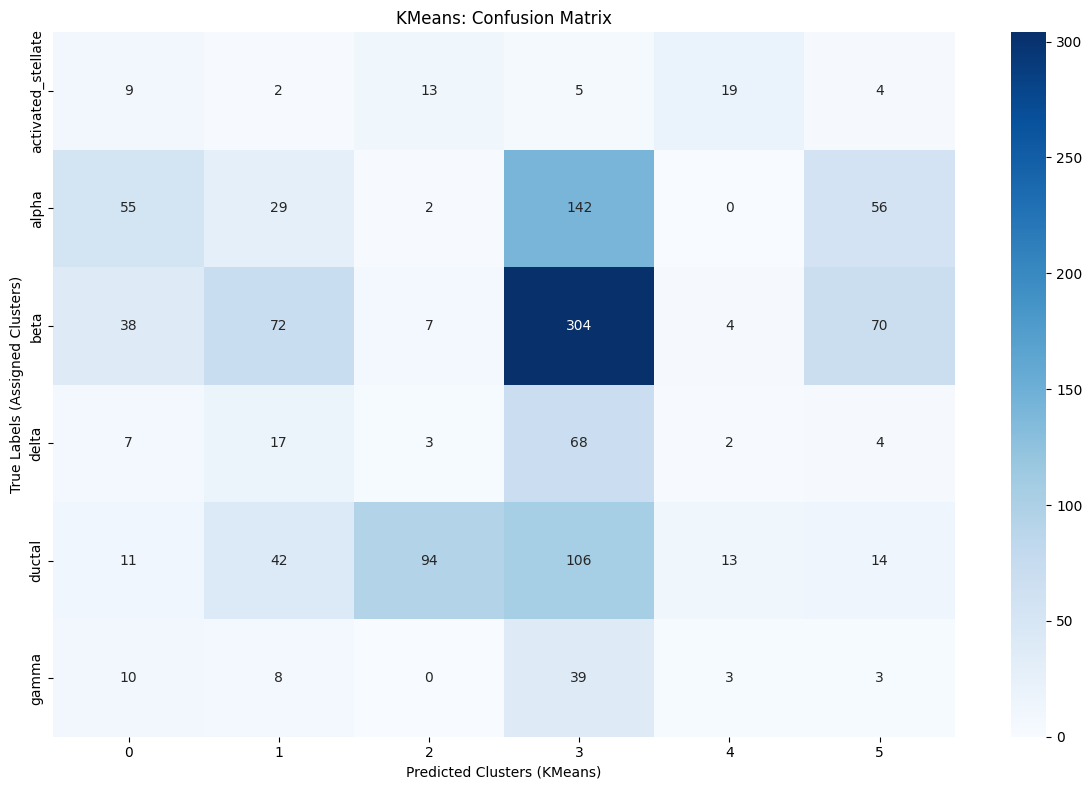

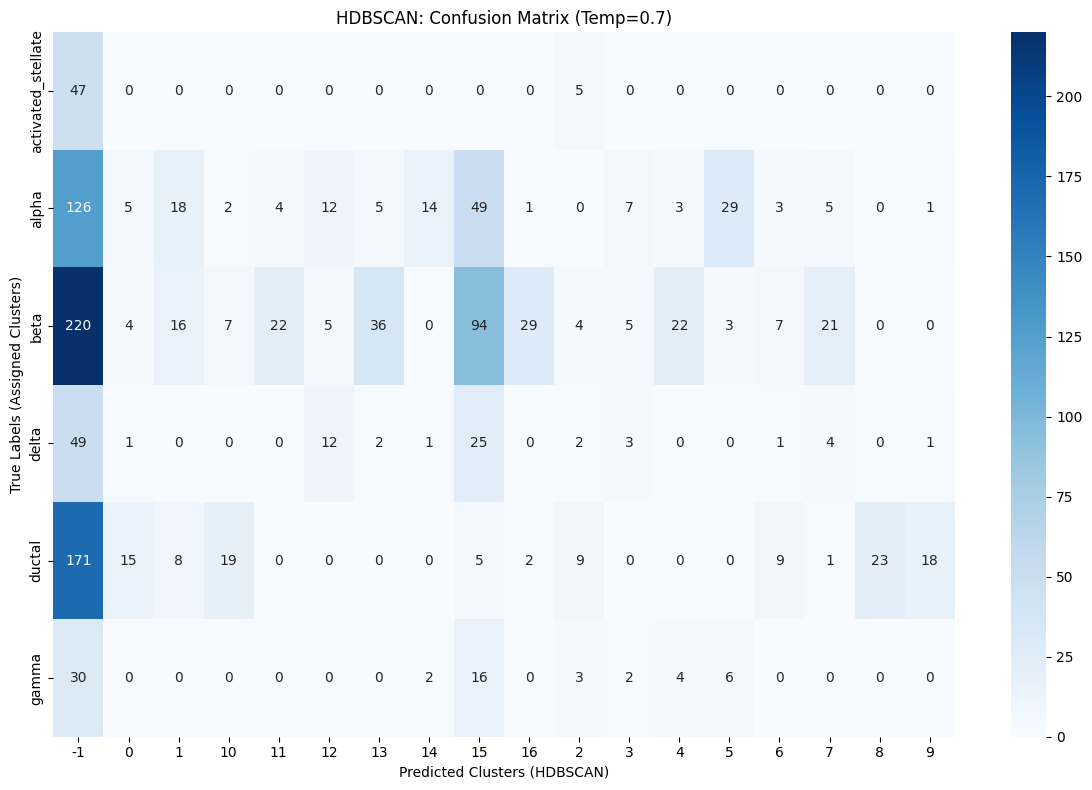

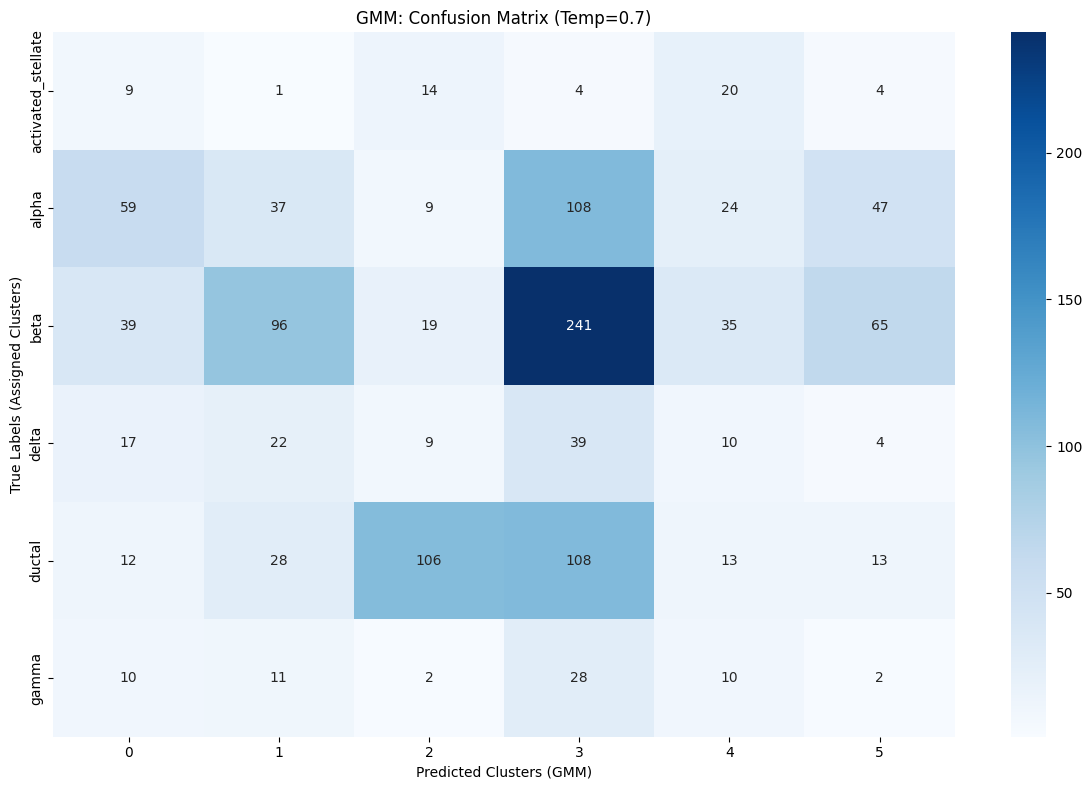

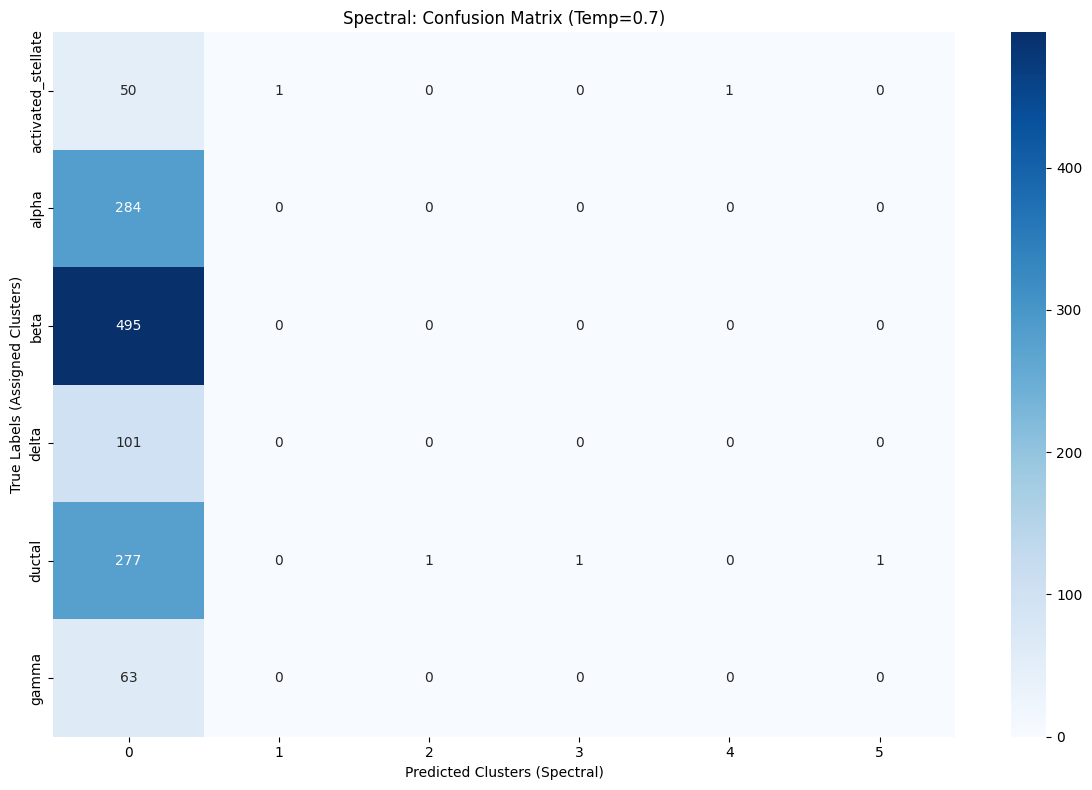

[INFO] Calculating pathway attribution per cluster...
[INFO] Pathway attribution completed.

Cluster 0 (130 cells):
  Amplification of signal from the kinetochores: 0.289 (p=0.000) ***
  EML4 and NUDC in mitotic spindle formation: 0.218 (p=0.000) ***
  GPCR ligand binding: 0.114 (p=0.000) ***
  Adherens junctions interactions: 0.062 (p=0.009) **
  Biological oxidations: 0.059 (p=0.005) **

Cluster 1 (170 cells):
  Extra-nuclear estrogen signaling: 0.369 (p=0.000) ***
  Axon guidance: 0.181 (p=0.000) ***
  Signaling by Rho GTPases, Miro GTPases and RHOBTB3: 0.164 (p=0.000) ***
  Transcriptional regulation by the AP-2 (TFAP2) family of transcription factors: 0.067 (p=0.001) ***
  M Phase: 0.038 (p=0.006) **

Cluster 2 (119 cells):
  Initiation of coagulation cascade: 0.533 (p=0.000) ***
  Chemokine receptors bind chemokines: 0.077 (p=0.001) ***
  Metabolism: 0.067 (p=0.012) *
  Collagen biosynthesis and modifying enzymes: 0.063 (p=0.003) **
  Formation of the cornified envelope: 0.054 (p

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: 

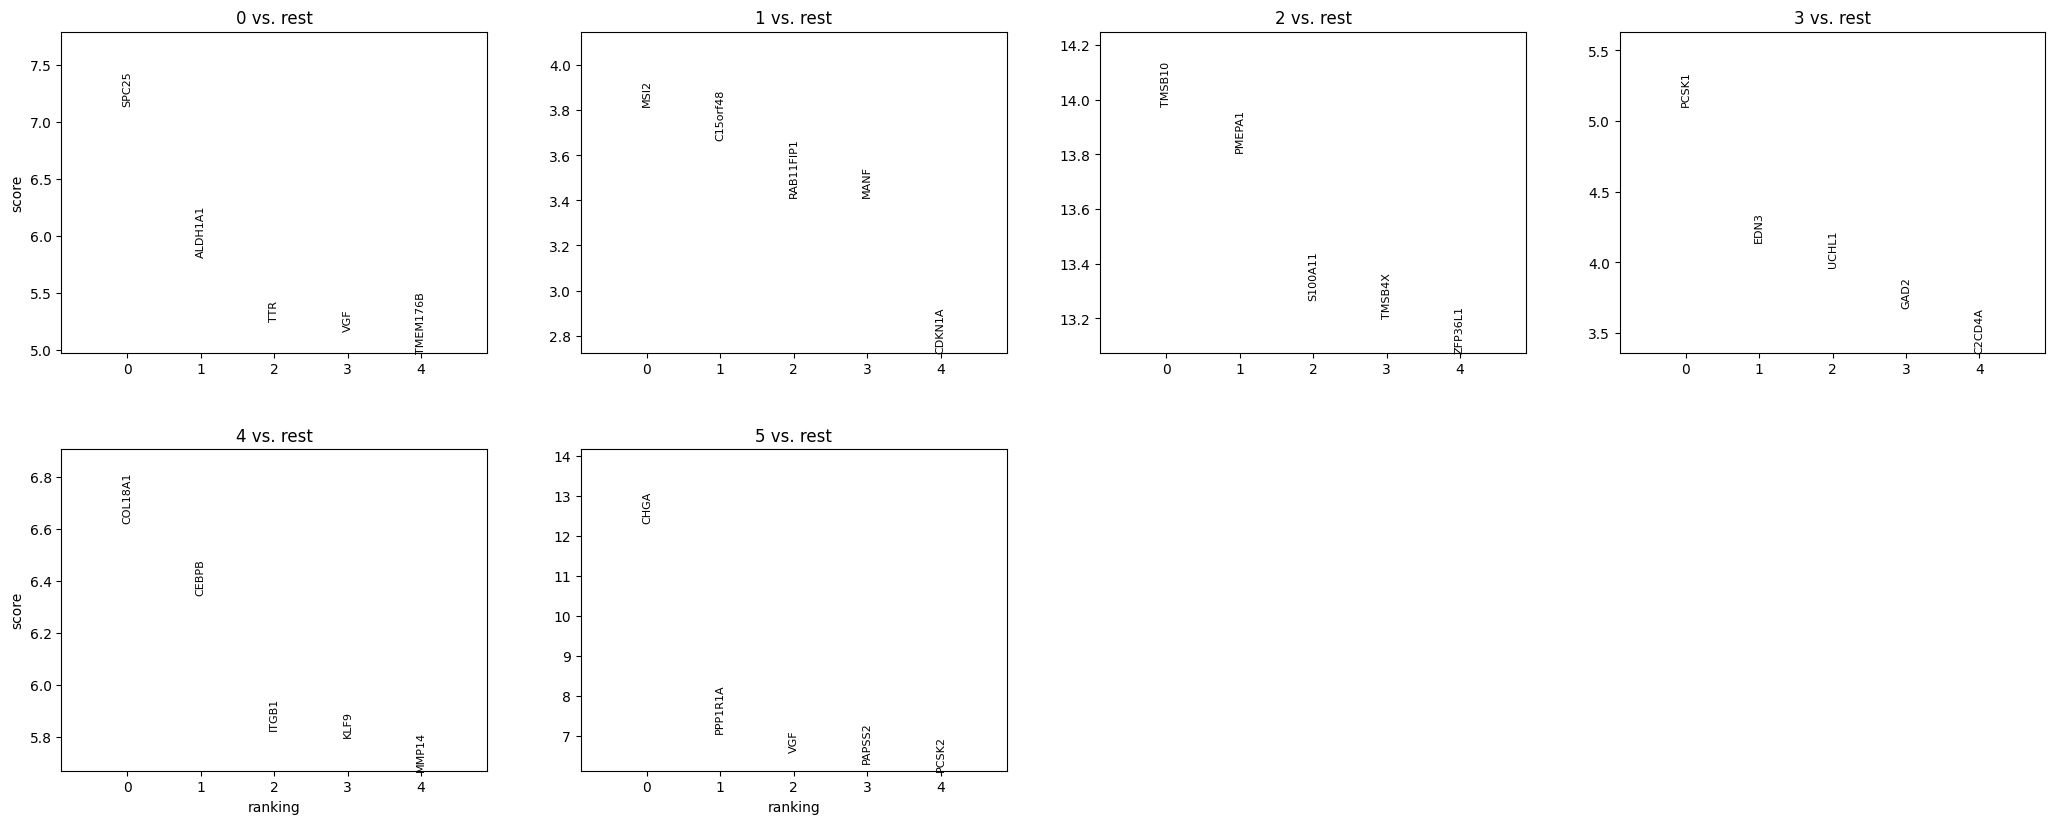


Cluster 0 top marker genes:
  SPC25: logFC=nan, adj.p=1.82e-09 ***
  ALDH1A1: logFC=nan, adj.p=5.99e-06 ***
  TTR: logFC=nan, adj.p=9.92e-05 ***
  VGF: logFC=nan, adj.p=0.000123 ***
  TMEM176B: logFC=nan, adj.p=0.000264 ***

Cluster 1 top marker genes:
  MSI2: logFC=nan, adj.p=0.246 
  C15orf48: logFC=nan, adj.p=0.246 
  RAB11FIP1: logFC=nan, adj.p=0.319 
  MANF: logFC=nan, adj.p=0.319 
  CDKN1A: logFC=nan, adj.p=1 

Cluster 2 top marker genes:
  TMSB10: logFC=nan, adj.p=4.24e-41 ***
  PMEPA1: logFC=nan, adj.p=2.23e-40 ***
  S100A11: logFC=nan, adj.p=2.39e-37 ***
  TMSB4X: logFC=nan, adj.p=4.23e-37 ***
  ZFP36L1: logFC=nan, adj.p=1.79e-36 ***

Cluster 3 top marker genes:
  PCSK1: logFC=nan, adj.p=7.07e-06 ***
  EDN3: logFC=nan, adj.p=0.00038 ***
  UCHL1: logFC=nan, adj.p=0.000722 ***
  GAD2: logFC=nan, adj.p=0.00208 **
  C2CD4A: logFC=nan, adj.p=0.0054 **

Cluster 4 top marker genes:
  COL18A1: logFC=nan, adj.p=7.13e-08 ***
  CEBPB: logFC=nan, adj.p=2.23e-07 ***
  ITGB1: logFC=nan, ad

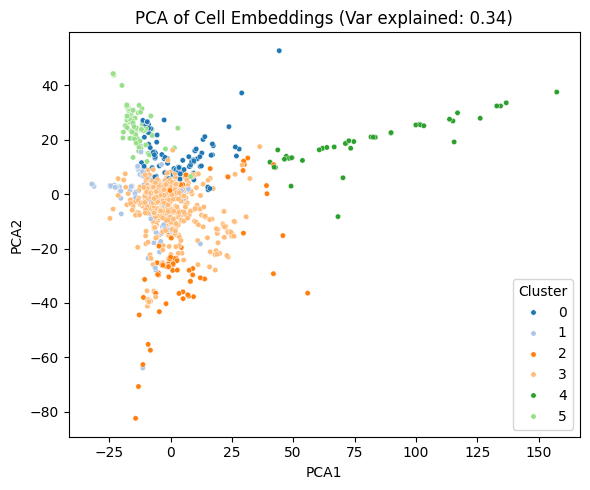

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_9420/2944854466.py:549: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


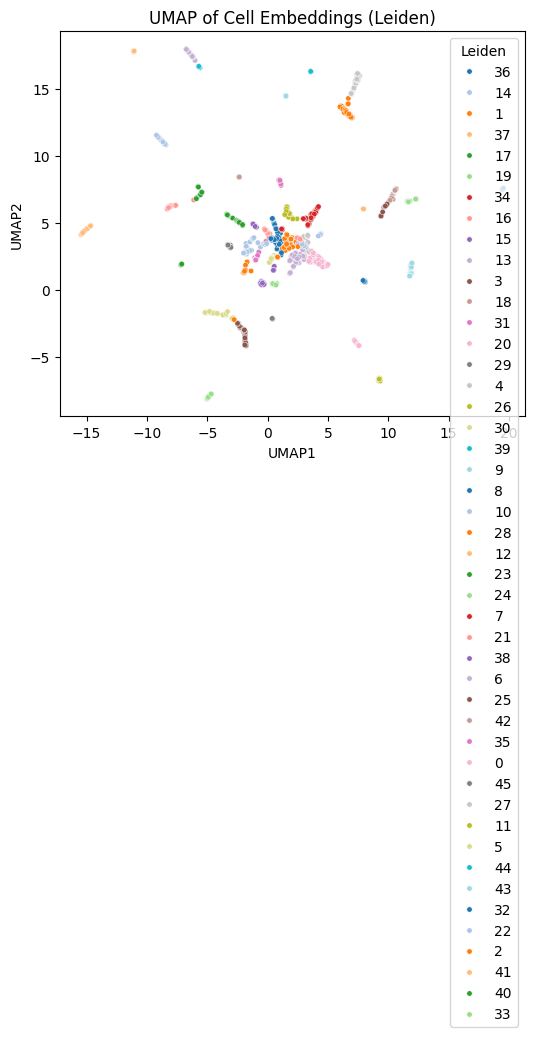

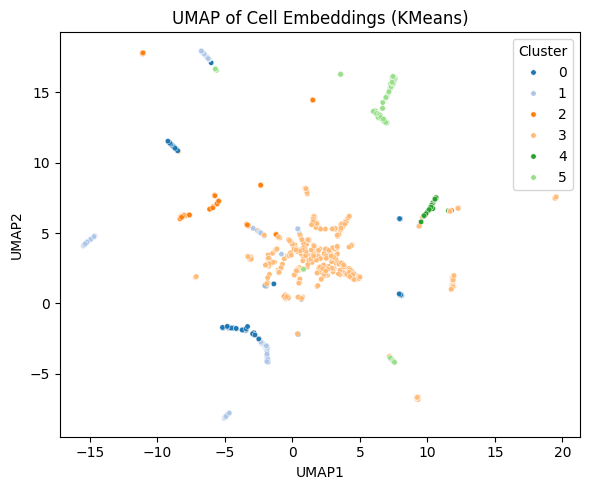

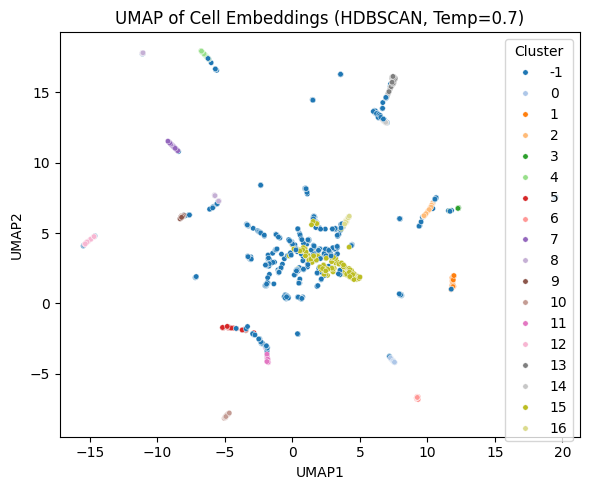

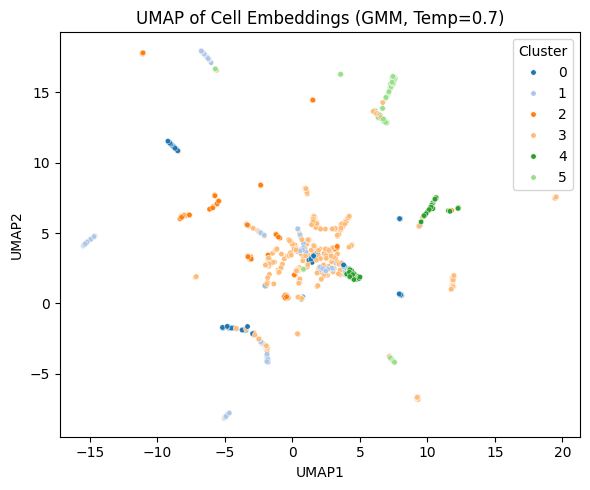

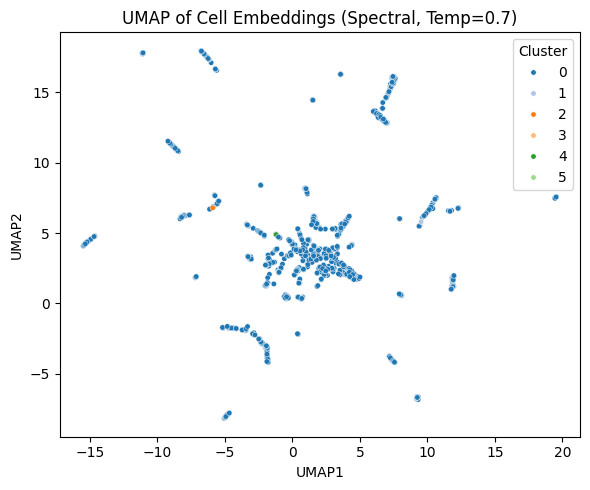

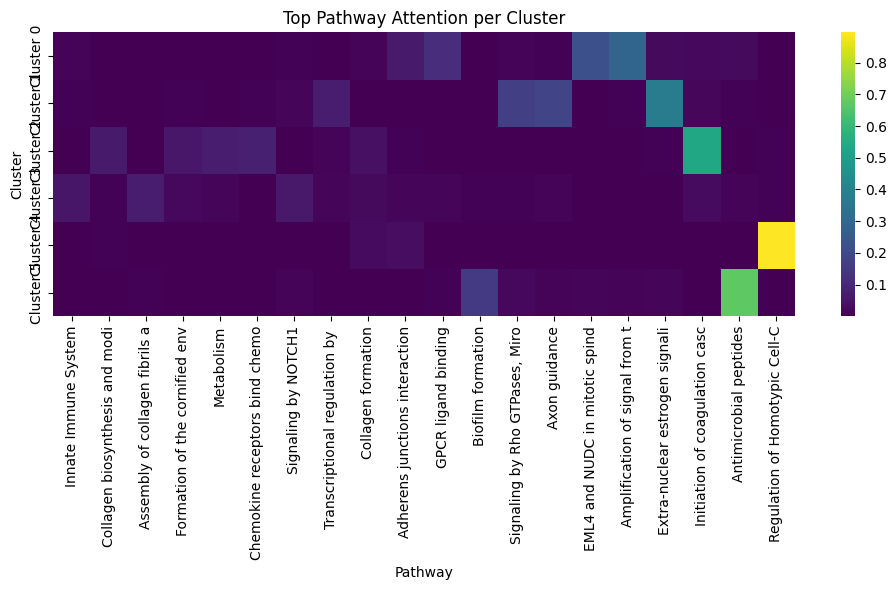

[INFO] Visualizations completed.

[SUCCESS] Downstream analysis completed using loaded GNN results.


In [19]:
# @title
#Cell containing Hdbscan Kmeans and Leiden
import numpy as np
import pickle
import os

def run_clustering_and_analysis_from_saved_data(
    output_dir,
    n_clusters=None, # Set to None for automatic cluster number for KMeans
    top_n_pathways=5,
    top_n_marker_genes=5
):
    print(f"[INFO] Loading GNN results from: {output_dir}")

    # Load saved data
    try:
        final_emb = np.load(os.path.join(output_dir, 'final_emb.npy'))
        attn_weights = np.load(os.path.join(output_dir, 'attn_weights.npy'))
        with open(os.path.join(output_dir, 'pathway_names.pkl'), 'rb') as f:
            pathway_names = pickle.load(f)
        with open(os.path.join(output_dir, 'cells.pkl'), 'rb') as f:
            cells = pickle.load(f)
        adata = sc.read_h5ad(os.path.join(output_dir, 'adata.h5ad'))
        with open(os.path.join(output_dir, 'current_temperature.txt'), 'r') as f:
            current_temperature = float(f.read().strip())
    except FileNotFoundError as e:
        print(f"[ERROR] Could not find saved GNN output files: {e}")
        print("Please ensure the 'output_dir' is correct and the previous cell ran successfully.")
        return
    except Exception as e:
        print(f"[ERROR] An error occurred while loading files: {e}")
        return

    print("[INFO] GNN results loaded successfully. Proceeding with analysis...")

    print(f"\n====== Results for Temperature={current_temperature} ======")

    # 1. Clustering and Evaluation
    leiden_labels, kmeans_labels, hdbscan_labels, gmm_labels, spectral_labels, best_res, leiden_sil, kmeans_sil, hdbscan_sil, gmm_sil, spectral_sil = cluster_and_eval_scanpy(
        final_emb, cells, adata, n_clusters=n_clusters, current_temperature=current_temperature
    )

    # 2. Pathway Attribution
    cluster_results = pathway_attribution(attn_weights, pathway_names, kmeans_labels, cells, top_n=top_n_pathways)
    print_cluster_pathways(cluster_results, kmeans_labels, cells)

    # 3. Marker Gene Enrichment using Scanpy
    print("[INFO] Running marker gene analysis with Scanpy (Wilcoxon test)...")
    adata.obs["cluster"] = kmeans_labels.astype(str) # Add KMeans labels to adata for marker gene analysis
    sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon", use_raw=False)
    sc.pl.rank_genes_groups(adata, n_genes=top_n_marker_genes, sharey=False)
    markers_df = sc.get.rank_genes_groups_df(adata, group=None)
    for c in sorted(adata.obs["cluster"].unique()):
        top_genes = markers_df[markers_df["group"] == c].head(top_n_marker_genes)
        print(f"\nCluster {c} top marker genes:")
        for _, row in top_genes.iterrows():
            sig = (
                "***" if row["pvals_adj"] < 0.001 else
                "**" if row["pvals_adj"] < 0.01 else
                "*" if row["pvals_adj"] < 0.05 else ""
            )
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, adj.p={row['pvals_adj']:.3g} {sig}")

    # 4. Visualizations
    visualize(final_emb, kmeans_labels, attn_weights, pathway_names, cells, leiden_labels, hdbscan_labels, gmm_labels, spectral_labels, current_temperature=current_temperature)

    print("\n[SUCCESS] Downstream analysis completed using loaded GNN results.")


# --- Example usage of the analysis function ---
# **UPDATE THIS PATH TO YOUR OUTPUT DIRECTORY DEFINED IN THE PREVIOUS CELL**
analysis_output_dir = '/content/drive/MyDrive/Pathway GNN Project/gnn_output/'

run_clustering_and_analysis_from_saved_data(
    output_dir=analysis_output_dir,
    n_clusters="unique", # Example: 7, or "unique", or None for automatic determination
    top_n_pathways=5,
    top_n_marker_genes=5
)

In [10]:
!pip install scikit-misc

**Experimenting Clustering Methods**

In [9]:
!pip install consensusclustering

In [34]:
!pip install ConsensusClusterPlus

ERROR: Could not find a version that satisfies the requirement ConsensusClusterPlus (from versions: none)
ERROR: No matching distribution found for ConsensusClusterPlus


**Trying Consensus Clustering**

In [35]:
# @title
import numpy as np
import pickle
import os
import pandas as pd
import scanpy as sc
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from consensusclustering.cluster import ConsensusCluster
def run_clustering_and_analysis_from_saved_data(
    output_dir,
    n_clusters=None, # Set to None for automatic cluster number for KMeans
    top_n_pathways=5,
    top_n_marker_genes=5
):
    print(f"[INFO] Loading GNN results from: {output_dir}")

    # Load saved data
    try:
        final_emb = np.load(os.path.join(output_dir, 'final_emb.npy'))
        attn_weights = np.load(os.path.join(output_dir, 'attn_weights.npy'))
        with open(os.path.join(output_dir, 'pathway_names.pkl'), 'rb') as f:
            pathway_names = pickle.load(f)
        with open(os.path.join(output_dir, 'cells.pkl'), 'rb') as f:
            cells = pickle.load(f)
        adata = sc.read_h5ad(os.path.join(output_dir, 'adata.h5ad'))
        with open(os.path.join(output_dir, 'current_temperature.txt'), 'r') as f:
            current_temperature = float(f.read().strip())
    except FileNotFoundError as e:
        print(f"[ERROR] Could not find saved GNN output files: {e}")
        print("Please ensure the 'output_dir' is correct and the previous cell ran successfully.")
        return
    except Exception as e:
        print(f"[ERROR] An error occurred while loading files: {e}")
        return

    print("[INFO] GNN results loaded successfully. Proceeding with analysis...")

    print(f"\n====== Results for Temperature={current_temperature} ======")

    # 1. Clustering and Evaluation (existing methods)
    leiden_labels, kmeans_labels, hdbscan_labels, gmm_labels, spectral_labels, best_res, leiden_sil, kmeans_sil, hdbscan_sil, gmm_sil, spectral_sil = cluster_and_eval_scanpy(
        final_emb, cells, adata, n_clusters=n_clusters, current_temperature=current_temperature
    )

    # --- NEW: Consensus Clustering on final_emb ---
    print("\n[INFO] Running Consensus Clustering...")
    n_runs = 10 # Number of KMeans runs for consensus
    k_consensus = n_clusters if isinstance(n_clusters, int) else 7 # Use determined n_clusters or a default

    if k_consensus <= 1: # Consensus clustering requires more than 1 cluster
        print(f"[WARNING] Cannot perform consensus clustering with {k_consensus} clusters. Skipping.")
        consensus_labels = np.zeros(final_emb.shape[0], dtype=int)
    else:
        partitions = []
        for i in range(n_runs):
            kmeans = KMeans(n_clusters=k_consensus, random_state=i, n_init=10) # n_init for robust initialization
            partitions.append(kmeans.fit_predict(final_emb))

        # Initialize ConsensusCluster with the desired number of clusters
        cc = ConsensusCluster(n_clusters=k_consensus, reps=n_runs)
        consensus_labels = cc.fit_predict(final_emb, partitions)
        consensus_silhouette = silhouette_score(final_emb, consensus_labels)
        print(f"[INFO] Consensus Clustering found {len(np.unique(consensus_labels))} clusters, silhouette={consensus_silhouette:.3f}")

        # Add consensus labels to adata
        adata.obs['consensus_cluster'] = pd.Categorical(consensus_labels.astype(str))

        # Visualize Consensus Clusters with UMAP
        reducer = umap.UMAP(n_components=2, random_state=42)
        umap_proj = reducer.fit_transform(final_emb)
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=adata.obs['consensus_cluster'], palette='tab20', s=15)
        plt.title("UMAP of Cell Embeddings (Consensus Clustering)")
        plt.legend(title="Consensus Cluster")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.show()

    # 2. Pathway Attribution (uses KMeans labels by default in this pipeline)
    cluster_results = pathway_attribution(attn_weights, pathway_names, kmeans_labels, cells, top_n=top_n_pathways)
    print_cluster_pathways(cluster_results, kmeans_labels, cells)

    # --- NEW: Hierarchical Clustering over Pathways ---
    print("\n[INFO] Running Hierarchical Clustering over Pathways...")
    # Use the cluster_attention_matrix (average attention of pathways per cell cluster)
    attention_df = pd.DataFrame(attn_weights, index=cells, columns=pathway_names)
    # Ensure we use labels that are actually present in adata.obs for consistent clustering
    if 'assigned_cluster' in adata.obs and adata.obs['assigned_cluster'].nunique() > 1:
        labels_for_agg = adata.obs.loc[cells, 'assigned_cluster'].astype(str) # Use true labels if available
    else:
        labels_for_agg = pd.Series(kmeans_labels.astype(str), index=cells) # Fallback to KMeans labels

    valid_clusters = labels_for_agg.unique()
    valid_clusters = [c for c in valid_clusters if c != 'NA'] # Exclude 'NA' if present from reindex/fillna
    valid_clusters.sort()

    cluster_attention_matrix_for_pathways = []
    for cluster in valid_clusters:
        cluster_cells = labels_for_agg[labels_for_agg == cluster].index
        if not cluster_cells.empty:
            cluster_attention_matrix_for_pathways.append(attention_df.loc[cluster_cells].mean().values)

    if not cluster_attention_matrix_for_pathways or len(pathway_names) < 2: # Need at least 2 pathways to cluster
        print("[WARNING] Not enough data or pathways to perform hierarchical clustering over pathways. Skipping.")
    else:
        cluster_attention_matrix_for_pathways = np.array(cluster_attention_matrix_for_pathways)

        # Transpose matrix to have pathways as rows and cluster attention as features
        pathway_features = cluster_attention_matrix_for_pathways.T

        # Perform hierarchical clustering
        # Using correlation distance as a common metric for expression/activity profiles
        # or 'euclidean' if the absolute values are important.
        # 'average' linkage is a good default.
        linked = linkage(pdist(pathway_features, metric='euclidean'), method='average')

        plt.figure(figsize=(10, len(pathway_names) * 0.3)) # Adjust figure size dynamically
        dendrogram(
            linked,
            orientation='left',
            labels=pathway_names,
            distance_sort='descending',
            show_leaf_counts=True
        )
        plt.title('Hierarchical Clustering of Pathways based on Cluster Attention')
        plt.xlabel('Distance')
        plt.ylabel('Pathway')
        plt.tight_layout()
        plt.show()

    # 3. Marker Gene Enrichment using Scanpy
    print("[INFO] Running marker gene analysis with Scanpy (Wilcoxon test)...")
    adata.obs["cluster"] = kmeans_labels.astype(str) # Add KMeans labels to adata for marker gene analysis
    sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon", use_raw=False)
    sc.pl.rank_genes_groups(adata, n_genes=top_n_marker_genes, sharey=False)
    markers_df = sc.get.rank_genes_groups_df(adata, group=None)
    for c in sorted(adata.obs["cluster"].unique()):
        top_genes = markers_df[markers_df["group"] == c].head(top_n_marker_genes)
        print(f"\nCluster {c} top marker genes:")
        for _, row in top_genes.iterrows():
            sig = (
                "***" if row["pvals_adj"] < 0.001 else
                "**" if row["pvals_adj"] < 0.01 else
                "*" if row["pvals_adj"] < 0.05 else ""
            )
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, adj.p={row['pvals_adj']:.3g} {sig}")

    # 4. Visualizations
    visualize(final_emb, kmeans_labels, attn_weights, pathway_names, cells, leiden_labels, hdbscan_labels, gmm_labels, spectral_labels, current_temperature=current_temperature)

    print("\n[SUCCESS] Downstream analysis completed using loaded GNN results.")


# --- Example usage of the analysis function ---
# **UPDATE THIS PATH TO YOUR OUTPUT DIRECTORY DEFINED IN THE PREVIOUS CELL**
analysis_output_dir = '/content/drive/MyDrive/Pathway GNN Project/gnn_output/'

run_clustering_and_analysis_from_saved_data(
    output_dir=analysis_output_dir,
    n_clusters="unique", # Example: 7, or "unique", or None for automatic determination
    top_n_pathways=5,
    top_n_marker_genes=5
)

ModuleNotFoundError: No module named 'consensusclustering.cluster'

**Custom Number of Pathways- Pathway-GNN**

[INFO] Using device: cuda
[INFO] Loading expression matrix...
[INFO] Before fixing: 0 duplicate cell names
[INFO] Before fixing: 0 duplicate gene names
[INFO] After fixing: 0 duplicate cell names
[INFO] After fixing: 0 duplicate gene names
[INFO] Removed rare cell types (<50 cells). 1303 → 1275 cells kept.
[INFO] Preprocessing with SCTransform-like workflow...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:246: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Preprocessing completed.
[INFO] Parsing pathway file...
[INFO] Pathway parsing completed. Filtered pathways: 327
[INFO] Further filtered to 60 pathways after selection.
[INFO] Building bipartite graphs (thresholded + optional top-k fallback)...
  [INFO] Activation of Matrix Metalloproteinases: 16 genes, 283 edges
  [INFO] Activation of NMDA receptors and postsynaptic events: 10 genes, 439 edges
  [INFO] Activation of STAT3 by cadherin engagement: 11 genes, 521 edges
  [INFO] Adaptive Immune System: 87 genes, 2304 edges
  [INFO] Adherens junctions interactions: 34 genes, 964 edges
  [INFO] Adipogenesis: 15 genes, 352 edges
  [INFO] Amplification  of signal from unattached  kinetochores via a MAD2  inhibitory signal: 12 genes, 154 edges
  [INFO] Amplification of signal from the kinetochores: 12 genes, 154 edges
  [INFO] Amyloid fiber formation: 13 genes, 442 edges
  [INFO] Antigen processing: Ubiquitination & Proteasome degradation: 12 genes, 295 edges
  [INFO] Antimicrobial mecha

/tmp/ipykernel_8832/4074994093.py:307: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'gnn_leiden_{res}')
/tmp/ipykernel_8832/4074994093.py:309: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_8832/4074994093.py:307: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend f

[INFO] Leiden res=0.20, clusters=16, silhouette=0.313


...

[INFO] Leiden res=1.20, clusters=31, silhouette=0.333


/tmp/ipykernel_8832/4074994093.py:309: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_8832/4074994093.py:307: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'gnn_leiden_{res}')


[INFO] Leiden res=1.50, clusters=35, silhouette=0.366


/tmp/ipykernel_8832/4074994093.py:309: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]


[INFO] Leiden res=2.00, clusters=39, silhouette=0.291
[INFO] Best Leiden resolution=1.5, silhouette=0.366
[INFO] Using unique assigned clusters: n_clusters=6
[INFO] KMeans n=6, silhouette=0.570
[INFO] Running HDBSCAN clustering...
[INFO] HDBSCAN found 16 clusters (excluding noise points labeled -1).
[INFO] HDBSCAN silhouette (non-noise points): 0.807
[INFO] Clustering metrics:
  Leiden ARI: 0.053
  Leiden NMI: 0.203
  Leiden AMI: 0.178
  Leiden Silhouette: 0.366
  KMeans ARI: 0.068
  KMeans NMI: 0.148
  KMeans AMI: 0.142
  KMeans Silhouette: 0.570
  HDBSCAN ARI: 0.036
  HDBSCAN NMI: 0.159
  HDBSCAN AMI: 0.143
  HDBSCAN Silhouette: 0.807


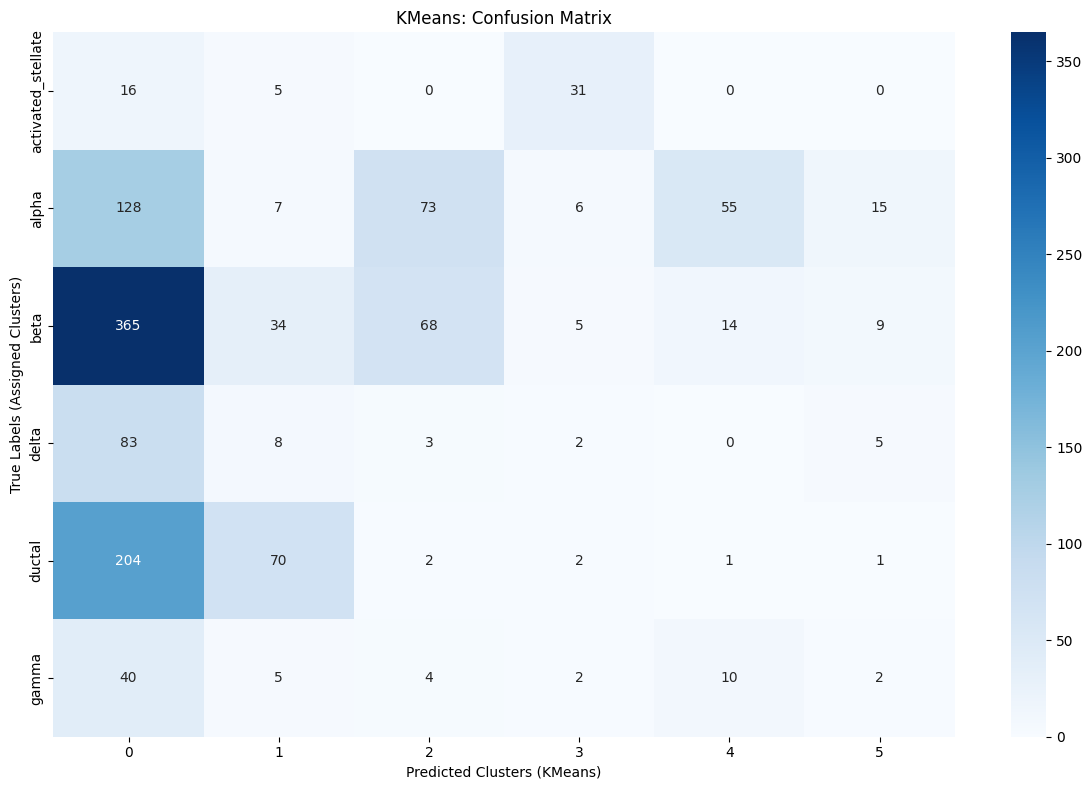

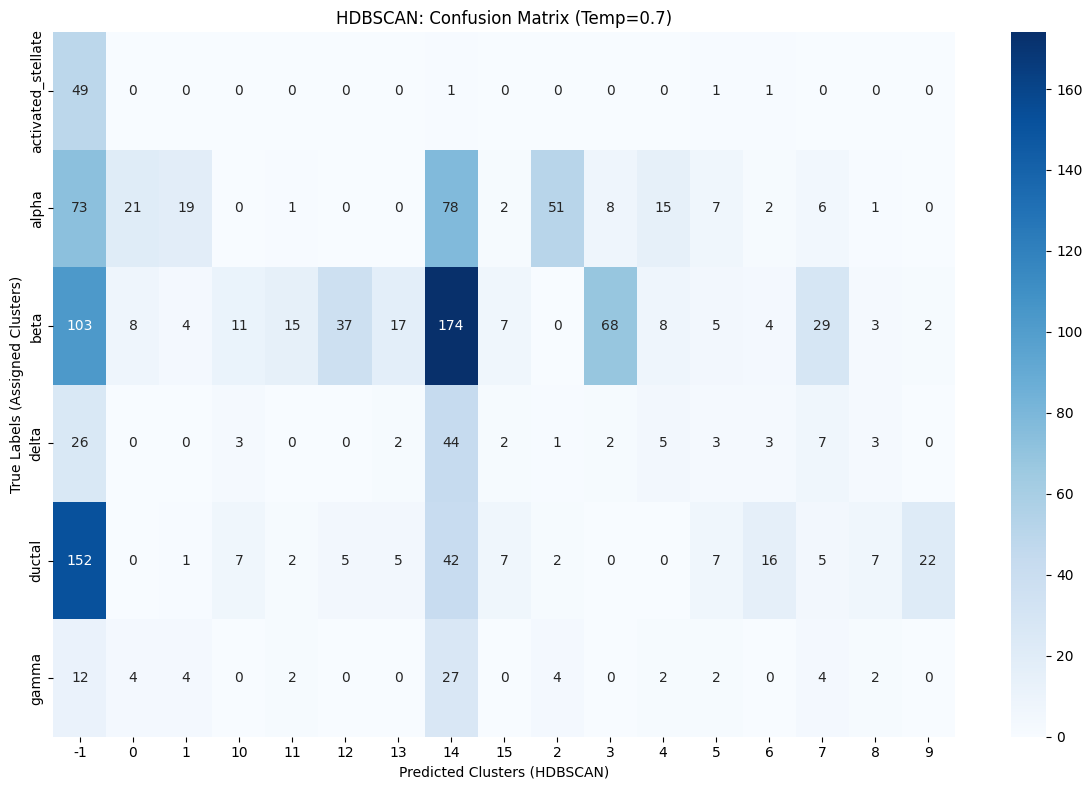

[INFO] Calculating pathway attribution per cluster...
[INFO] Pathway attribution completed.

Cluster 0 (836 cells):
  Biological oxidations: 0.068 (p=0.000) ***
  Amyloid fiber formation: 0.058 (p=0.000) ***
  Antigen processing: Ubiquitination & Proteasome degradation: 0.044 (p=0.033) *
  Class I MHC mediated antigen processing & presentation: 0.040 (p=0.000) ***
  Constitutive Signaling by Aberrant PI3K in Cancer: 0.040 (p=0.000) ***

Cluster 1 (129 cells):
  Co-inhibition by PD-1: 0.465 (p=0.000) ***
  Constitutive Signaling by Aberrant PI3K in Cancer: 0.462 (p=0.000) ***
  Cell-Cell communication: 0.050 (p=0.044) *
  Collagen formation: 0.018 (p=0.001) ***
  Adherens junctions interactions: 0.002 (p=0.000) ***

Cluster 2 (150 cells):
  Antimicrobial peptides: 0.980 (p=0.000) ***
  Constitutive Signaling by Aberrant PI3K in Cancer: 0.008 (p=0.000) ***
  Antigen processing: Ubiquitination & Proteasome degradation: 0.007 (p=0.000) ***
  Crosslinking of collagen fibrils: 0.002 (p=0.000

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: 

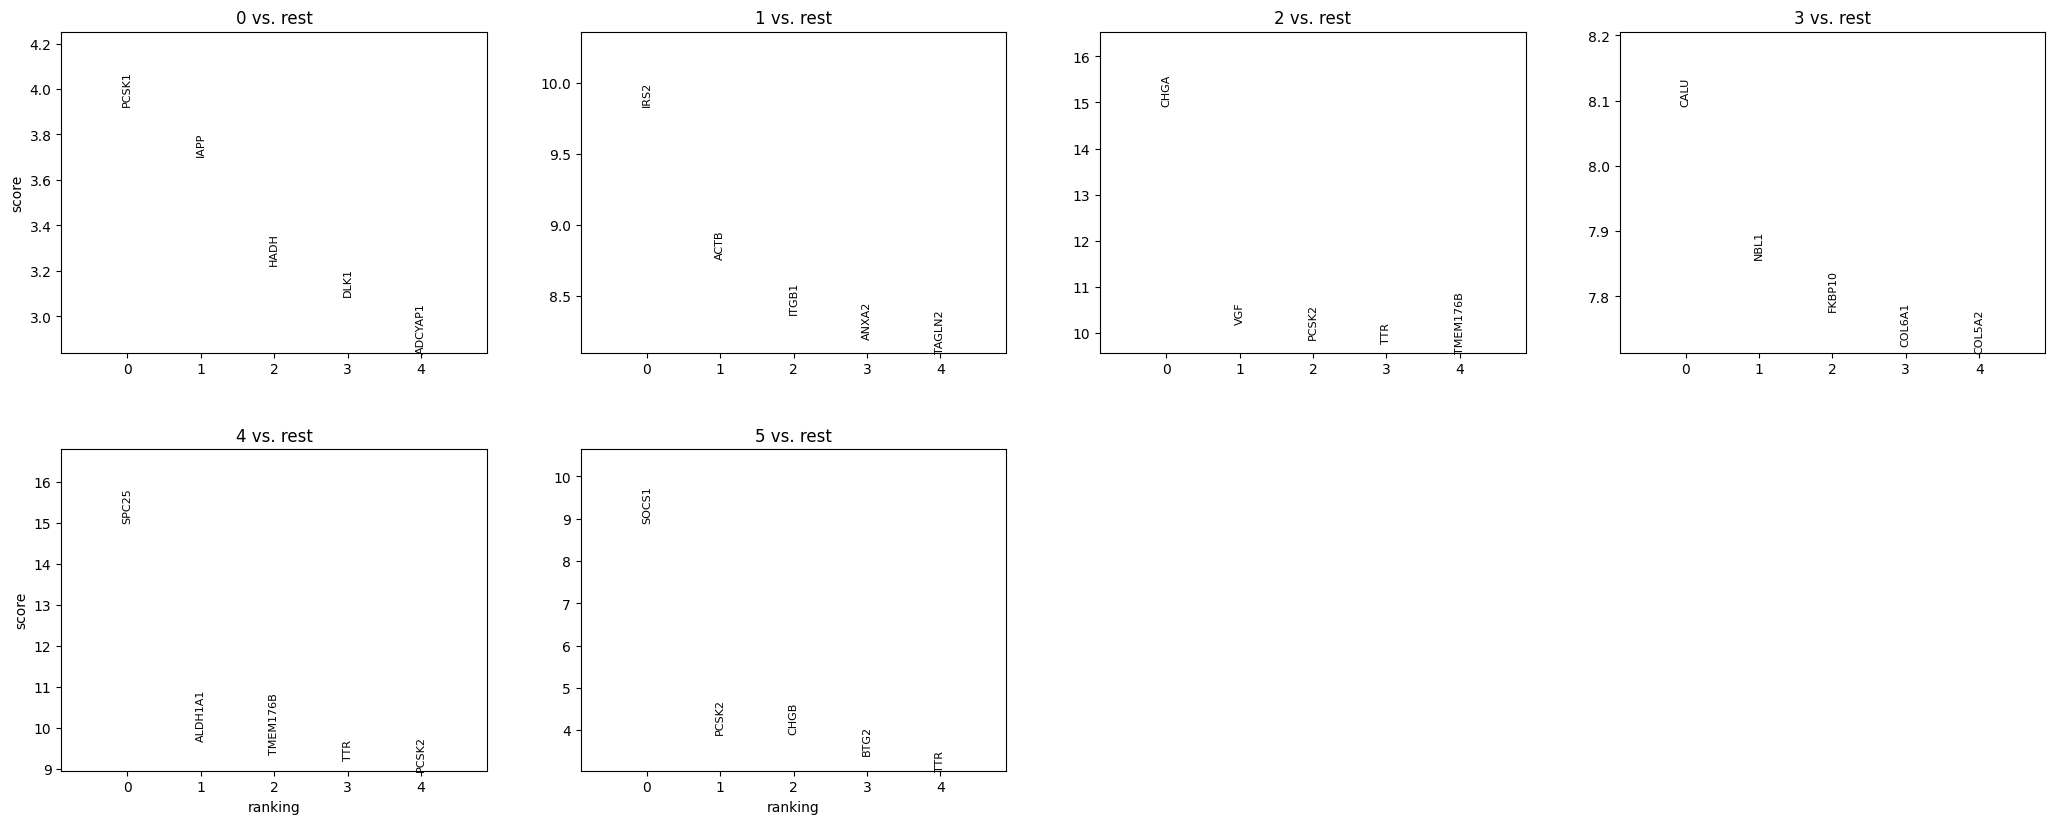


Cluster 0 top marker genes:
  PCSK1: logFC=nan, adj.p=0.00243 **
  IAPP: logFC=nan, adj.p=0.00507 **
  HADH: logFC=nan, adj.p=0.0214 *
  DLK1: logFC=nan, adj.p=0.0308 *
  ADCYAP1: logFC=nan, adj.p=0.0609 

Cluster 1 top marker genes:
  IRS2: logFC=nan, adj.p=1.51e-19 ***
  ACTB: logFC=nan, adj.p=2.05e-15 ***
  ITGB1: logFC=nan, adj.p=3.76e-14 ***
  ANXA2: logFC=nan, adj.p=1.26e-13 ***
  TAGLN2: logFC=nan, adj.p=2.25e-13 ***

Cluster 2 top marker genes:
  CHGA: logFC=nan, adj.p=4.32e-47 ***
  VGF: logFC=nan, adj.p=1.93e-21 ***
  PCSK2: logFC=nan, adj.p=4.12e-20 ***
  TTR: logFC=nan, adj.p=6.53e-20 ***
  TMEM176B: logFC=nan, adj.p=4.27e-19 ***

Cluster 3 top marker genes:
  CALU: logFC=nan, adj.p=1.17e-12 ***
  NBL1: logFC=nan, adj.p=3.96e-12 ***
  FKBP10: logFC=nan, adj.p=4.9e-12 ***
  COL6A1: logFC=nan, adj.p=4.9e-12 ***
  COL5A2: logFC=nan, adj.p=4.9e-12 ***

Cluster 4 top marker genes:
  SPC25: logFC=nan, adj.p=2e-47 ***
  ALDH1A1: logFC=nan, adj.p=4.27e-19 ***
  TMEM176B: logFC=nan

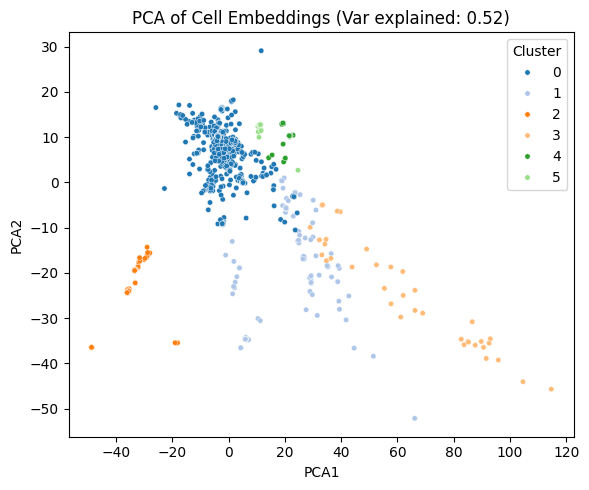

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


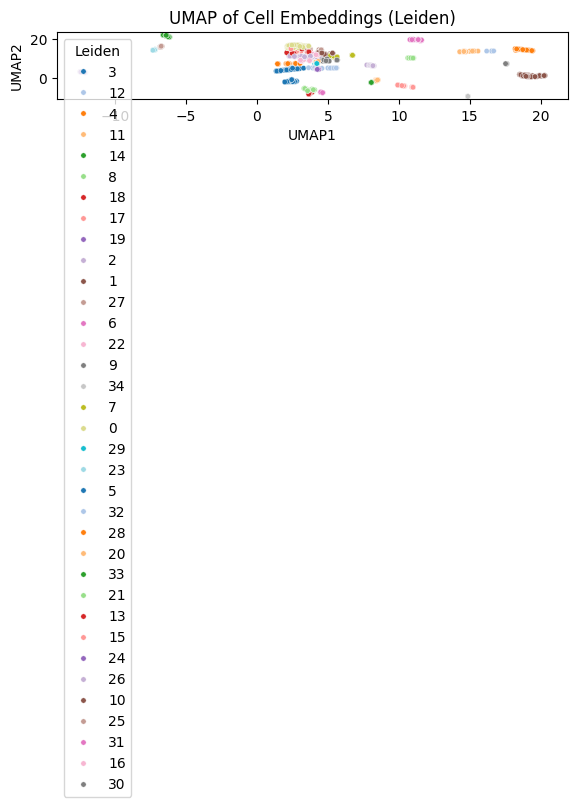

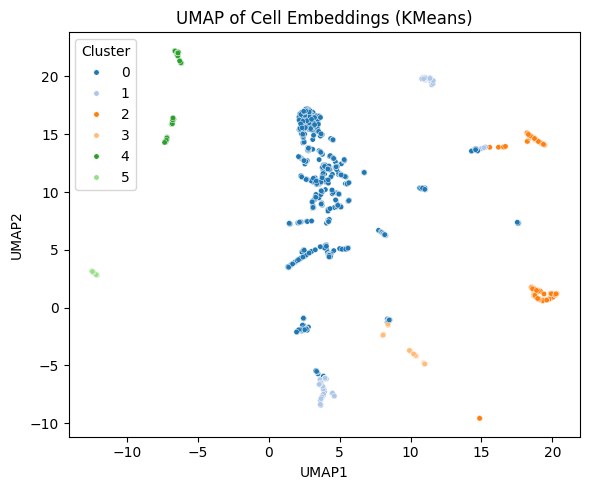

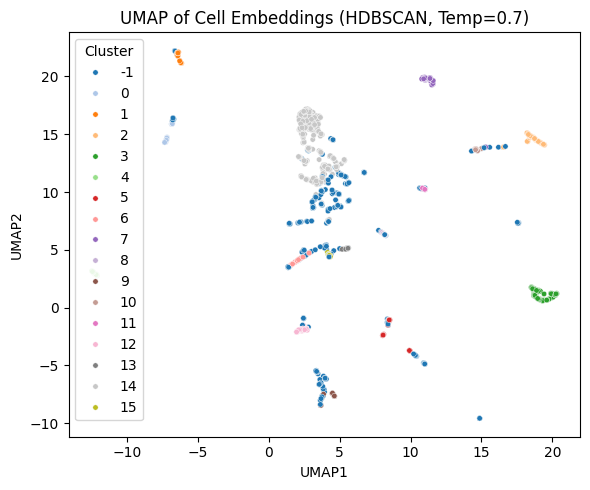

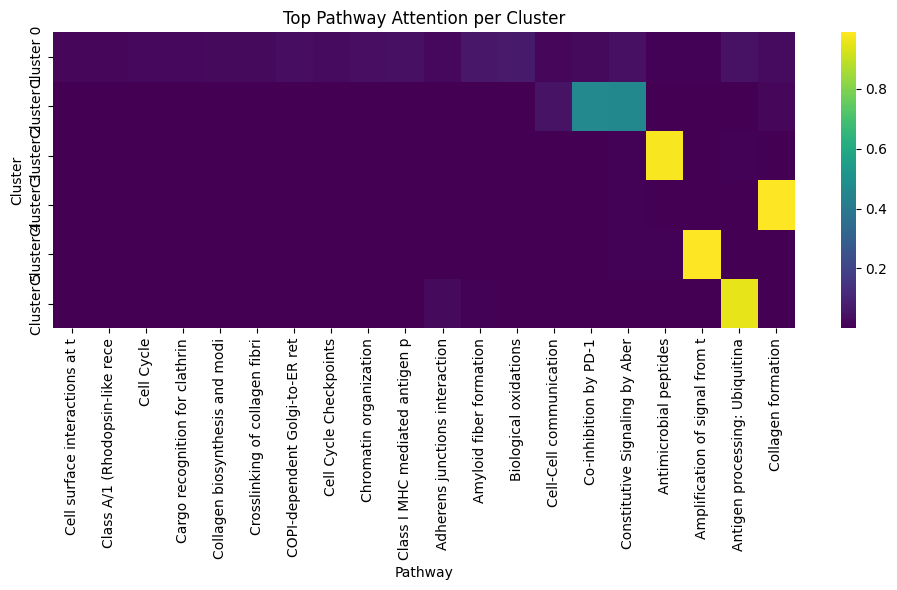

[INFO] Visualizations completed.


In [ ]:
# @title
import os
import hdbscan
# ---- DEVICE SETUP ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Using device:", device)

# ---- 1. SCTransform-like Preprocessing----
def preprocess_sctransform(adata, regress_vars=None, hvg_n=2000):
    print("[INFO] Preprocessing with SCTransform-like workflow...")
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=hvg_n)
    adata = adata[:, adata.var['highly_variable']]
    if regress_vars is not None:
        sc.pp.regress_out(adata, regress_vars)
    sc.pp.scale(adata)
    print("[INFO] Preprocessing completed.")
    return adata

def construct_pathway_bipartite_graphs(
    adata,
    pathway_genes,
    k=5,
    min_expression=0.25,          # absolute floor for expression to count as an edge
    gene_percentile=75,           # per-gene percentile threshold
    min_genes_required=5,         # skip pathways with < this many genes in data
    min_edges_per_gene=2,         # require at least this many edges per gene on avg
    fallback_topk=True            # if too sparse, rescue with top-k per cell
):
    """
    Build bipartite graphs (genes ↔ cells) per pathway using selective edges:
      - add an edge gene⊕cell only if expression > max(gene-specific percentile, min_expression)
      - if graph is too sparse, optionally fall back to top-k per cell for that pathway
    """
    print("[INFO] Building bipartite graphs (thresholded + optional top-k fallback)...")
    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    graphs = {}

    for pathway_name, genes in pathway_genes.items():
        available_genes = [g for g in genes if g in expr.columns]
        if len(available_genes) < min_genes_required:
            continue

        G = nx.Graph()
        G.add_nodes_from(available_genes, bipartite=0, node_type='gene')
        G.add_nodes_from(expr.index, bipartite=1, node_type='cell')

        # ---- selective edges by threshold ----
        edges_added = 0
        for gene in available_genes:
            gene_expr = expr[gene]
            # robust per-gene threshold on non-zero values
            if (gene_expr > 0).sum() > 0:
                per_gene_thr = np.percentile(gene_expr[gene_expr > 0], gene_percentile)
            else:
                per_gene_thr = float('inf')  # no non-zero expression; skip adding edges

            thr = max(per_gene_thr, min_expression)

            # add edges for cells where expression is "meaningfully high"
            high_cells = gene_expr.index[gene_expr > thr]
            for cell in high_cells:
                val = gene_expr.loc[cell]
                # Handle both scalar and non-scalar cases
                val_scalar = val.iloc[0] if hasattr(val, 'iloc') else val
                if val_scalar > 0:
                    # weight can be raw or normalized; keep raw for interpretability
                    G.add_edge(gene, cell, weight=float(val_scalar))
                    edges_added += 1

        # ---- density check + fallback ----
        needed_edges = len(available_genes) * min_edges_per_gene
        if edges_added < needed_edges and fallback_topk:
            # rescue sparsity by adding top-k per cell
            pathway_expr = expr[available_genes].to_numpy()
            # normalize per cell to avoid scale dominance
            row_max = pathway_expr.max(axis=1, keepdims=True)
            row_max[row_max == 0] = 1.0
            norm_expr = pathway_expr / row_max

            for i, cell in enumerate(expr.index):
                cell_vec = norm_expr[i]
                # choose top-k genes among available genes (skip zeros)
                k_eff = min(k, (cell_vec > 0).sum()) if (cell_vec > 0).any() else 0
                if k_eff > 0:
                    top_idx = np.argpartition(cell_vec, -k_eff)[-k_eff:]
                    for gi in top_idx:
                        gene = available_genes[gi]
                        if not G.has_edge(gene, cell):
                            raw_val = pathway_expr[i, gi]  #raw_val = expr.at[cell, gene]
                            if raw_val > 0:
                                G.add_edge(gene, cell, weight=float(raw_val))
                                edges_added += 1

        if edges_added >= needed_edges:
            graphs[pathway_name] = G
            print(f"  [INFO] {pathway_name}: {len(available_genes)} genes, {edges_added} edges")
        else:
            # too sparse even after fallback; drop it
            pass

    print(f"[INFO] Graph building completed. Kept pathways: {len(graphs)}")
    return graphs

# ---- 3. Node Features: [mean, std, degree, type] + PCA profile (cells) + pathway membership (genes) ----
def node_features_bipartite_enhanced(G, expr, pathway_genes=None, pathway=None, n_pca=5):
    genes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'gene']
    cells = [n for n, d in G.nodes(data=True) if d['node_type'] == 'cell']

    # PCA for cells
    if len(genes) > 1 and len(cells) > 1:
        pca = PCA(n_components=min(n_pca, len(genes)))
        cell_pca = pca.fit_transform(expr.loc[cells, genes])
        pca_dim = cell_pca.shape[1]
    else:
        cell_pca = np.zeros((len(cells), n_pca))
        pca_dim = n_pca

    features = []
    # --- Genes ---
    for gene in genes:
        vals = expr[gene] if gene in expr.columns else np.zeros(len(cells))
        pathway_score = len(pathway_genes[pathway]) if pathway_genes and pathway else 0
        vec = [np.mean(vals), np.std(vals), G.degree(gene), 1, 0]  # base features
        vec += [pathway_score]                                     # pathway info
        vec += [0.0] * pca_dim                                     # pad PCA slots
        features.append(vec)

    # --- Cells ---
    for i, cell in enumerate(cells):
        vals = expr.loc[cell, genes] if cell in expr.index else np.zeros(len(genes))
        vec = [np.mean(vals), np.std(vals), G.degree(cell), 0, 1]  # base features
        vec += [0.0]                                               # dummy pathway score slot
        vec += list(cell_pca[i])                                   # real PCA profile
        features.append(vec)

    x = np.array(features, dtype=np.float32)
    return x, genes, cells

# ---- 4. Different Models ----
class UnifiedGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, gnn_type='gcn', heads=2):
        super().__init__()
        self.gnn_type = gnn_type.lower()
        self.heads = heads
        if self.gnn_type == 'gcn':
            self.conv1 = GCNConv(in_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, out_dim)
        elif self.gnn_type == 'sage':
            self.conv1 = SAGEConv(in_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, out_dim)
        elif self.gnn_type == 'gat':
            self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, concat=False)
            self.conv2 = GATConv(hidden_dim, out_dim, heads=heads, concat=False)
        else:
            raise ValueError("gnn_type must be one of: 'gcn', 'sage', 'gat'")

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# ---- 5. Contrastive Loss (with dropout-based augmentation) ----
def contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5):
    # Dropout-based augmentation
    mask = (torch.rand_like(cell_emb) > drop_prob).float()
    cell_emb_aug = cell_emb * mask
    N = cell_emb.shape[0]
    z1 = F.normalize(cell_emb, dim=1)
    z2 = F.normalize(cell_emb_aug, dim=1)
    representations = torch.cat([z1, z2], dim=0)
    similarity_matrix = torch.matmul(representations, representations.T)
    mask_eye = torch.eye(2*N, dtype=torch.bool, device=cell_emb.device)
    similarity_matrix = similarity_matrix.masked_fill(mask_eye, -9e15)
    positives = torch.cat([torch.diag(similarity_matrix, N), torch.diag(similarity_matrix, -N)], dim=0)
    negatives = similarity_matrix[~mask_eye].view(2*N, -1)
    logits = torch.cat([positives.unsqueeze(1), negatives], dim=1) / temperature
    labels = torch.zeros(2*N, dtype=torch.long, device=cell_emb.device)
    loss = F.cross_entropy(logits, labels)
    return loss.item(), loss

# ---- 6. Train GNNs only (early stopping) ----
def train_pathway_gnns(graphs, expr, pathway_genes, model_type='sage', hidden_dim=32, out_dim=16,
                       epochs=100, early_stop_patience=15, early_stop_delta=1e-4, device="cuda"):
    print(f"[INFO] Training GNNs ({model_type}) with contrastive loss and early stopping on {device}...")
    pathway_names = list(graphs.keys())
    cells_list = list(expr.index)
    pathway_embs = []

    for pathway in pathway_names:
        G = graphs[pathway]
        x, genes, cells = node_features_bipartite_enhanced(G, expr, pathway_genes, pathway)
        all_nodes = genes + cells
        node_to_idx = {n: i for i, n in enumerate(all_nodes)}
        edges = [(node_to_idx[a], node_to_idx[b]) for a, b in G.edges() if a in node_to_idx and b in node_to_idx]
        if not edges: continue

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)
        x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

        model = UnifiedGNN(x.shape[1], hidden_dim, out_dim, gnn_type=model_type).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        best_loss = float("inf")
        patience = 0

        for epoch in range(epochs):
            optimizer.zero_grad()
            emb = model(x_tensor, edge_index)
            cell_emb = emb[len(genes):]
            loss_val, loss = contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5)
            loss.backward()
            optimizer.step()

            if loss_val + early_stop_delta < best_loss:
                best_loss = loss_val
                patience = 0
            else:
                patience += 1

            if patience > early_stop_patience:
                print(f"[INFO] Early stopped at epoch {epoch+1} for pathway '{pathway}' (best loss: {best_loss:.4f})")
                break

            if (epoch+1) % 50 == 0 or epoch == 0:
                print(f"[INFO] Pathway '{pathway}' epoch {epoch+1}, contrastive loss: {loss_val:.4f}")

        cell_emb = emb[len(genes):].detach().cpu().numpy()
        cell_emb_dict = {cell: cell_emb[i] for i, cell in enumerate(cells)}
        emb_reordered = np.array([cell_emb_dict.get(cell, np.zeros(out_dim)) for cell in cells_list])
        pathway_embs.append(emb_reordered)

    if not pathway_embs:
        print("[WARNING] No pathway embeddings were generated. Returning empty tensors.")
        return torch.empty(0, 0, 0), [], cells_list # Return empty tensors if no pathways were processed

    pathway_embs = np.stack(pathway_embs, axis=1)  # (cells, pathways, dim)
    pathway_embs_tensor = torch.tensor(pathway_embs, dtype=torch.float32).to(device)

    print(f"[INFO] Finished training GNNs. Pathway embeddings shape = {pathway_embs_tensor.shape}")
    return pathway_embs_tensor, pathway_names, cells_list


# ---- 7. Pathway Attention ----
class PathwayAttention(nn.Module):
    def __init__(self, pathway_dim, num_pathways, temperature=1.0, entropy_reg=0.01):
        super().__init__()
        self.attn_layer = nn.Linear(pathway_dim, 1, bias=False)
        self.temperature = temperature
        self.entropy_reg = entropy_reg

    def forward(self, pathway_embs):
        attn_scores = self.attn_layer(pathway_embs)[:,:,0]  # (cells, pathways)
        attn_weights = F.softmax(attn_scores / self.temperature, dim=1)  # scaled softmax
        weighted_emb = torch.sum(pathway_embs * attn_weights.unsqueeze(-1), dim=1)  # (cells, dim)
        entropy = -torch.sum(attn_weights * torch.log(attn_weights + 1e-10), dim=1).mean()
        return weighted_emb, attn_weights, entropy * self.entropy_reg


# ---- 8. Helper: Run Attention with multiple temps ----
def run_attention(pathway_embs_tensor, pathway_names, cells,
                  temperatures=[0.33, 0.7, 0.9, 1.2, 1.5], entropy_reg=0.01, device="cuda"):
    results = {}
    pathway_embs_tensor = pathway_embs_tensor.to(device)

    # Check if pathway_embs_tensor is empty, if so, return empty results
    if pathway_embs_tensor.numel() == 0:
        print("[WARNING] Pathway embeddings tensor is empty. Skipping attention.")
        return results

    for T in temperatures:
        print(f"\n[INFO] Running attention with temperature={T} on {device}...")
        attn_model = PathwayAttention(
            pathway_dim=pathway_embs_tensor.shape[-1],
            num_pathways=pathway_embs_tensor.shape[1],
            temperature=T,
            entropy_reg=entropy_reg
        ).to(device)
        attn_model.eval()
        with torch.no_grad():
            final_emb_tensor, attn_weights_tensor, entropy_loss = attn_model(pathway_embs_tensor)
        final_emb = final_emb_tensor.cpu().numpy()
        attn_weights = attn_weights_tensor.cpu().numpy()
        results[T] = {
            "final_emb": final_emb,
            "attn_weights": attn_weights,
            "entropy_loss": entropy_loss.item()
        }
        print(f"[INFO] Attention done (T={T}). Entropy={entropy_loss.item():.4f}")
    return results

# ---- 8. Leiden and KMeans Clustering, Evaluation ----
def cluster_and_eval_scanpy(final_emb, cells, adata, n_clusters=None, leiden_res_list=None, current_temperature=None):
    print("[INFO] Running clustering (Leiden + KMeans + HDBSCAN)...")

    # Default Leiden resolutions to test
    if leiden_res_list is None:
        leiden_res_list = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

    # Add embeddings to AnnData
    adata.obsm['X_gnn'] = final_emb
    sc.pp.neighbors(adata, use_rep='X_gnn', n_neighbors=15)

    leiden_silhouettes = []
    leiden_label_sets = {}

    #  Sweep Leiden resolutions
    for res in leiden_res_list:
        sc.tl.leiden(adata, resolution=res, key_added=f'gnn_leiden_{res}')
        leiden_labels = adata.obs[f'gnn_leiden_{res}'].astype(str).reindex(cells).fillna('NA').tolist()
        leiden_labels_num = pd.factorize(leiden_labels)[0]

        if len(set(leiden_labels_num)) > 1:  # silhouette needs >1 cluster
            sil = silhouette_score(final_emb, leiden_labels_num)
        else:
            sil = -1  # invalid
        leiden_silhouettes.append(sil)
        leiden_label_sets[res] = leiden_labels
        print(f"[INFO] Leiden res={res:.2f}, clusters={len(set(leiden_labels))}, silhouette={sil:.3f}")

    # Pick best Leiden resolution
    best_res = leiden_res_list[np.argmax(leiden_silhouettes)]
    best_leiden_labels = leiden_label_sets[best_res]
    best_leiden_silhouette = max(leiden_silhouettes)
    print(f"[INFO] Best Leiden resolution={best_res}, silhouette={best_leiden_silhouette:.3f}")

    #  KMeans backup
    if n_clusters is None:
        sil_scores = []
        for k in range(3, 15):
            labels = KMeans(n_clusters=k).fit_predict(final_emb)
            sil_scores.append(silhouette_score(final_emb, labels))
        n_clusters = np.argmax(sil_scores) + 3
        print(f"[INFO] Using elbow method: n_clusters={n_clusters}")

    elif n_clusters == "unique":
        n_clusters = adata.obs['assigned_cluster'].nunique()
        print(f"[INFO] Using unique assigned clusters: n_clusters={n_clusters}")

    kmeans_labels = KMeans(n_clusters=n_clusters).fit_predict(final_emb)
    kmeans_silhouette = silhouette_score(final_emb, kmeans_labels)
    print(f"[INFO] KMeans n={n_clusters}, silhouette={kmeans_silhouette:.3f}")

    # HDBSCAN clustering
    print("[INFO] Running HDBSCAN clustering...")
    # Using default min_cluster_size=5, min_samples=None (defaults to min_cluster_size)
    # cluster_selection_epsilon=0.0 means no merging of clusters based on density
    # allow_single_cluster=True allows a single cluster to be formed if appropriate
    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=15, cluster_selection_epsilon=0.5, allow_single_cluster=True)
    hdbscan_labels = clusterer.fit_predict(final_emb)
    unique_hdbscan_labels = np.unique(hdbscan_labels)
    num_hdbscan_clusters = len(unique_hdbscan_labels[unique_hdbscan_labels != -1])
    print(f"[INFO] HDBSCAN found {num_hdbscan_clusters} clusters (excluding noise points labeled -1).")

    hdbscan_silhouette = -1
    # Calculate silhouette score only for non-noise points if there are at least 2 clusters among them
    valid_indices = hdbscan_labels != -1
    if np.sum(valid_indices) > 1 and len(np.unique(hdbscan_labels[valid_indices])) > 1:
        hdbscan_silhouette = silhouette_score(final_emb[valid_indices], hdbscan_labels[valid_indices])
    print(f"[INFO] HDBSCAN silhouette (non-noise points): {hdbscan_silhouette:.3f}")


    #  Evaluation (if reference labels exist)
    if 'assigned_cluster' in adata.obs:
        true_labels = adata.obs.loc[cells, 'assigned_cluster']
        metrics = {
            'Leiden ARI': adjusted_rand_score(true_labels, best_leiden_labels),
            'Leiden NMI': normalized_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden AMI': adjusted_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden Silhouette': best_leiden_silhouette,
            'KMeans ARI': adjusted_rand_score(true_labels, kmeans_labels),
            'KMeans NMI': normalized_mutual_info_score(true_labels, kmeans_labels),
            'KMeans AMI': adjusted_mutual_info_score(true_labels, kmeans_labels),
            'KMeans Silhouette': kmeans_silhouette,
            'HDBSCAN ARI': adjusted_rand_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN NMI': normalized_mutual_info_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN AMI': adjusted_mutual_info_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN Silhouette': hdbscan_silhouette

        }
        print("[INFO] Clustering metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.3f}")

        # Fix label alignment and types
        true_labels = adata.obs.loc[cells, 'assigned_cluster'].astype(str).values

        # Crosstab for rectangular confusion matrix for KMeans
        pred_labels_kmeans = kmeans_labels.astype(str)
        cm_df_kmeans = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_kmeans, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_kmeans, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (KMeans)")
        plt.ylabel("True Labels (Assigned Clusters)")
        plt.title("KMeans: Confusion Matrix")
        plt.tight_layout()
        plt.show()

        # Crosstab for rectangular confusion matrix for HDBSCAN
        pred_labels_hdbscan = hdbscan_labels.astype(str)
        cm_df_hdbscan = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_hdbscan, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_hdbscan, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (HDBSCAN)")
        plt.ylabel("True Labels (Assigned Clusters)")
        if current_temperature is not None:
            plt.title(f"HDBSCAN: Confusion Matrix (Temp={current_temperature})")
        else:
            plt.title("HDBSCAN: Confusion Matrix")
        plt.tight_layout()
        plt.show()

    else:
        print("[INFO] No reference cluster labels found.")

    return best_leiden_labels, kmeans_labels, hdbscan_labels, best_res, best_leiden_silhouette, kmeans_silhouette, hdbscan_silhouette

# ---- 9. Pathway Attribution per Cluster ----
def pathway_attribution(attn_weights, pathway_names, cluster_labels, cells, top_n=5):
    print("[INFO] Calculating pathway attribution per cluster...")
    attention_df = pd.DataFrame(attn_weights, index=cells, columns=pathway_names)
    results = {}
    clusters = sorted(set(cluster_labels))
    for cluster in clusters:
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        other_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl != cluster]
        cluster_attention = attention_df.loc[cluster_cells].mean()
        pathway_pvals = {}
        for pathway in pathway_names:
            vals1 = attention_df.loc[cluster_cells, pathway]
            vals2 = attention_df.loc[other_cells, pathway]
            try:
                _, pval = ttest_ind(vals1, vals2, equal_var=False)
            except:
                pval = 1.0
            pathway_pvals[pathway] = pval
        sorted_pathways = cluster_attention.sort_values(ascending=False)
        results[cluster] = []
        for pathway in sorted_pathways.head(top_n).index:
            importance = cluster_attention[pathway]
            pval = pathway_pvals[pathway]
            significance = (
                "***" if pval < 0.001 else
                "**" if pval < 0.01 else
                "*" if pval < 0.05 else ""
            )
            results[cluster].append({
                "pathway": pathway,
                "importance": importance,
                "pval": pval,
                "significance": significance
            })
    print("[INFO] Pathway attribution completed.")
    return results

def print_cluster_pathways(cluster_results, cluster_labels, cells):
    for cluster, pathways in cluster_results.items():
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        print(f"\nCluster {cluster} ({len(cluster_cells)} cells):")
        for pw in pathways:
            print(f"  {pw['pathway']}: {pw['importance']:.3f} (p={pw['pval']:.3f}) {pw['significance']}")

# ---- 10. Visualizations ----
def visualize(final_emb, cluster_labels, attn_weights, pathway_names, cells, leiden_labels=None, hdbscan_labels=None, current_temperature=None):
    print("[INFO] Generating visualizations (PCA, UMAP, heatmap)...")
    # PCA
    pca = PCA(n_components=2)
    pca_proj = pca.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=pca_proj[:,0], y=pca_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title(f'PCA of Cell Embeddings (Var explained: {pca.explained_variance_ratio_.sum():.2f})')
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_proj = reducer.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    if leiden_labels is not None:
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=leiden_labels, palette='tab20', s=15)
        plt.title("UMAP of Cell Embeddings (Leiden)")
        plt.legend(title="Leiden")
    else:
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
        plt.title("UMAP of Cell Embeddings")
        plt.legend(title="Cluster")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.tight_layout()
    plt.show()
    #kmeans umap
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title("UMAP of Cell Embeddings (KMeans)")
    plt.legend(title="Cluster")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.tight_layout()
    plt.show()
    #hdbscan umap
    if hdbscan_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=hdbscan_labels, palette='tab20', s=15)
        if current_temperature is not None:
            plt.title(f"UMAP of Cell Embeddings (HDBSCAN, Temp={current_temperature})")
        else:
            plt.title("UMAP of Cell Embeddings (HDBSCAN)")
        plt.legend(title="Cluster")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.show()
    # Pathway-cluster heatmap
    attention_df = pd.DataFrame(attn_weights, index=cells, columns=pathway_names)
    cluster_attention_matrix = []
    clusters = sorted(set(cluster_labels))
    for cluster in clusters:
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        cluster_attention_matrix.append(attention_df.loc[cluster_cells].mean().values)
    cluster_attention_matrix = np.array(cluster_attention_matrix)
    top_k = min(20, len(pathway_names))
    avg_attention = np.mean(cluster_attention_matrix, axis=0)
    top_k_indices = np.argsort(avg_attention)[-top_k:]
    heatmap_matrix = cluster_attention_matrix[:, top_k_indices]
    heatmap_labels = [pathway_names[i][:30] for i in top_k_indices]
    plt.figure(figsize=(10,6))
    sns.heatmap(heatmap_matrix, xticklabels=heatmap_labels, yticklabels=[f"Cluster {i}" for i in clusters], cmap='viridis')
    plt.title("Top Pathway Attention per Cluster")
    plt.xlabel("Pathway")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()
    print("[INFO] Visualizations completed.")

# ---- 9. Pipeline ----
def run_pipeline(
    expr_csv, pathway_file, metadata_cols=['barcode', 'assigned_cluster'],
    regress_vars=None, hvg_n=2000, min_genes=10, max_genes=300, k=5,
    model_type='gcn', hidden_dim=32, out_dim=16, epochs=100,
    early_stop_patience=15, early_stop_delta=1e-4,
    top_n_pathways=5, top_n_marker_genes=5, n_clusters=None, rare_cell_thresh=50,
    temperatures=[0.7], entropy_reg=0.01, device="cuda",
    num_pathways_to_select=None # New parameter for pathway selection
):
    print("[INFO] Loading expression matrix...")
    df = pd.read_csv(expr_csv, index_col=0)
    metadata = df[metadata_cols]
    expr_df = df.drop(columns=metadata_cols)
    expr_df = expr_df.apply(pd.to_numeric, errors='coerce').fillna(0)
    adata = sc.AnnData(expr_df)
    adata.obs = metadata

    # Fix the duplicate issue
    print(f"[INFO] Before fixing: {adata.obs_names.duplicated().sum()} duplicate cell names")
    print(f"[INFO] Before fixing: {adata.var_names.duplicated().sum()} duplicate gene names")

    # Make observation names (cells) unique
    if adata.obs_names.duplicated().any():
        print("[WARNING] Found duplicate cell names. Making unique...")
        adata.obs_names_make_unique()

    # Make variable names (genes) unique
    if adata.var_names.duplicated().any():
        print("[WARNING] Found duplicate gene names. Making unique...")
        adata.var_names_make_unique()

    print(f"[INFO] After fixing: {adata.obs_names.duplicated().sum()} duplicate cell names")
    print(f"[INFO] After fixing: {adata.var_names.duplicated().sum()} duplicate gene names")

    # Remove rare cell clusters
    if 'assigned_cluster' in adata.obs:
        counts = adata.obs['assigned_cluster'].value_counts()
        keep = counts[counts >= rare_cell_thresh].index
        before = adata.n_obs
        adata = adata[adata.obs['assigned_cluster'].isin(keep)]
        print(f"[INFO] Removed rare cell types (<{rare_cell_thresh} cells). {before} \u2192 {adata.n_obs} cells kept.")

    adata = preprocess_sctransform(adata, regress_vars=regress_vars, hvg_n=hvg_n)

    # Pathway parsing
    print("[INFO] Parsing pathway file...")
    pathway_genes = {}
    genes_in_data = set(adata.var_names)
    # Check if the pathway_file exists and is not the placeholder
    if not os.path.exists(pathway_file) or pathway_file == 'your_pathway_dataset':
        raise FileNotFoundError(f"Pathway file not found or is a placeholder: '{pathway_file}'. Please provide a valid path to your pathway dataset.")

    with open(pathway_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway, genes = parts[0], parts[2:]
            filtered = [g for g in genes if g in genes_in_data]
            if min_genes <= len(filtered) <= max_genes:
                pathway_genes[pathway] = filtered
    print(f"[INFO] Pathway parsing completed. Filtered pathways: {len(pathway_genes)}")

    # Limit the number of pathways if specified
    if num_pathways_to_select is not None and len(pathway_genes) > num_pathways_to_select:
        # Sort pathways by name for deterministic selection
        sorted_pathway_names = sorted(pathway_genes.keys())
        selected_pathways = {name: pathway_genes[name] for name in sorted_pathway_names[:num_pathways_to_select]}
        pathway_genes = selected_pathways
        print(f"[INFO] Further filtered to {len(pathway_genes)} pathways after selection.")

    # Graph construction
    graphs = construct_pathway_bipartite_graphs(adata, pathway_genes, k=k)
    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

    if not graphs:
        print("[ERROR] No graphs were constructed. Cannot proceed with GNN training or attention. Please check pathway file, min_genes, max_genes, and whether genes in pathways match the expression data.")
        return # Exit the pipeline if no graphs

    # ---- Train GNNs once ----
    pathway_embs_tensor, pathway_names, cells = train_pathway_gnns(
        graphs, expr, pathway_genes, model_type=model_type,
        hidden_dim=hidden_dim, out_dim=out_dim, epochs=epochs,
        early_stop_patience=early_stop_patience, early_stop_delta=early_stop_delta
    )

    if pathway_embs_tensor.numel() == 0:
        print("[ERROR] No pathway embeddings were generated. Cannot proceed with attention or clustering.")
        return

    # ---- Run Attention with multiple temperatures ----
    attn_results = run_attention(pathway_embs_tensor, pathway_names, cells, temperatures, entropy_reg)

    if not attn_results:
        print("[ERROR] No attention results were generated. Cannot proceed with clustering.")
        return

    # ---- Cluster + Evaluate for each temp ----
    for T, res in attn_results.items():
        print(f"\n====== Results for Temperature={T} ======")
        leiden_labels, kmeans_labels, hdbscan_labels, best_res, leiden_sil, kmeans_sil, hdbscan_sil = cluster_and_eval_scanpy(
            res["final_emb"], cells, adata, n_clusters=n_clusters, current_temperature=T
        )
        cluster_results = pathway_attribution(res["attn_weights"], pathway_names, kmeans_labels, cells, top_n=top_n_pathways)
        print_cluster_pathways(cluster_results, kmeans_labels, cells)

        # ---- Marker Gene Enrichment using Scanpy ----
        print("[INFO] Running marker gene analysis with Scanpy (Wilcoxon test)...")
        adata.obs["cluster"] = kmeans_labels.astype(str)
        sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon", use_raw=False)
        sc.pl.rank_genes_groups(adata, n_genes=top_n_marker_genes, sharey=False)
        markers_df = sc.get.rank_genes_groups_df(adata, group=None)
        for c in sorted(adata.obs["cluster"].unique()):
            top_genes = markers_df[markers_df["group"] == c].head(top_n_marker_genes)
            print(f"\nCluster {c} top marker genes:")
            for _, row in top_genes.iterrows():
                sig = (
                    "***" if row["pvals_adj"] < 0.001 else
                    "**" if row["pvals_adj"] < 0.01 else
                    "*" if row["pvals_adj"] < 0.05 else ""
                )
                print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, adj.p={row['pvals_adj']:.3g} {sig}")

        visualize(res["final_emb"], kmeans_labels, res["attn_weights"], pathway_names, cells, leiden_labels, hdbscan_labels, current_temperature=T)

# Example usage:
run_pipeline(
   '/content/drive/MyDrive/Pathway GNN Project/pancreas4.csv',
   '/content/drive/MyDrive/Pathway GNN Project/ReactomePathways.gmt', # REPLACE THIS WITH THE ACTUAL PATH TO YOUR PATHWAY DATASET FILE
   model_type='gcn', epochs=150, early_stop_patience=15, n_clusters="unique",
   num_pathways_to_select=60
)

**Original Pipeline for Pathway-GNN**

In [ ]:
# @title
import os
import hdbscan
# ---- DEVICE SETUP ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Using device:", device)

# ---- 1. SCTransform-like Preprocessing----
def preprocess_sctransform(adata, regress_vars=None, hvg_n=2000):
    print("[INFO] Preprocessing with SCTransform-like workflow...")
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=hvg_n)
    adata = adata[:, adata.var['highly_variable']]
    if regress_vars is not None:
        sc.pp.regress_out(adata, regress_vars)
    sc.pp.scale(adata)
    print("[INFO] Preprocessing completed.")
    return adata

def construct_pathway_bipartite_graphs(
    adata,
    pathway_genes,
    k=5,
    min_expression=0.25,          # absolute floor for expression to count as an edge
    gene_percentile=75,           # per-gene percentile threshold
    min_genes_required=5,         # skip pathways with < this many genes in data
    min_edges_per_gene=2,         # require at least this many edges per gene on avg
    fallback_topk=True            # if too sparse, rescue with top-k per cell
):
    """
    Build bipartite graphs (genes ↔ cells) per pathway using selective edges:
      - add an edge gene⊕cell only if expression > max(gene-specific percentile, min_expression)
      - if graph is too sparse, optionally fall back to top-k per cell for that pathway
    """
    print("[INFO] Building bipartite graphs (thresholded + optional top-k fallback)...")
    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    graphs = {}

    for pathway_name, genes in pathway_genes.items():
        available_genes = [g for g in genes if g in expr.columns]
        if len(available_genes) < min_genes_required:
            continue

        G = nx.Graph()
        G.add_nodes_from(available_genes, bipartite=0, node_type='gene')
        G.add_nodes_from(expr.index, bipartite=1, node_type='cell')

        # ---- selective edges by threshold ----
        edges_added = 0
        for gene in available_genes:
            gene_expr = expr[gene]
            # robust per-gene threshold on non-zero values
            if (gene_expr > 0).sum() > 0:
                per_gene_thr = np.percentile(gene_expr[gene_expr > 0], gene_percentile)
            else:
                per_gene_thr = float('inf')  # no non-zero expression; skip adding edges

            thr = max(per_gene_thr, min_expression)

            # add edges for cells where expression is "meaningfully high"
            high_cells = gene_expr.index[gene_expr > thr]
            for cell in high_cells:
                val = gene_expr.loc[cell]
                # Handle both scalar and non-scalar cases
                val_scalar = val.iloc[0] if hasattr(val, 'iloc') else val
                if val_scalar > 0:
                    # weight can be raw or normalized; keep raw for interpretability
                    G.add_edge(gene, cell, weight=float(val_scalar))
                    edges_added += 1

        # ---- density check + fallback ----
        needed_edges = len(available_genes) * min_edges_per_gene
        if edges_added < needed_edges and fallback_topk:
            # rescue sparsity by adding top-k per cell
            pathway_expr = expr[available_genes].to_numpy()
            # normalize per cell to avoid scale dominance
            row_max = pathway_expr.max(axis=1, keepdims=True)
            row_max[row_max == 0] = 1.0
            norm_expr = pathway_expr / row_max

            for i, cell in enumerate(expr.index):
                cell_vec = norm_expr[i]
                # choose top-k genes among available genes (skip zeros)
                k_eff = min(k, (cell_vec > 0).sum()) if (cell_vec > 0).any() else 0
                if k_eff > 0:
                    top_idx = np.argpartition(cell_vec, -k_eff)[-k_eff:]
                    for gi in top_idx:
                        gene = available_genes[gi]
                        if not G.has_edge(gene, cell):
                            raw_val = pathway_expr[i, gi]  #raw_val = expr.at[cell, gene]
                            if raw_val > 0:
                                G.add_edge(gene, cell, weight=float(raw_val))
                                edges_added += 1

        if edges_added >= needed_edges:
            graphs[pathway_name] = G
            print(f"  [INFO] {pathway_name}: {len(available_genes)} genes, {edges_added} edges")
        else:
            # too sparse even after fallback; drop it
            pass

    print(f"[INFO] Graph building completed. Kept pathways: {len(graphs)}")
    return graphs

# ---- 3. Node Features: [mean, std, degree, type] + PCA profile (cells) + pathway membership (genes) ----
def node_features_bipartite_enhanced(G, expr, pathway_genes=None, pathway=None, n_pca=5):
    genes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'gene']
    cells = [n for n, d in G.nodes(data=True) if d['node_type'] == 'cell']

    # PCA for cells
    if len(genes) > 1 and len(cells) > 1:
        pca = PCA(n_components=min(n_pca, len(genes)))
        cell_pca = pca.fit_transform(expr.loc[cells, genes])
        pca_dim = cell_pca.shape[1]
    else:
        cell_pca = np.zeros((len(cells), n_pca))
        pca_dim = n_pca

    features = []
    # --- Genes ---
    for gene in genes:
        vals = expr[gene] if gene in expr.columns else np.zeros(len(cells))
        pathway_score = len(pathway_genes[pathway]) if pathway_genes and pathway else 0
        vec = [np.mean(vals), np.std(vals), G.degree(gene), 1, 0]  # base features
        vec += [pathway_score]                                     # pathway info
        vec += [0.0] * pca_dim                                     # pad PCA slots
        features.append(vec)

    # --- Cells ---
    for i, cell in enumerate(cells):
        vals = expr.loc[cell, genes] if cell in expr.index else np.zeros(len(genes))
        vec = [np.mean(vals), np.std(vals), G.degree(cell), 0, 1]  # base features
        vec += [0.0]                                               # dummy pathway score slot
        vec += list(cell_pca[i])                                   # real PCA profile
        features.append(vec)

    x = np.array(features, dtype=np.float32)
    return x, genes, cells

# ---- 4. Different Models ----
class UnifiedGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, gnn_type='gcn', heads=2):
        super().__init__()
        self.gnn_type = gnn_type.lower()
        self.heads = heads
        if self.gnn_type == 'gcn':
            self.conv1 = GCNConv(in_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, out_dim)
        elif self.gnn_type == 'sage':
            self.conv1 = SAGEConv(in_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, out_dim)
        elif self.gnn_type == 'gat':
            self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, concat=False)
            self.conv2 = GATConv(hidden_dim, out_dim, heads=heads, concat=False)
        else:
            raise ValueError("gnn_type must be one of: 'gcn', 'sage', 'gat'")

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# ---- 5. Contrastive Loss (with dropout-based augmentation) ----
def contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5):
    # Dropout-based augmentation
    mask = (torch.rand_like(cell_emb) > drop_prob).float()
    cell_emb_aug = cell_emb * mask
    N = cell_emb.shape[0]
    z1 = F.normalize(cell_emb, dim=1)
    z2 = F.normalize(cell_emb_aug, dim=1)
    representations = torch.cat([z1, z2], dim=0)
    similarity_matrix = torch.matmul(representations, representations.T)
    mask_eye = torch.eye(2*N, dtype=torch.bool, device=cell_emb.device)
    similarity_matrix = similarity_matrix.masked_fill(mask_eye, -9e15)
    positives = torch.cat([torch.diag(similarity_matrix, N), torch.diag(similarity_matrix, -N)], dim=0)
    negatives = similarity_matrix[~mask_eye].view(2*N, -1)
    logits = torch.cat([positives.unsqueeze(1), negatives], dim=1) / temperature
    labels = torch.zeros(2*N, dtype=torch.long, device=cell_emb.device)
    loss = F.cross_entropy(logits, labels)
    return loss.item(), loss

# ---- 6. Train GNNs only (early stopping) ----
def train_pathway_gnns(graphs, expr, pathway_genes, model_type='sage', hidden_dim=32, out_dim=16,
                       epochs=100, early_stop_patience=15, early_stop_delta=1e-4, device="cuda"):
    print(f"[INFO] Training GNNs ({model_type}) with contrastive loss and early stopping on {device}...")
    pathway_names = list(graphs.keys())
    cells_list = list(expr.index)
    pathway_embs = []

    for pathway in pathway_names:
        G = graphs[pathway]
        x, genes, cells = node_features_bipartite_enhanced(G, expr, pathway_genes, pathway)
        all_nodes = genes + cells
        node_to_idx = {n: i for i, n in enumerate(all_nodes)}
        edges = [(node_to_idx[a], node_to_idx[b]) for a, b in G.edges() if a in node_to_idx and b in node_to_idx]
        if not edges: continue

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)
        x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

        model = UnifiedGNN(x.shape[1], hidden_dim, out_dim, gnn_type=model_type).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        best_loss = float("inf")
        patience = 0

        for epoch in range(epochs):
            optimizer.zero_grad()
            emb = model(x_tensor, edge_index)
            cell_emb = emb[len(genes):]
            loss_val, loss = contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5)
            loss.backward()
            optimizer.step()

            if loss_val + early_stop_delta < best_loss:
                best_loss = loss_val
                patience = 0
            else:
                patience += 1

            if patience > early_stop_patience:
                print(f"[INFO] Early stopped at epoch {epoch+1} for pathway '{pathway}' (best loss: {best_loss:.4f})")
                break

            if (epoch+1) % 50 == 0 or epoch == 0:
                print(f"[INFO] Pathway '{pathway}' epoch {epoch+1}, contrastive loss: {loss_val:.4f}")

        cell_emb = emb[len(genes):].detach().cpu().numpy()
        cell_emb_dict = {cell: cell_emb[i] for i, cell in enumerate(cells)}
        emb_reordered = np.array([cell_emb_dict.get(cell, np.zeros(out_dim)) for cell in cells_list])
        pathway_embs.append(emb_reordered)

    if not pathway_embs:
        print("[WARNING] No pathway embeddings were generated. Returning empty tensors.")
        return torch.empty(0, 0, 0), [], cells_list # Return empty tensors if no pathways were processed

    pathway_embs = np.stack(pathway_embs, axis=1)  # (cells, pathways, dim)
    pathway_embs_tensor = torch.tensor(pathway_embs, dtype=torch.float32).to(device)

    print(f"[INFO] Finished training GNNs. Pathway embeddings shape = {pathway_embs_tensor.shape}")
    return pathway_embs_tensor, pathway_names, cells_list


# ---- 7. Pathway Attention ----
class PathwayAttention(nn.Module):
    def __init__(self, pathway_dim, num_pathways, temperature=1.0, entropy_reg=0.01):
        super().__init__()
        self.attn_layer = nn.Linear(pathway_dim, 1, bias=False)
        self.temperature = temperature
        self.entropy_reg = entropy_reg

    def forward(self, pathway_embs):
        attn_scores = self.attn_layer(pathway_embs)[:,:,0]  # (cells, pathways)
        attn_weights = F.softmax(attn_scores / self.temperature, dim=1)  # scaled softmax
        weighted_emb = torch.sum(pathway_embs * attn_weights.unsqueeze(-1), dim=1)  # (cells, dim)
        entropy = -torch.sum(attn_weights * torch.log(attn_weights + 1e-10), dim=1).mean()
        return weighted_emb, attn_weights, entropy * self.entropy_reg


# ---- 8. Helper: Run Attention with multiple temps ----
def run_attention(pathway_embs_tensor, pathway_names, cells,
                  temperatures=[0.33, 0.7, 0.9, 1.2, 1.5], entropy_reg=0.01, device="cuda"):
    results = {}
    pathway_embs_tensor = pathway_embs_tensor.to(device)

    # Check if pathway_embs_tensor is empty, if so, return empty results
    if pathway_embs_tensor.numel() == 0:
        print("[WARNING] Pathway embeddings tensor is empty. Skipping attention.")
        return results

    for T in temperatures:
        print(f"\n[INFO] Running attention with temperature={T} on {device}...")
        attn_model = PathwayAttention(
            pathway_dim=pathway_embs_tensor.shape[-1],
            num_pathways=pathway_embs_tensor.shape[1],
            temperature=T,
            entropy_reg=entropy_reg
        ).to(device)
        attn_model.eval()
        with torch.no_grad():
            final_emb_tensor, attn_weights_tensor, entropy_loss = attn_model(pathway_embs_tensor)
        final_emb = final_emb_tensor.cpu().numpy()
        attn_weights = attn_weights_tensor.cpu().numpy()
        results[T] = {
            "final_emb": final_emb,
            "attn_weights": attn_weights,
            "entropy_loss": entropy_loss.item()
        }
        print(f"[INFO] Attention done (T={T}). Entropy={entropy_loss.item():.4f}")
    return results

# ---- 8. Leiden and KMeans Clustering, Evaluation ----
def cluster_and_eval_scanpy(final_emb, cells, adata, n_clusters=None, leiden_res_list=None, current_temperature=None):
    print("[INFO] Running clustering (Leiden + KMeans + HDBSCAN)...")

    # Default Leiden resolutions to test
    if leiden_res_list is None:
        leiden_res_list = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

    # Add embeddings to AnnData
    adata.obsm['X_gnn'] = final_emb
    sc.pp.neighbors(adata, use_rep='X_gnn', n_neighbors=15)

    leiden_silhouettes = []
    leiden_label_sets = {}

    #  Sweep Leiden resolutions
    for res in leiden_res_list:
        sc.tl.leiden(adata, resolution=res, key_added=f'gnn_leiden_{res}')
        leiden_labels = adata.obs[f'gnn_leiden_{res}'].astype(str).reindex(cells).fillna('NA').tolist()
        leiden_labels_num = pd.factorize(leiden_labels)[0]

        if len(set(leiden_labels_num)) > 1:  # silhouette needs >1 cluster
            sil = silhouette_score(final_emb, leiden_labels_num)
        else:
            sil = -1  # invalid
        leiden_silhouettes.append(sil)
        leiden_label_sets[res] = leiden_labels
        print(f"[INFO] Leiden res={res:.2f}, clusters={len(set(leiden_labels))}, silhouette={sil:.3f}")

    # Pick best Leiden resolution
    best_res = leiden_res_list[np.argmax(leiden_silhouettes)]
    best_leiden_labels = leiden_label_sets[best_res]
    best_leiden_silhouette = max(leiden_silhouettes)
    print(f"[INFO] Best Leiden resolution={best_res}, silhouette={best_leiden_silhouette:.3f}")

    #  KMeans backup
    if n_clusters is None:
        sil_scores = []
        for k in range(3, 15):
            labels = KMeans(n_clusters=k).fit_predict(final_emb)
            sil_scores.append(silhouette_score(final_emb, labels))
        n_clusters = np.argmax(sil_scores) + 3
        print(f"[INFO] Using elbow method: n_clusters={n_clusters}")

    elif n_clusters == "unique":
        n_clusters = adata.obs['assigned_cluster'].nunique()
        print(f"[INFO] Using unique assigned clusters: n_clusters={n_clusters}")

    kmeans_labels = KMeans(n_clusters=n_clusters).fit_predict(final_emb)
    kmeans_silhouette = silhouette_score(final_emb, kmeans_labels)
    print(f"[INFO] KMeans n={n_clusters}, silhouette={kmeans_silhouette:.3f}")

    # HDBSCAN clustering
    print("[INFO] Running HDBSCAN clustering...")
    # Using default min_cluster_size=5, min_samples=None (defaults to min_cluster_size)
    # cluster_selection_epsilon=0.0 means no merging of clusters based on density
    # allow_single_cluster=True allows a single cluster to be formed if appropriate
    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=15, cluster_selection_epsilon=0.5, allow_single_cluster=True)
    hdbscan_labels = clusterer.fit_predict(final_emb)
    unique_hdbscan_labels = np.unique(hdbscan_labels)
    num_hdbscan_clusters = len(unique_hdbscan_labels[unique_hdbscan_labels != -1])
    print(f"[INFO] HDBSCAN found {num_hdbscan_clusters} clusters (excluding noise points labeled -1).")

    hdbscan_silhouette = -1
    # Calculate silhouette score only for non-noise points if there are at least 2 clusters among them
    valid_indices = hdbscan_labels != -1
    if np.sum(valid_indices) > 1 and len(np.unique(hdbscan_labels[valid_indices])) > 1:
        hdbscan_silhouette = silhouette_score(final_emb[valid_indices], hdbscan_labels[valid_indices])
    print(f"[INFO] HDBSCAN silhouette (non-noise points): {hdbscan_silhouette:.3f}")


    #  Evaluation (if reference labels exist)
    if 'assigned_cluster' in adata.obs:
        true_labels = adata.obs.loc[cells, 'assigned_cluster']
        metrics = {
            'Leiden ARI': adjusted_rand_score(true_labels, best_leiden_labels),
            'Leiden NMI': normalized_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden AMI': adjusted_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden Silhouette': best_leiden_silhouette,
            'KMeans ARI': adjusted_rand_score(true_labels, kmeans_labels),
            'KMeans NMI': normalized_mutual_info_score(true_labels, kmeans_labels),
            'KMeans AMI': adjusted_mutual_info_score(true_labels, kmeans_labels),
            'KMeans Silhouette': kmeans_silhouette,
            'HDBSCAN ARI': adjusted_rand_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN NMI': normalized_mutual_info_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN AMI': adjusted_mutual_info_score(true_labels, hdbscan_labels) if num_hdbscan_clusters > 0 else -1,
            'HDBSCAN Silhouette': hdbscan_silhouette

        }
        print("[INFO] Clustering metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.3f}")

        # Fix label alignment and types
        true_labels = adata.obs.loc[cells, 'assigned_cluster'].astype(str).values

        # Crosstab for rectangular confusion matrix for KMeans
        pred_labels_kmeans = kmeans_labels.astype(str)
        cm_df_kmeans = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_kmeans, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_kmeans, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (KMeans)")
        plt.ylabel("True Labels (Assigned Clusters)")
        plt.title("KMeans: Confusion Matrix")
        plt.tight_layout()
        plt.show()

        # Crosstab for rectangular confusion matrix for HDBSCAN
        pred_labels_hdbscan = hdbscan_labels.astype(str)
        cm_df_hdbscan = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels_hdbscan, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df_hdbscan, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters (HDBSCAN)")
        plt.ylabel("True Labels (Assigned Clusters)")
        if current_temperature is not None:
            plt.title(f"HDBSCAN: Confusion Matrix (Temp={current_temperature})")
        else:
            plt.title("HDBSCAN: Confusion Matrix")
        plt.tight_layout()
        plt.show()

    else:
        print("[INFO] No reference cluster labels found.")

    return best_leiden_labels, kmeans_labels, hdbscan_labels, best_res, best_leiden_silhouette, kmeans_silhouette, hdbscan_silhouette

# ---- 9. Pathway Attribution per Cluster ----
def pathway_attribution(attn_weights, pathway_names, cluster_labels, cells, top_n=5):
    print("[INFO] Calculating pathway attribution per cluster...")
    attention_df = pd.DataFrame(attn_weights, index=cells, columns=pathway_names)
    results = {}
    clusters = sorted(set(cluster_labels))
    for cluster in clusters:
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        other_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl != cluster]
        cluster_attention = attention_df.loc[cluster_cells].mean()
        pathway_pvals = {}
        for pathway in pathway_names:
            vals1 = attention_df.loc[cluster_cells, pathway]
            vals2 = attention_df.loc[other_cells, pathway]
            try:
                _, pval = ttest_ind(vals1, vals2, equal_var=False)
            except:
                pval = 1.0
            pathway_pvals[pathway] = pval
        sorted_pathways = cluster_attention.sort_values(ascending=False)
        results[cluster] = []
        for pathway in sorted_pathways.head(top_n).index:
            importance = cluster_attention[pathway]
            pval = pathway_pvals[pathway]
            significance = (
                "***" if pval < 0.001 else
                "**" if pval < 0.01 else
                "*" if pval < 0.05 else ""
            )
            results[cluster].append({
                "pathway": pathway,
                "importance": importance,
                "pval": pval,
                "significance": significance
            })
    print("[INFO] Pathway attribution completed.")
    return results

def print_cluster_pathways(cluster_results, cluster_labels, cells):
    for cluster, pathways in cluster_results.items():
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        print(f"\nCluster {cluster} ({len(cluster_cells)} cells):")
        for pw in pathways:
            print(f"  {pw['pathway']}: {pw['importance']:.3f} (p={pw['pval']:.3f}) {pw['significance']}")

# ---- 10. Visualizations ----
def visualize(final_emb, cluster_labels, attn_weights, pathway_names, cells, leiden_labels=None, hdbscan_labels=None, current_temperature=None):
    print("[INFO] Generating visualizations (PCA, UMAP, heatmap)...")
    # PCA
    pca = PCA(n_components=2)
    pca_proj = pca.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=pca_proj[:,0], y=pca_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title(f'PCA of Cell Embeddings (Var explained: {pca.explained_variance_ratio_.sum():.2f})')
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_proj = reducer.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    if leiden_labels is not None:
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=leiden_labels, palette='tab20', s=15)
        plt.title("UMAP of Cell Embeddings (Leiden)")
        plt.legend(title="Leiden")
    else:
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
        plt.title("UMAP of Cell Embeddings")
        plt.legend(title="Cluster")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.tight_layout()
    plt.show()
    #kmeans umap
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title("UMAP of Cell Embeddings (KMeans)")
    plt.legend(title="Cluster")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.tight_layout()
    plt.show()
    #hdbscan umap
    if hdbscan_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=hdbscan_labels, palette='tab20', s=15)
        if current_temperature is not None:
            plt.title(f"UMAP of Cell Embeddings (HDBSCAN, Temp={current_temperature})")
        else:
            plt.title("UMAP of Cell Embeddings (HDBSCAN)")
        plt.legend(title="Cluster")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.show()
    # Pathway-cluster heatmap
    attention_df = pd.DataFrame(attn_weights, index=cells, columns=pathway_names)
    cluster_attention_matrix = []
    clusters = sorted(set(cluster_labels))
    for cluster in clusters:
        cluster_cells = [cell for cell, lbl in zip(cells, cluster_labels) if lbl == cluster]
        cluster_attention_matrix.append(attention_df.loc[cluster_cells].mean().values)
    cluster_attention_matrix = np.array(cluster_attention_matrix)
    top_k = min(20, len(pathway_names))
    avg_attention = np.mean(cluster_attention_matrix, axis=0)
    top_k_indices = np.argsort(avg_attention)[-top_k:]
    heatmap_matrix = cluster_attention_matrix[:, top_k_indices]
    heatmap_labels = [pathway_names[i][:30] for i in top_k_indices]
    plt.figure(figsize=(10,6))
    sns.heatmap(heatmap_matrix, xticklabels=heatmap_labels, yticklabels=[f"Cluster {i}" for i in clusters], cmap='viridis')
    plt.title("Top Pathway Attention per Cluster")
    plt.xlabel("Pathway")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()
    print("[INFO] Visualizations completed.")

# ---- 9. Pipeline ----
def run_pipeline(
    expr_csv, pathway_file, metadata_cols=['barcode', 'assigned_cluster'],
    regress_vars=None, hvg_n=2000, min_genes=10, max_genes=300, k=5,
    model_type='gcn', hidden_dim=32, out_dim=16, epochs=100,
    early_stop_patience=15, early_stop_delta=1e-4,
    top_n_pathways=5, top_n_marker_genes=5, n_clusters=None, rare_cell_thresh=50,
    temperatures=[0.7], entropy_reg=0.01, device="cuda"
):
    print("[INFO] Loading expression matrix...")
    df = pd.read_csv(expr_csv, index_col=0)
    metadata = df[metadata_cols]
    expr_df = df.drop(columns=metadata_cols)
    expr_df = expr_df.apply(pd.to_numeric, errors='coerce').fillna(0)
    adata = sc.AnnData(expr_df)
    adata.obs = metadata

    # Fix the duplicate issue
    print(f"[INFO] Before fixing: {adata.obs_names.duplicated().sum()} duplicate cell names")
    print(f"[INFO] Before fixing: {adata.var_names.duplicated().sum()} duplicate gene names")

    # Make observation names (cells) unique
    if adata.obs_names.duplicated().any():
        print("[WARNING] Found duplicate cell names. Making unique...")
        adata.obs_names_make_unique()

    # Make variable names (genes) unique
    if adata.var_names.duplicated().any():
        print("[WARNING] Found duplicate gene names. Making unique...")
        adata.var_names_make_unique()

    print(f"[INFO] After fixing: {adata.obs_names.duplicated().sum()} duplicate cell names")
    print(f"[INFO] After fixing: {adata.var_names.duplicated().sum()} duplicate gene names")

    # Remove rare cell clusters
    if 'assigned_cluster' in adata.obs:
        counts = adata.obs['assigned_cluster'].value_counts()
        keep = counts[counts >= rare_cell_thresh].index
        before = adata.n_obs
        adata = adata[adata.obs['assigned_cluster'].isin(keep)]
        print(f"[INFO] Removed rare cell types (<{rare_cell_thresh} cells). {before} \u2192 {adata.n_obs} cells kept.")

    adata = preprocess_sctransform(adata, regress_vars=regress_vars, hvg_n=hvg_n)

    # Pathway parsing
    print("[INFO] Parsing pathway file...")
    pathway_genes = {}
    genes_in_data = set(adata.var_names)
    # Check if the pathway_file exists and is not the placeholder
    if not os.path.exists(pathway_file) or pathway_file == 'your_pathway_dataset':
        raise FileNotFoundError(f"Pathway file not found or is a placeholder: '{pathway_file}'. Please provide a valid path to your pathway dataset.")

    with open(pathway_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway, genes = parts[0], parts[2:]
            filtered = [g for g in genes if g in genes_in_data]
            if min_genes <= len(filtered) <= max_genes:
                pathway_genes[pathway] = filtered
    print(f"[INFO] Pathway parsing completed. Filtered pathways: {len(pathway_genes)}")

    # Graph construction
    graphs = construct_pathway_bipartite_graphs(adata, pathway_genes, k=k)
    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

    if not graphs:
        print("[ERROR] No graphs were constructed. Cannot proceed with GNN training or attention. Please check pathway file, min_genes, max_genes, and whether genes in pathways match the expression data.")
        return # Exit the pipeline if no graphs

    # ---- Train GNNs once ----
    pathway_embs_tensor, pathway_names, cells = train_pathway_gnns(
        graphs, expr, pathway_genes, model_type=model_type,
        hidden_dim=hidden_dim, out_dim=out_dim, epochs=epochs,
        early_stop_patience=early_stop_patience, early_stop_delta=early_stop_delta
    )

    if pathway_embs_tensor.numel() == 0:
        print("[ERROR] No pathway embeddings were generated. Cannot proceed with attention or clustering.")
        return

    # ---- Run Attention with multiple temperatures ----
    attn_results = run_attention(pathway_embs_tensor, pathway_names, cells, temperatures, entropy_reg)

    if not attn_results:
        print("[ERROR] No attention results were generated. Cannot proceed with clustering.")
        return

    # ---- Cluster + Evaluate for each temp ----
    for T, res in attn_results.items():
        print(f"\n====== Results for Temperature={T} ======")
        leiden_labels, kmeans_labels, hdbscan_labels, best_res, leiden_sil, kmeans_sil, hdbscan_sil = cluster_and_eval_scanpy(
            res["final_emb"], cells, adata, n_clusters=n_clusters, current_temperature=T
        )
        cluster_results = pathway_attribution(res["attn_weights"], pathway_names, kmeans_labels, cells, top_n=top_n_pathways)
        print_cluster_pathways(cluster_results, kmeans_labels, cells)

        # ---- Marker Gene Enrichment using Scanpy ----
        print("[INFO] Running marker gene analysis with Scanpy (Wilcoxon test)...")
        adata.obs["cluster"] = kmeans_labels.astype(str)
        sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon", use_raw=False)
        sc.pl.rank_genes_groups(adata, n_genes=top_n_marker_genes, sharey=False)
        markers_df = sc.get.rank_genes_groups_df(adata, group=None)
        for c in sorted(adata.obs["cluster"].unique()):
            top_genes = markers_df[markers_df["group"] == c].head(top_n_marker_genes)
            print(f"\nCluster {c} top marker genes:")
            for _, row in top_genes.iterrows():
                sig = (
                    "***" if row["pvals_adj"] < 0.001 else
                    "**" if row["pvals_adj"] < 0.01 else
                    "*" if row["pvals_adj"] < 0.05 else ""
                )
                print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, adj.p={row['pvals_adj']:.3g} {sig}")

        visualize(res["final_emb"], kmeans_labels, res["attn_weights"], pathway_names, cells, leiden_labels, hdbscan_labels, current_temperature=T)

# Example usage:
run_pipeline(
   '/content/drive/MyDrive/Pathway GNN Project/pancreas4.csv',
   '/content/drive/MyDrive/Pathway GNN Project/ReactomePathways.gmt', # REPLACE THIS WITH THE ACTUAL PATH TO YOUR PATHWAY DATASET FILE
   model_type='gcn', epochs=150, early_stop_patience=15, n_clusters="unique"
 )

[INFO] Using device: cuda
[INFO] Loading expression matrix...
[INFO] Before fixing: 0 duplicate cell names
[INFO] Before fixing: 0 duplicate gene names
[INFO] After fixing: 0 duplicate cell names
[INFO] After fixing: 0 duplicate gene names
[INFO] Removed rare cell types (<50 cells). 1303 → 1275 cells kept.
[INFO] Preprocessing with SCTransform-like workflow...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:246: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Preprocessing completed.
[INFO] Parsing pathway file...
[INFO] Pathway parsing completed. Filtered pathways: 327
[INFO] Building bipartite graphs (thresholded + optional top-k fallback)...
  [INFO] Activation of Matrix Metalloproteinases: 16 genes, 283 edges
  [INFO] Activation of NMDA receptors and postsynaptic events: 10 genes, 439 edges
  [INFO] Activation of STAT3 by cadherin engagement: 11 genes, 521 edges
  [INFO] Adaptive Immune System: 87 genes, 2304 edges
  [INFO] Adherens junctions interactions: 34 genes, 964 edges
  [INFO] Adipogenesis: 15 genes, 352 edges
  [INFO] Amplification  of signal from unattached  kinetochores via a MAD2  inhibitory signal: 12 genes, 154 edges
  [INFO] Amplification of signal from the kinetochores: 12 genes, 154 edges
  [INFO] Amyloid fiber formation: 13 genes, 442 edges
  [INFO] Antigen processing: Ubiquitination & Proteasome degradation: 12 genes, 295 edges
  [INFO] Antimicrobial mechanism of IFN-stimulated genes: 22 genes, 797 edges
  [INF

KeyboardInterrupt: 

**Simple Baseline Bipartite**



[INFO] Using device: cuda
[INFO] === SIMPLE BIPARTITE GNN BASELINE (No Pathway Information) ===
[INFO] Loading expression matrix...
[INFO] Removed rare cell types (<40 cells). 1937 → 1895 cells kept.
[INFO] Preprocessing with SCTransform-like workflow (highly variable genes + regression)...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:246: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Preprocessing completed.
[INFO] Building simple bipartite graph (all genes, no pathway grouping)...
[INFO] Bipartite graph constructed: 2000 genes, 1895 cells, 55568 edges
[INFO] Training simple bipartite GNN (gcn) with contrastive loss...
[INFO] Epoch 1, contrastive loss: 8.2050
[INFO] Early stopped at epoch 33 (best loss: 6.8883)
[INFO] Training completed. Cell embeddings shape: (1895, 16)
[INFO] Running clustering (Leiden + KMeans)...


/tmp/ipykernel_11955/2655217150.py:249: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'simple_leiden_{res}')
/tmp/ipykernel_11955/2655217150.py:251: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_11955/2655217150.py:249: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default bac

[INFO] Leiden res=0.20, clusters=9, silhouette=0.327


...

[INFO] Leiden res=1.20, clusters=27, silhouette=0.296


/tmp/ipykernel_11955/2655217150.py:251: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_11955/2655217150.py:249: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'simple_leiden_{res}')


[INFO] Leiden res=1.50, clusters=28, silhouette=0.289


/tmp/ipykernel_11955/2655217150.py:251: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]


[INFO] Leiden res=2.00, clusters=34, silhouette=0.268
[INFO] Simple GNN Clustering metrics:
  Leiden ARI: 0.061
  Leiden NMI: 0.193
  Leiden AMI: 0.183
  Leiden Silhouette: 0.339
  KMeans ARI: 0.023
  KMeans NMI: 0.084
  KMeans AMI: 0.076
  KMeans Silhouette: 0.391


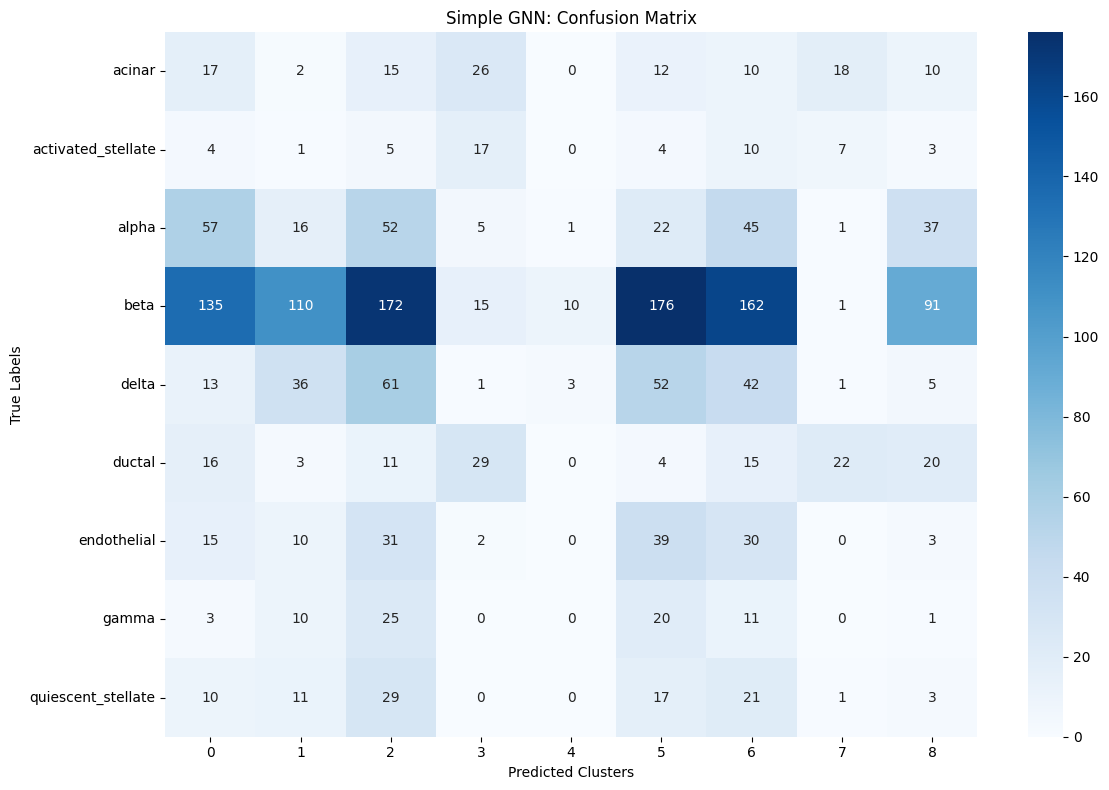

[INFO] Running marker gene analysis...


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: 

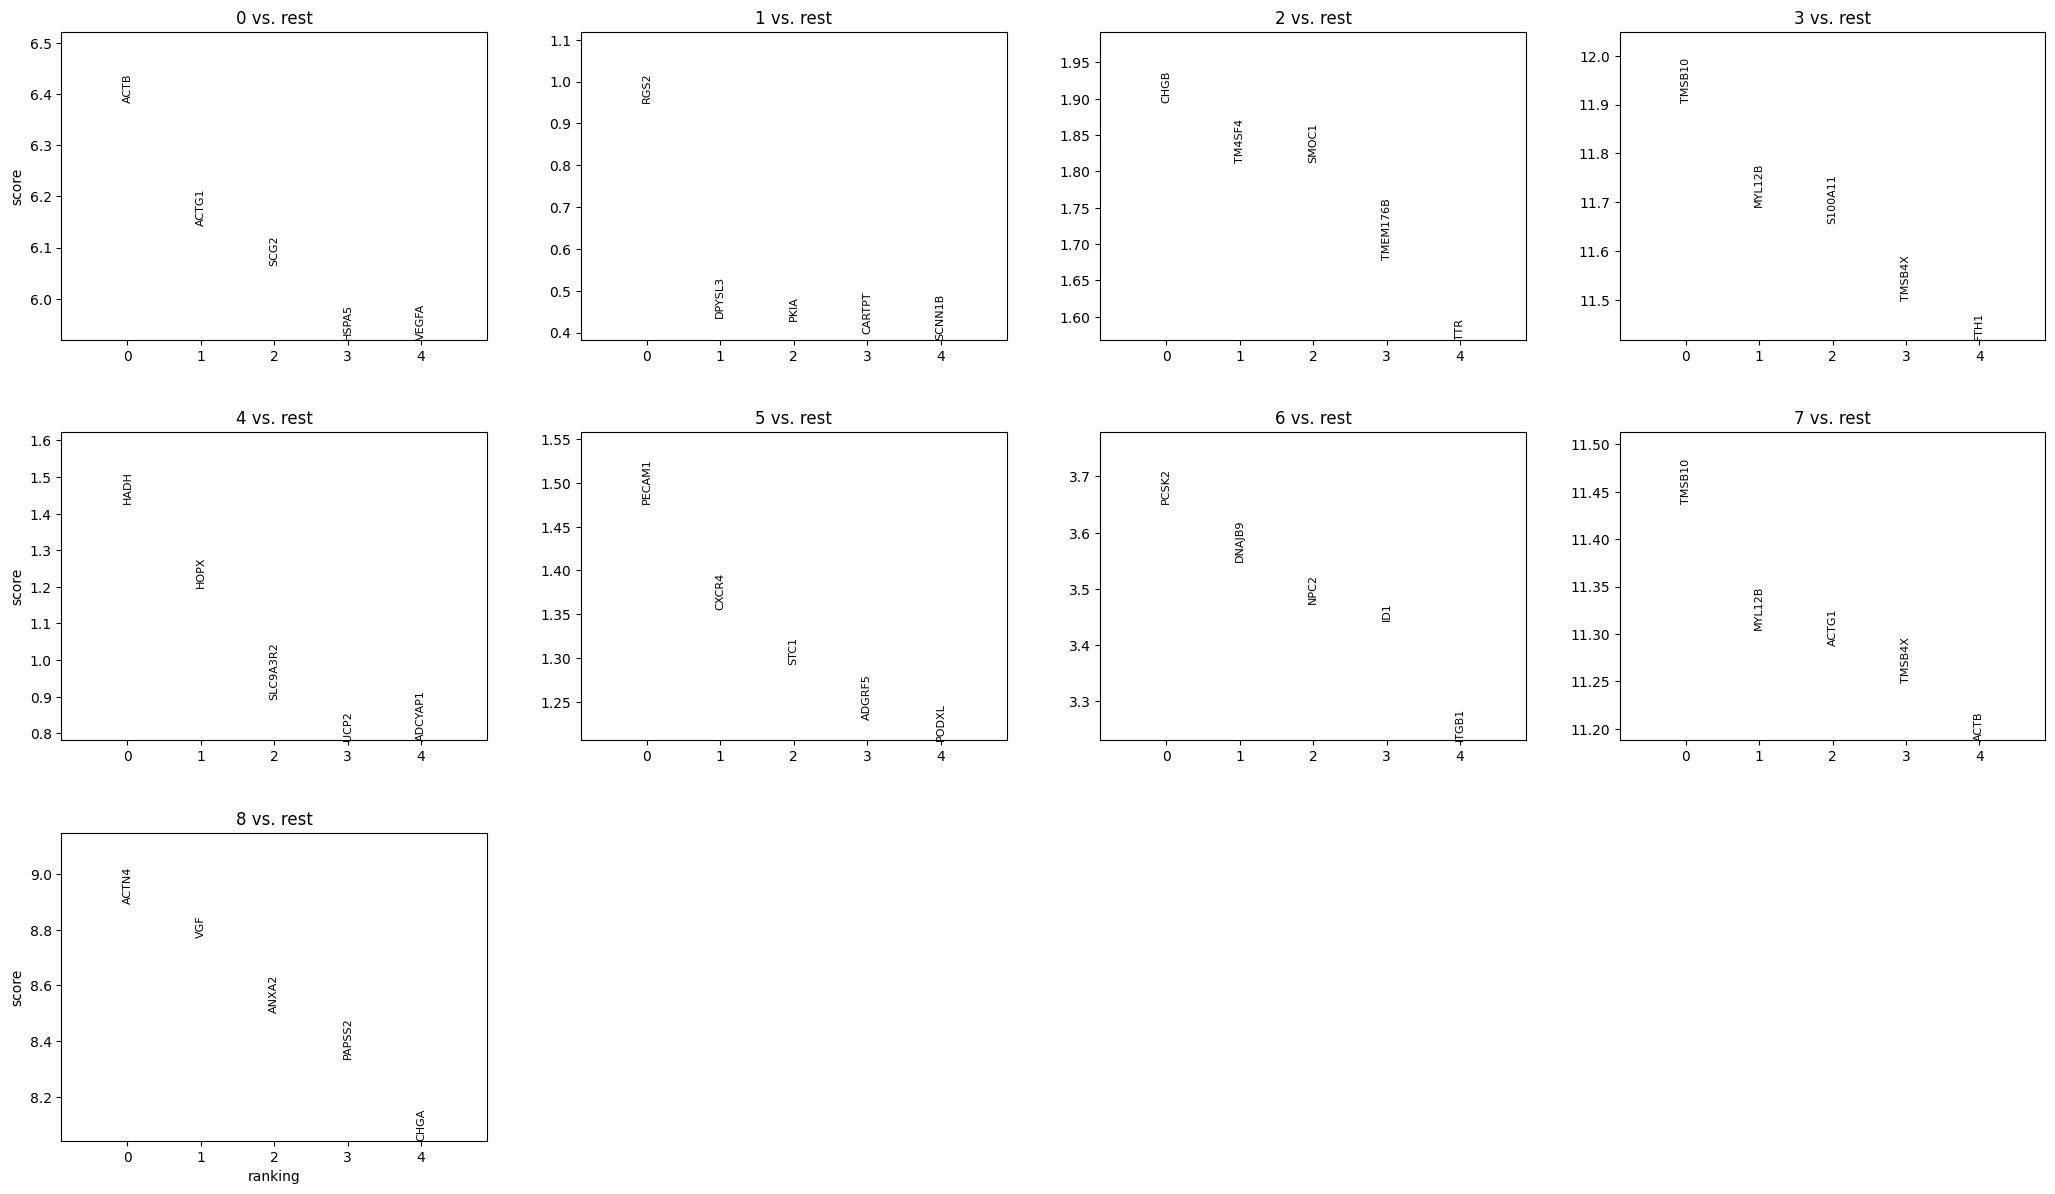


Cluster 0 top marker genes:
  ACTB: logFC=nan, adj.p=3.48e-07 ***
  ACTG1: logFC=nan, adj.p=8.05e-07 ***
  SCG2: logFC=nan, adj.p=8.86e-07 ***
  HSPA5: logFC=nan, adj.p=1.29e-06 ***
  VEGFA: logFC=nan, adj.p=1.29e-06 ***

Cluster 1 top marker genes:
  RGS2: logFC=nan, adj.p=0.872 
  DPYSL3: logFC=nan, adj.p=0.996 
  PKIA: logFC=nan, adj.p=0.996 
  CARTPT: logFC=nan, adj.p=0.996 
  SCNN1B: logFC=nan, adj.p=0.996 

Cluster 2 top marker genes:
  CHGB: logFC=nan, adj.p=0.754 
  TM4SF4: logFC=nan, adj.p=0.812 
  SMOC1: logFC=nan, adj.p=0.812 
  TMEM176B: logFC=nan, adj.p=0.933 
  TTR: logFC=nan, adj.p=1 

Cluster 3 top marker genes:
  TMSB10: logFC=nan, adj.p=2.28e-29 ***
  MYL12B: logFC=nan, adj.p=1.42e-28 ***
  S100A11: logFC=nan, adj.p=1.42e-28 ***
  TMSB4X: logFC=nan, adj.p=6.76e-28 ***
  FTH1: logFC=nan, adj.p=1.37e-27 ***

Cluster 4 top marker genes:
  HADH: logFC=nan, adj.p=0.996 
  HOPX: logFC=nan, adj.p=0.996 
  SLC9A3R2: logFC=nan, adj.p=0.996 
  UCP2: logFC=nan, adj.p=0.996 
  A

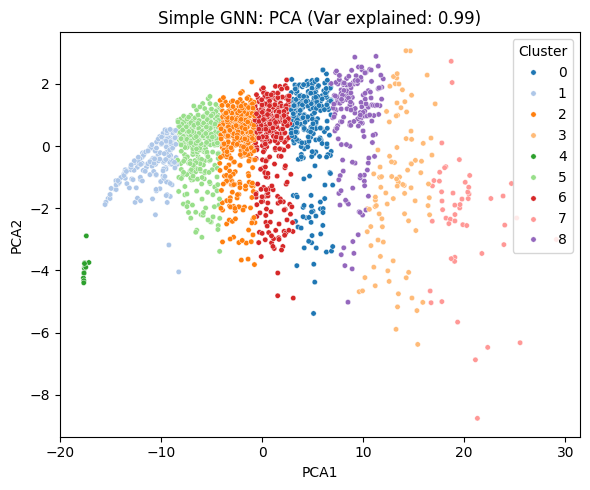

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


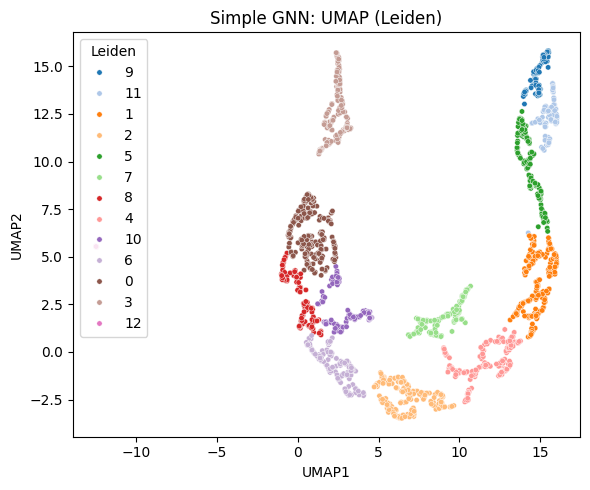

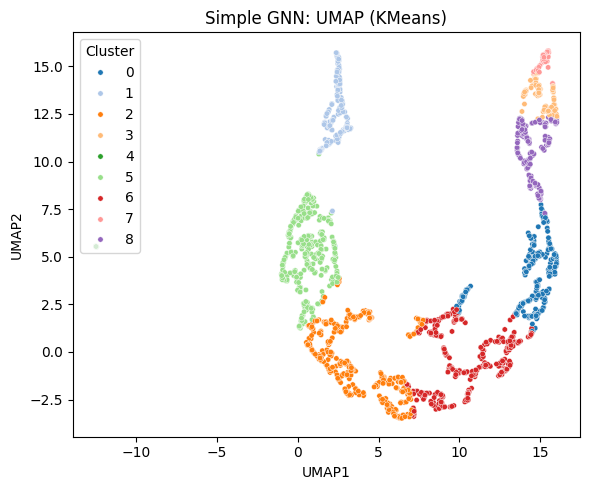

[INFO] Simple bipartite GNN baseline completed!


In [ ]:
# @title
# ---- DEVICE SETUP ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Using device:", device)

# ---- 1. Same preprocessing as main method ----
def preprocess_sctransform(adata, regress_vars=None, hvg_n=2000):
    print("[INFO] Preprocessing with SCTransform-like workflow (highly variable genes + regression)...")
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=hvg_n)
    adata = adata[:, adata.var['highly_variable']]
    if regress_vars is not None:
        sc.pp.regress_out(adata, regress_vars)
    sc.pp.scale(adata)
    print("[INFO] Preprocessing completed.")
    return adata

# ---- 2. Simple Bipartite Graph Construction (NO pathway grouping) ----
def construct_simple_bipartite_graph(
    adata,
    k=5,
    min_expression=0.25,
    gene_percentile=75,
    min_edges_per_gene=2,
    fallback_topk=True
):
    """
    Build a SINGLE bipartite graph (genes ↔ cells) using ALL genes together
    WITHOUT pathway-specific grouping. This is the fair baseline.

    Uses the same edge construction logic as pathway-aware method:
    - Selective edges based on expression thresholds
    - Same fallback mechanism
    BUT treats all genes as one big "pathway" to isolate the effect of pathway information
    """
    print("[INFO] Building simple bipartite graph (all genes, no pathway grouping)...")
    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

    genes = list(adata.var_names)
    cells = list(adata.obs_names)

    G = nx.Graph()
    G.add_nodes_from(genes, bipartite=0, node_type='gene')
    G.add_nodes_from(cells, bipartite=1, node_type='cell')

    # ---- selective edges by threshold (same logic as pathway method) ----
    edges_added = 0
    for gene in genes:
        gene_expr = expr[gene]

        # robust per-gene threshold on non-zero values
        if (gene_expr > 0).sum() > 0:
            per_gene_thr = np.percentile(gene_expr[gene_expr > 0], gene_percentile)
        else:
            per_gene_thr = float('inf')

        thr = max(per_gene_thr, min_expression)

        # add edges for cells where expression is "meaningfully high"
        high_cells = gene_expr.index[gene_expr > thr]
        for cell in high_cells:
            val = gene_expr.loc[cell]
            val_scalar = val.iloc[0] if hasattr(val, 'iloc') else val
            if val_scalar > 0:
                G.add_edge(gene, cell, weight=float(val_scalar))
                edges_added += 1

    # ---- density check + fallback ----
    needed_edges = len(genes) * min_edges_per_gene
    if edges_added < needed_edges and fallback_topk:
        print(f"[INFO] Graph sparse ({edges_added} edges), applying top-k fallback...")
        expr_array = expr.to_numpy()

        # normalize per cell
        row_max = expr_array.max(axis=1, keepdims=True)
        row_max[row_max == 0] = 1.0
        norm_expr = expr_array / row_max

        for i, cell in enumerate(cells):
            cell_vec = norm_expr[i]
            k_eff = min(k, (cell_vec > 0).sum()) if (cell_vec > 0).any() else 0
            if k_eff > 0:
                top_idx = np.argpartition(cell_vec, -k_eff)[-k_eff:]
                for gi in top_idx:
                    gene = genes[gi]
                    if not G.has_edge(gene, cell):
                        raw_val = expr_array[i, gi]
                        if raw_val > 0:
                            G.add_edge(gene, cell, weight=float(raw_val))
                            edges_added += 1

    print(f"[INFO] Bipartite graph constructed: {len(genes)} genes, {len(cells)} cells, {edges_added} edges")
    return G, genes, cells

# ---- 3. Node Features for Bipartite Graph (same as pathway method) ----
def node_features_bipartite_simple(G, expr, n_pca=5):
    """
    Create node features for bipartite graph - same logic as pathway method
    but without pathway-specific information
    """
    genes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'gene']
    cells = [n for n, d in G.nodes(data=True) if d['node_type'] == 'cell']

    # PCA for cells
    if len(genes) > 1 and len(cells) > 1:
        pca = PCA(n_components=min(n_pca, len(genes)))
        cell_pca = pca.fit_transform(expr.loc[cells, genes])
        pca_dim = cell_pca.shape[1]
    else:
        cell_pca = np.zeros((len(cells), n_pca))
        pca_dim = n_pca

    features = []
    # ---- Genes ----
    for gene in genes:
        vals = expr[gene] if gene in expr.columns else np.zeros(len(cells))
        # Base features: [mean, std, degree, type_gene, type_cell]
        vec = [np.mean(vals), np.std(vals), G.degree(gene), 1, 0]
        # Pad PCA slots (genes don't get PCA features)
        vec += [0.0] * pca_dim
        features.append(vec)

    # ---- Cells ----
    for i, cell in enumerate(cells):
        vals = expr.loc[cell, genes] if cell in expr.index else np.zeros(len(genes))
        vec = [np.mean(vals), np.std(vals), G.degree(cell), 0, 1]
        # Add PCA profile
        vec += list(cell_pca[i])
        features.append(vec)

    x = np.array(features, dtype=np.float32)
    return x, genes, cells

# ---- 4. Simple GNN Model ----
class SimpleGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, gnn_type='gcn', heads=2):
        super().__init__()
        self.gnn_type = gnn_type.lower()
        if self.gnn_type == 'gcn':
            self.conv1 = GCNConv(in_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, out_dim)
        elif self.gnn_type == 'sage':
            self.conv1 = SAGEConv(in_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, out_dim)
        elif self.gnn_type == 'gat':
            self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, concat=False)
            self.conv2 = GATConv(hidden_dim, out_dim, heads=heads, concat=False)
        else:
            raise ValueError("gnn_type must be one of: 'gcn', 'sage', 'gat'")

        self.dropout = nn.Dropout(0.2)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

# ---- 5. Contrastive Loss (same as main method) ----
def contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5):
    mask = (torch.rand_like(cell_emb) > drop_prob).float()
    cell_emb_aug = cell_emb * mask
    N = cell_emb.shape[0]
    z1 = F.normalize(cell_emb, dim=1)
    z2 = F.normalize(cell_emb_aug, dim=1)
    representations = torch.cat([z1, z2], dim=0)
    similarity_matrix = torch.matmul(representations, representations.T)
    mask_eye = torch.eye(2*N, dtype=torch.bool, device=cell_emb.device)
    similarity_matrix = similarity_matrix.masked_fill(mask_eye, -9e15)
    positives = torch.cat([torch.diag(similarity_matrix, N), torch.diag(similarity_matrix, -N)], dim=0)
    negatives = similarity_matrix[~mask_eye].view(2*N, -1)
    logits = torch.cat([positives.unsqueeze(1), negatives], dim=1) / temperature
    labels = torch.zeros(2*N, dtype=torch.long, device=cell_emb.device)
    loss = F.cross_entropy(logits, labels)
    return loss.item(), loss

# ---- 6. Training (modified for bipartite graph) ----
def train_simple_bipartite_gnn(G, expr, model_type='sage', hidden_dim=32, out_dim=16,
                               epochs=100, early_stop_patience=15, early_stop_delta=1e-4, device="cuda"):
    print(f"[INFO] Training simple bipartite GNN ({model_type}) with contrastive loss...")

    # Get node features
    x, genes, cells = node_features_bipartite_simple(G, expr, n_pca=5)

    all_nodes = genes + cells
    node_to_idx = {n: i for i, n in enumerate(all_nodes)}

    # Convert graph to PyTorch format
    edges = [(node_to_idx[a], node_to_idx[b]) for a, b in G.edges() if a in node_to_idx and b in node_to_idx]
    if not edges:
        print("[ERROR] No edges in graph!")
        return None, cells

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    # Model setup
    model = SimpleGNN(x.shape[1], hidden_dim, out_dim, gnn_type=model_type).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    best_loss = float("inf")
    patience = 0

    for epoch in range(epochs):
        optimizer.zero_grad()
        emb = model(x_tensor, edge_index)

        # Extract cell embeddings (same as pathway method)
        cell_emb = emb[len(genes):]

        loss_val, loss = contrastive_loss_dropout(cell_emb, drop_prob=0.2, temperature=0.5)
        loss.backward()
        optimizer.step()

        if loss_val + early_stop_delta < best_loss:
            best_loss = loss_val
            patience = 0
        else:
            patience += 1

        if patience > early_stop_patience:
            print(f"[INFO] Early stopped at epoch {epoch+1} (best loss: {best_loss:.4f})")
            break

        if (epoch+1) % 50 == 0 or epoch == 0:
            print(f"[INFO] Epoch {epoch+1}, contrastive loss: {loss_val:.4f}")

    # Get final cell embeddings
    model.eval()
    with torch.no_grad():
        final_emb = model(x_tensor, edge_index)
        cell_emb = final_emb[len(genes):].cpu().numpy()

    print(f"[INFO] Training completed. Cell embeddings shape: {cell_emb.shape}")
    return cell_emb, cells

# ---- 7. Clustering and Evaluation (same as main method) ----
def cluster_and_eval_simple(final_emb, cells, adata, n_clusters=None, leiden_res_list=None):
    print("[INFO] Running clustering (Leiden + KMeans)...")

    if leiden_res_list is None:
        leiden_res_list = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

    adata.obsm['X_simple_gnn'] = final_emb
    sc.pp.neighbors(adata, use_rep='X_simple_gnn', n_neighbors=15)

    leiden_silhouettes = []
    leiden_label_sets = {}

    for res in leiden_res_list:
        sc.tl.leiden(adata, resolution=res, key_added=f'simple_leiden_{res}')
        leiden_labels = adata.obs[f'simple_leiden_{res}'].astype(str).reindex(cells).fillna('NA').tolist()
        leiden_labels_num = pd.factorize(leiden_labels)[0]

        if len(set(leiden_labels_num)) > 1:
            sil = silhouette_score(final_emb, leiden_labels_num)
        else:
            sil = -1
        leiden_silhouettes.append(sil)
        leiden_label_sets[res] = leiden_labels
        print(f"[INFO] Leiden res={res:.2f}, clusters={len(set(leiden_labels))}, silhouette={sil:.3f}")

    best_res = leiden_res_list[np.argmax(leiden_silhouettes)]
    best_leiden_labels = leiden_label_sets[best_res]
    best_leiden_silhouette = max(leiden_silhouettes)

    # KMeans
    if n_clusters is None:
        sil_scores = []
        for k in range(3, 15):
            labels = KMeans(n_clusters=k).fit_predict(final_emb)
            sil_scores.append(silhouette_score(final_emb, labels))
        n_clusters = np.argmax(sil_scores) + 3
    elif n_clusters == "unique":
        n_clusters = adata.obs['assigned_cluster'].nunique()

    kmeans_labels = KMeans(n_clusters=n_clusters).fit_predict(final_emb)
    kmeans_silhouette = silhouette_score(final_emb, kmeans_labels)

    # Evaluation
    if 'assigned_cluster' in adata.obs:
        true_labels = adata.obs.loc[cells, 'assigned_cluster']
        metrics = {
            'Leiden ARI': adjusted_rand_score(true_labels, best_leiden_labels),
            'Leiden NMI': normalized_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden AMI': adjusted_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden Silhouette': best_leiden_silhouette,
            'KMeans ARI': adjusted_rand_score(true_labels, kmeans_labels),
            'KMeans NMI': normalized_mutual_info_score(true_labels, kmeans_labels),
            'KMeans AMI': adjusted_mutual_info_score(true_labels, kmeans_labels),
            'KMeans Silhouette': kmeans_silhouette
        }
        print("[INFO] Simple GNN Clustering metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.3f}")

        # Confusion matrix
        true_labels = adata.obs.loc[cells, 'assigned_cluster'].astype(str).values
        pred_labels = kmeans_labels.astype(str)
        cm_df = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters")
        plt.ylabel("True Labels")
        plt.title("Simple GNN: Confusion Matrix")
        plt.tight_layout()
        plt.show()

    return best_leiden_labels, kmeans_labels, best_res, best_leiden_silhouette, kmeans_silhouette

# ---- 8. Visualization ----
def visualize_simple(final_emb, cluster_labels, cells, leiden_labels=None):
    print("[INFO] Generating visualizations (PCA, UMAP)...")

    # PCA
    pca = PCA(n_components=2)
    pca_proj = pca.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=pca_proj[:,0], y=pca_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title(f'Simple GNN: PCA (Var explained: {pca.explained_variance_ratio_.sum():.2f})')
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_proj = reducer.fit_transform(final_emb)

    if leiden_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=leiden_labels, palette='tab20', s=15)
        plt.title("Simple GNN: UMAP (Leiden)")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.legend(title="Leiden")
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title("Simple GNN: UMAP (KMeans)")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

# ---- 9. Main Pipeline (updated for bipartite graph) ----
def run_simple_baseline_pipeline(
    expr_csv, metadata_cols=['barcode', 'assigned_cluster'],
    regress_vars=None, hvg_n=2000,
    k=5, min_expression=0.25, gene_percentile=75,  # same params as pathway method
    model_type='sage', hidden_dim=32, out_dim=16, epochs=100,
    early_stop_patience=15, early_stop_delta=1e-4,
    top_n_marker_genes=5, n_clusters=None, rare_cell_thresh=40,
    device="cuda"
):
    print("[INFO] === SIMPLE BIPARTITE GNN BASELINE (No Pathway Information) ===")
    print("[INFO] Loading expression matrix...")

    df = pd.read_csv(expr_csv, index_col=0)
    metadata = df[metadata_cols]
    expr_df = df.drop(columns=metadata_cols)
    expr_df = expr_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    adata = sc.AnnData(expr_df)
    adata.obs = metadata

    # Fix duplicate names
    if adata.obs_names.duplicated().any():
        print("[WARNING] Found duplicate cell names. Making unique...")
        adata.obs_names_make_unique()
    if adata.var_names.duplicated().any():
        print("[WARNING] Found duplicate gene names. Making unique...")
        adata.var_names_make_unique()

    # Remove rare cell clusters
    if 'assigned_cluster' in adata.obs:
        counts = adata.obs['assigned_cluster'].value_counts()
        keep = counts[counts >= rare_cell_thresh].index
        before = adata.n_obs
        adata = adata[adata.obs['assigned_cluster'].isin(keep)]
        print(f"[INFO] Removed rare cell types (<{rare_cell_thresh} cells). {before} → {adata.n_obs} cells kept.")

    # Preprocess (same as pathway method)
    adata = preprocess_sctransform(adata, regress_vars=regress_vars, hvg_n=hvg_n)

    # Build simple bipartite graph (all genes together, no pathway grouping)
    G, genes, cells = construct_simple_bipartite_graph(
        adata, k=k, min_expression=min_expression,
        gene_percentile=gene_percentile, fallback_topk=True
    )

    expr = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

    # Train GNN
    final_emb, cells_ordered = train_simple_bipartite_gnn(
        G, expr, model_type=model_type, hidden_dim=hidden_dim, out_dim=out_dim,
        epochs=epochs, early_stop_patience=early_stop_patience, early_stop_delta=early_stop_delta,
        device=device
    )

    if final_emb is None:
        print("[ERROR] Training failed!")
        return

    # Clustering and evaluation
    leiden_labels, kmeans_labels, best_res, leiden_sil, kmeans_sil = cluster_and_eval_simple(
        final_emb, cells_ordered, adata, n_clusters=n_clusters
    )

    # Marker gene analysis
    print("[INFO] Running marker gene analysis...")
    adata.obs["cluster"] = kmeans_labels.astype(str)
    sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon", use_raw=False)
    sc.pl.rank_genes_groups(adata, n_genes=top_n_marker_genes, sharey=False)

    markers_df = sc.get.rank_genes_groups_df(adata, group=None)
    for c in sorted(adata.obs["cluster"].unique()):
        top_genes = markers_df[markers_df["group"] == c].head(top_n_marker_genes)
        print(f"\nCluster {c} top marker genes:")
        for _, row in top_genes.iterrows():
            sig = (
                "***" if row["pvals_adj"] < 0.001 else
                "**" if row["pvals_adj"] < 0.01 else
                "*" if row["pvals_adj"] < 0.05 else ""
            )
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, adj.p={row['pvals_adj']:.3g} {sig}")

    # Visualizations
    visualize_simple(final_emb, kmeans_labels, cells_ordered, leiden_labels)

    print("[INFO] Simple bipartite GNN baseline completed!")


# Example usage:
run_simple_baseline_pipeline(
    '/content/drive/MyDrive/Pathway GNN Project/pancreas5.csv',
    model_type='gcn', epochs=150, n_clusters="unique"
)

**Simple Baseline MLP**

## Deep Embedded Clustering (DEC) Baseline

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import scanpy as sc
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score
from sklearn.decomposition import PCA
import os

# Reusing the preprocess_sctransform from previous cells
# Assuming preprocess_sctransform is available in the environment from previous executions
# If not, you might need to copy its definition here.

# Autoencoder (reused from MLP baseline)
class MLPAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], latent_dim=32, dropout=0.2):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        # Latent layer (no activation here, directly maps to latent_dim)
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        # Output layer
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

    def encode(self, x):
        return self.encoder(x)


class DeepEmbeddedClustering(nn.Module):
    def __init__(self, input_dim, num_clusters, hidden_dims=[512, 256, 128], latent_dim=32, dropout=0.2, alpha=1.0):
        super().__init__()
        self.num_clusters = num_clusters
        self.alpha = alpha

        self.autoencoder = MLPAutoencoder(input_dim, hidden_dims, latent_dim, dropout)

        # Initialize cluster centroids using KMeans later
        self.centroids = nn.Parameter(torch.Tensor(num_clusters, latent_dim))
        self.centroids_initialized = False

    def forward(self, x):
        latent, reconstructed = self.autoencoder(x)
        # Soft assignment (Eq. 1 in DEC paper)
        q = self.soft_assign(latent)
        return q, latent, reconstructed

    def soft_assign(self, latent):
        # q_ij = (1 + ||z_i - mu_j||^2 / alpha)^(-(alpha+1)/2)
        # q_ij = q_ij / sum_j(q_ij)
        diff = latent.unsqueeze(1) - self.centroids.unsqueeze(0)
        dist = torch.sum(diff ** 2, dim=2)
        q = 1.0 / (1.0 + (dist / self.alpha))
        q = q ** ((self.alpha + 1.0) / 2.0)
        q = q / torch.sum(q, dim=1, keepdim=True)
        return q

    def target_distribution(self, q):
        # p_ij = q_ij^2 / sum_i(q_ij)
        # p_ij = p_ij / sum_j(p_ij)
        weight = q**2 / torch.sum(q, dim=0)
        return (weight.T / torch.sum(weight, dim=1)).T

    def initialize_centroids(self, data_loader, device):
        self.eval()
        latent_features = []
        with torch.no_grad():
            for batch_x, in data_loader:
                batch_x = batch_x.to(device)
                latent, _ = self.autoencoder(batch_x)
                latent_features.append(latent.cpu().numpy())
        latent_features = np.concatenate(latent_features, axis=0)

        # Initialize KMeans on latent features
        kmeans = KMeans(n_clusters=self.num_clusters, n_init=20, random_state=42)
        kmeans.fit(latent_features)
        self.centroids.data.copy_(torch.tensor(kmeans.cluster_centers_, dtype=torch.float32))
        self.centroids_initialized = True
        print(f"[INFO] Centroids initialized with KMeans for {self.num_clusters} clusters.")


def train_dec(model, data, num_clusters, epochs=100, batch_size=256, learning_rate=0.001,
              pretrain_epochs=50, early_stop_patience=15, early_stop_delta=1e-4, device="cuda"):
    print(f"[INFO] Training Deep Embedded Clustering (DEC) on {device}...")

    n_cells, n_genes = data.shape
    data_tensor = torch.tensor(data, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(data_tensor)
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Pre-train autoencoder
    print("[INFO] Pre-training autoencoder...")
    ae_optimizer = torch.optim.Adam(model.autoencoder.parameters(), lr=learning_rate)
    best_ae_loss = float('inf')
    ae_patience = 0
    for epoch in range(pretrain_epochs):
        model.train()
        epoch_loss = 0
        for batch_x, in data_loader:
            batch_x = batch_x.to(device)
            ae_optimizer.zero_grad()
            latent, reconstructed = model.autoencoder(batch_x)
            loss = F.mse_loss(reconstructed, batch_x)
            loss.backward()
            ae_optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(data_loader)
        if avg_loss + early_stop_delta < best_ae_loss:
            best_ae_loss = avg_loss
            ae_patience = 0
        else:
            ae_patience += 1
        if ae_patience > early_stop_patience:
            print(f"[INFO] Autoencoder pre-training early stopped at epoch {epoch+1} (best loss: {best_ae_loss:.4f})")
            break
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"[INFO] Pre-train Epoch {epoch+1}, AE Loss: {avg_loss:.4f}")

    # Initialize centroids after pre-training
    if not model.centroids_initialized:
        model.initialize_centroids(data_loader, device)

    print("[INFO] Starting DEC fine-tuning...")
    best_dec_loss = float('inf')
    dec_patience = 0
    for epoch in range(epochs):
        model.train()
        epoch_recon_loss = 0
        epoch_cluster_loss = 0
        for batch_x, in data_loader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()

            # Forward pass
            q, latent, reconstructed = model(batch_x)

            # Compute target distribution p
            p = model.target_distribution(q.detach()) # Detach q to prevent gradients flowing back through it to q

            # Reconstruction loss (autoencoder part)
            recon_loss = F.mse_loss(reconstructed, batch_x)

            # Clustering loss (KL divergence)
            cluster_loss = F.kl_div(q.log(), p, reduction='batchmean')

            # Total loss
            loss = recon_loss + 0.1 * cluster_loss # Weight cluster loss
            loss.backward()
            optimizer.step()

            epoch_recon_loss += recon_loss.item()
            epoch_cluster_loss += cluster_loss.item()

        avg_recon_loss = epoch_recon_loss / len(data_loader)
        avg_cluster_loss = epoch_cluster_loss / len(data_loader)
        total_avg_loss = avg_recon_loss + 0.1 * avg_cluster_loss

        if total_avg_loss + early_stop_delta < best_dec_loss:
            best_dec_loss = total_avg_loss
            dec_patience = 0
        else:
            dec_patience += 1

        if dec_patience > early_stop_patience:
            print(f"[INFO] DEC fine-tuning early stopped at epoch {epoch+1} (best total loss: {best_dec_loss:.4f})")
            break

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"[INFO] DEC Epoch {epoch+1}, Recon Loss: {avg_recon_loss:.4f}, Cluster Loss: {avg_cluster_loss:.4f}, Total Loss: {total_avg_loss:.4f}")

    model.eval()
    with torch.no_grad():
        final_emb = model.autoencoder.encode(data_tensor.to(device)).cpu().numpy()

    print(f"[INFO] DEC training completed. Final embeddings shape: {final_emb.shape}")
    return final_emb, model

In [21]:
# ---- Clustering and Evaluation for DEC ----
def cluster_and_eval_dec(final_emb, cells, adata, num_clusters_dec, leiden_res_list=None):
    print("[INFO] Running clustering (Leiden + KMeans) on DEC embeddings...")

    if leiden_res_list is None:
        leiden_res_list = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

    adata.obsm['X_dec'] = final_emb
    sc.pp.neighbors(adata, use_rep='X_dec', n_neighbors=15)

    leiden_silhouettes = []
    leiden_label_sets = {}

    # Leiden clustering
    for res in leiden_res_list:
        sc.tl.leiden(adata, resolution=res, key_added=f'dec_leiden_{res}')
        leiden_labels = adata.obs[f'dec_leiden_{res}'].astype(str).reindex(cells).fillna('NA').tolist()
        leiden_labels_num = pd.factorize(leiden_labels)[0]

        if len(set(leiden_labels_num)) > 1:
            sil = silhouette_score(final_emb, leiden_labels_num)
        else:
            sil = -1
        leiden_silhouettes.append(sil)
        leiden_label_sets[res] = leiden_labels
        print(f"[INFO] Leiden res={res:.2f}, clusters={len(set(leiden_labels))}, silhouette={sil:.3f}")

    best_res = leiden_res_list[np.argmax(leiden_silhouettes)]
    best_leiden_labels = leiden_label_sets[best_res]
    best_leiden_silhouette = max(leiden_silhouettes)

    # KMeans clustering (using num_clusters_dec)
    kmeans_labels = KMeans(n_clusters=num_clusters_dec, random_state=42, n_init=10).fit_predict(final_emb)
    kmeans_silhouette = silhouette_score(final_emb, kmeans_labels)
    print(f"[INFO] KMeans n={num_clusters_dec}, silhouette={kmeans_silhouette:.3f}")

    # Evaluation metrics
    if 'assigned_cluster' in adata.obs:
        true_labels = adata.obs.loc[cells, 'assigned_cluster']
        metrics = {
            'Leiden ARI': adjusted_rand_score(true_labels, best_leiden_labels),
            'Leiden NMI': normalized_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden AMI': adjusted_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden Silhouette': best_leiden_silhouette,
            'KMeans ARI': adjusted_rand_score(true_labels, kmeans_labels),
            'KMeans NMI': normalized_mutual_info_score(true_labels, kmeans_labels),
            'KMeans AMI': adjusted_mutual_info_score(true_labels, kmeans_labels),
            'KMeans Silhouette': kmeans_silhouette
        }
        print("[INFO] DEC Clustering metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.3f}")

        # Confusion matrix
        true_labels = adata.obs.loc[cells, 'assigned_cluster'].astype(str).values
        pred_labels = kmeans_labels.astype(str)
        cm_df = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters")
        plt.ylabel("True Labels")
        plt.title("DEC: Confusion Matrix")
        plt.tight_layout()
        plt.show()

    return best_leiden_labels, kmeans_labels, best_res, best_leiden_silhouette, kmeans_silhouette

# ---- Visualization for DEC ----
def visualize_dec(final_emb, cluster_labels, cells, leiden_labels=None):
    print("[INFO] Generating visualizations (PCA, UMAP) for DEC...")

    # PCA
    pca = PCA(n_components=2)
    pca_proj = pca.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=pca_proj[:,0], y=pca_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title(f'DEC: PCA (Var explained: {pca.explained_variance_ratio_.sum():.2f})')
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_proj = reducer.fit_transform(final_emb)

    if leiden_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=leiden_labels, palette='tab20', s=15)
        plt.title("DEC: UMAP (Leiden)")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.legend(title="Leiden")
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title("DEC: UMAP (KMeans on Latent Space)")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

[INFO] === DEEP EMBEDDED CLUSTERING (DEC) BASELINE ===
[INFO] Loading expression matrix...
[INFO] Removed rare cell types (<40 cells). 822 → 736 cells kept.
[INFO] Preprocessing with SCTransform-like workflow...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:246: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Preprocessing completed.
[INFO] Using unique assigned clusters for DEC: num_clusters=4
[INFO] Training Deep Embedded Clustering (DEC) on cuda...
[INFO] Pre-training autoencoder...
[INFO] Pre-train Epoch 1, AE Loss: 1.2954
[INFO] Pre-train Epoch 10, AE Loss: 0.9334
[INFO] Pre-train Epoch 20, AE Loss: 0.8863
[INFO] Pre-train Epoch 30, AE Loss: 0.8525
[INFO] Pre-train Epoch 40, AE Loss: 0.8267
[INFO] Pre-train Epoch 50, AE Loss: 0.7944
[INFO] Centroids initialized with KMeans for 4 clusters.
[INFO] Starting DEC fine-tuning...
[INFO] DEC Epoch 1, Recon Loss: 0.8155, Cluster Loss: 0.0876, Total Loss: 0.8243
[INFO] DEC Epoch 10, Recon Loss: 0.7845, Cluster Loss: 0.1021, Total Loss: 0.7947
[INFO] DEC Epoch 20, Recon Loss: 0.7553, Cluster Loss: 0.1077, Total Loss: 0.7661
[INFO] DEC Epoch 30, Recon Loss: 0.7358, Cluster Loss: 0.1086, Total Loss: 0.7467
[INFO] DEC Epoch 40, Recon Loss: 0.7214, Cluster Loss: 0.1095, Total Loss: 0.7324
[INFO] DEC Epoch 50, Recon Loss: 0.7081, Cluster Loss: 

/tmp/ipykernel_9420/1595421820.py:16: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'dec_leiden_{res}')
/tmp/ipykernel_9420/1595421820.py:18: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_9420/1595421820.py:16: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for 

[INFO] Leiden res=0.40, clusters=8, silhouette=0.178
[INFO] Leiden res=0.60, clusters=8, silhouette=0.179


...

[INFO] Leiden res=1.00, clusters=8, silhouette=0.137
[INFO] Leiden res=1.20, clusters=10, silhouette=0.096


/tmp/ipykernel_9420/1595421820.py:18: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_9420/1595421820.py:16: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'dec_leiden_{res}')
/tmp/ipykernel_9420/1595421820.py:18: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]


[INFO] Leiden res=1.50, clusters=12, silhouette=-0.003
[INFO] Leiden res=2.00, clusters=13, silhouette=0.009
[INFO] KMeans n=4, silhouette=0.653


/tmp/ipykernel_9420/1595421820.py:16: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'dec_leiden_{res}')
/tmp/ipykernel_9420/1595421820.py:18: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]


[INFO] DEC Clustering metrics:
  Leiden ARI: 0.613
  Leiden NMI: 0.724
  Leiden AMI: 0.722
  Leiden Silhouette: 0.229
  KMeans ARI: 0.451
  KMeans NMI: 0.548
  KMeans AMI: 0.545
  KMeans Silhouette: 0.653


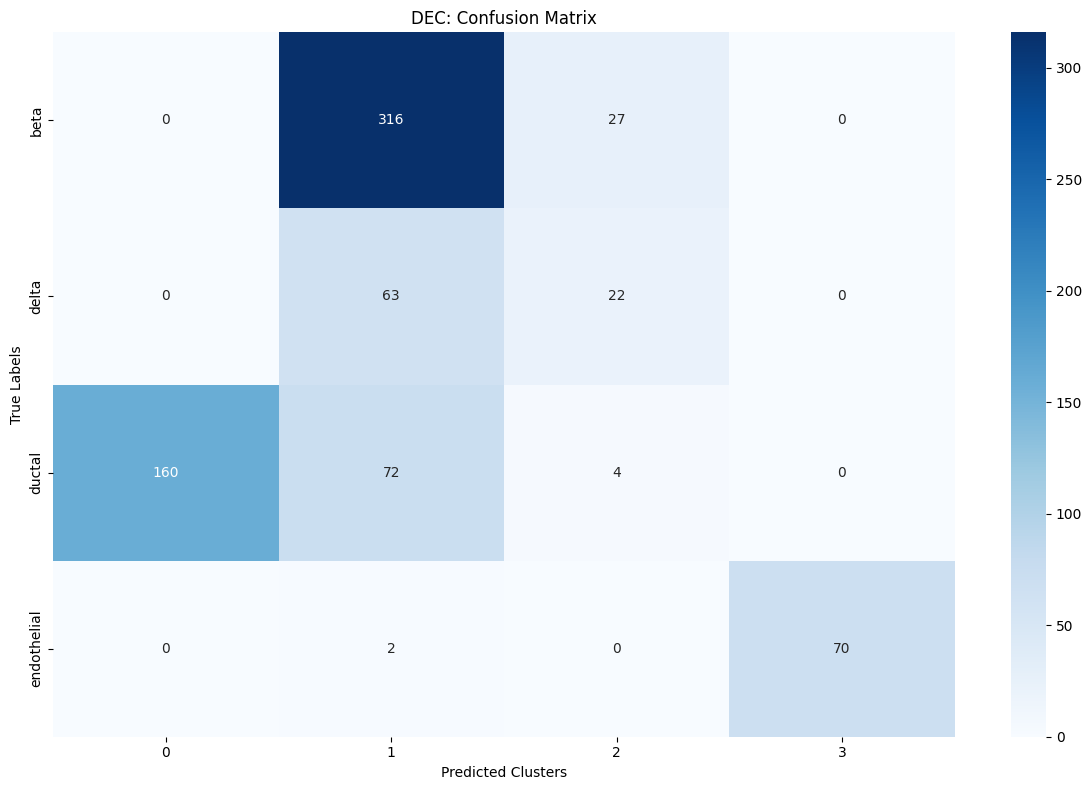

[INFO] Running marker gene analysis...


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


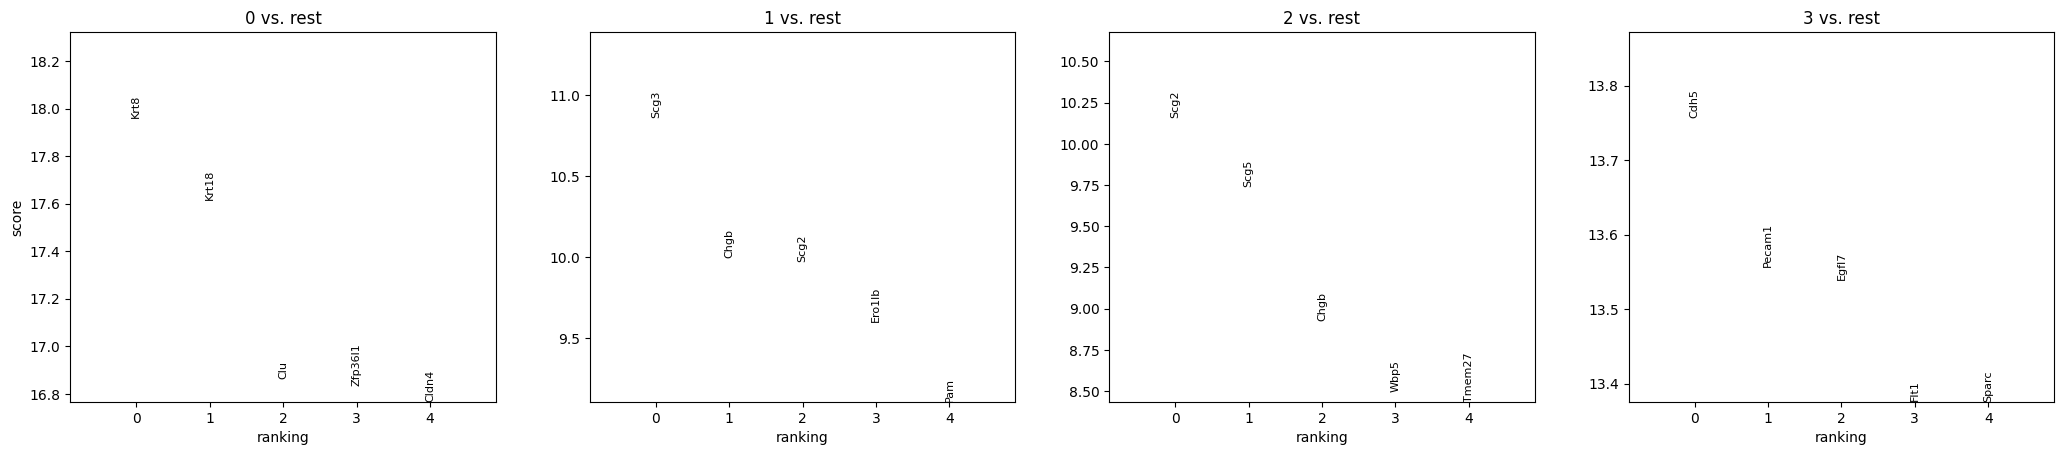


DEC Cluster 0 top marker genes:
  Krt8: logFC=nan, adj.p=7.65e-69 ***
  Krt18: logFC=nan, adj.p=1.8e-66 ***
  Clu: logFC=nan, adj.p=5.41e-61 ***
  Zfp36l1: logFC=nan, adj.p=6.65e-61 ***
  Cldn4: logFC=nan, adj.p=1.7e-60 ***

DEC Cluster 1 top marker genes:
  Scg3: logFC=nan, adj.p=7.56e-26 ***
  Chgb: logFC=nan, adj.p=4.97e-22 ***
  Scg2: logFC=nan, adj.p=6.08e-22 ***
  Ero1lb: logFC=nan, adj.p=2.03e-20 ***
  Pam: logFC=nan, adj.p=1.87e-18 ***

DEC Cluster 2 top marker genes:
  Scg2: logFC=nan, adj.p=5.94e-21 ***
  Scg5: logFC=nan, adj.p=2.08e-19 ***
  Chgb: logFC=nan, adj.p=2.91e-16 ***
  Wbp5: logFC=nan, adj.p=9.64e-15 ***
  Tmem27: logFC=nan, adj.p=1.32e-14 ***

DEC Cluster 3 top marker genes:
  Cdh5: logFC=nan, adj.p=9.2e-40 ***
  Pecam1: logFC=nan, adj.p=6.09e-39 ***
  Egfl7: logFC=nan, adj.p=6.09e-39 ***
  Flt1: logFC=nan, adj.p=3.35e-38 ***
  Sparc: logFC=nan, adj.p=3.35e-38 ***
[INFO] Generating visualizations (PCA, UMAP) for DEC...


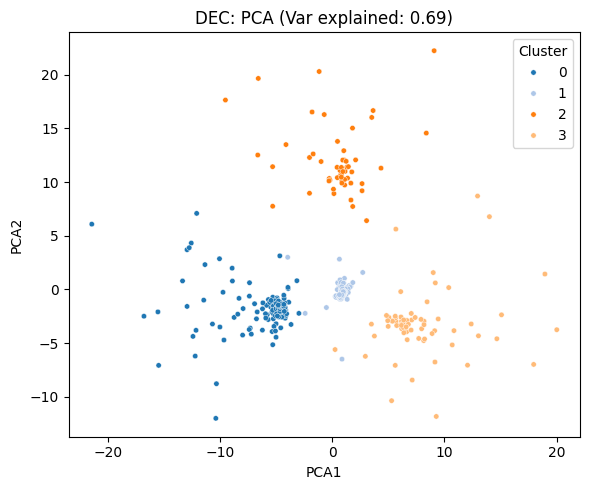

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


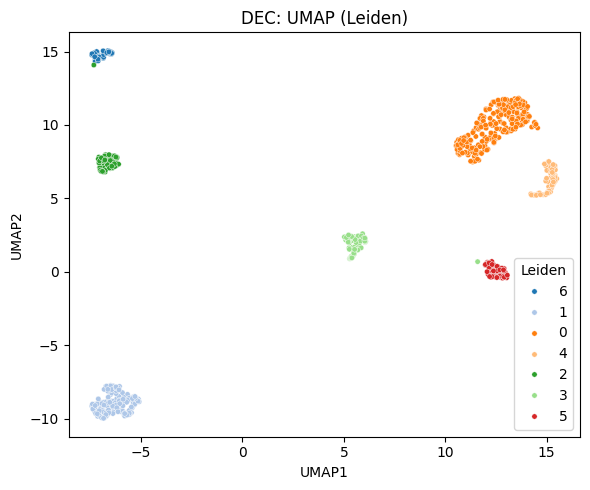

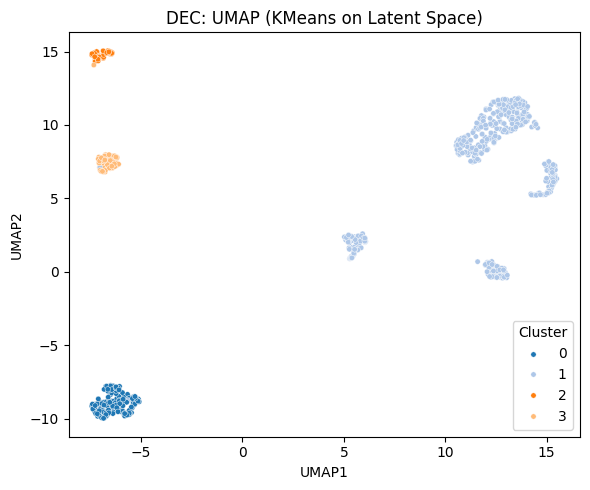

[INFO] Deep Embedded Clustering baseline completed!


In [22]:
# ---- Main Pipeline for DEC ----
def run_dec_baseline_pipeline(
    expr_csv, metadata_cols=['barcode', 'assigned_cluster'],
    regress_vars=None, hvg_n=2000,
    num_clusters=None, # Explicitly for DEC
    hidden_dims=[512, 256, 128], latent_dim=32, dropout=0.2, alpha=1.0,
    pretrain_epochs=50, dec_epochs=100, batch_size=256, learning_rate=0.001,
    early_stop_patience=15, early_stop_delta=1e-4,
    top_n_marker_genes=5, rare_cell_thresh=40,
    device="cuda"
):
    print("[INFO] === DEEP EMBEDDED CLUSTERING (DEC) BASELINE ===")
    print("[INFO] Loading expression matrix...")

    df = pd.read_csv(expr_csv, index_col=0)
    metadata = df[metadata_cols]
    expr_df = df.drop(columns=metadata_cols)
    expr_df = expr_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    adata = sc.AnnData(expr_df)
    adata.obs = metadata

    # Fix duplicate names
    if adata.obs_names.duplicated().any():
        print("[WARNING] Found duplicate cell names. Making unique...")
        adata.obs_names_make_unique()
    if adata.var_names.duplicated().any():
        print("[WARNING] Found duplicate gene names. Making unique...")
        adata.var_names_make_unique()

    # Remove rare cell clusters
    if 'assigned_cluster' in adata.obs:
        counts = adata.obs['assigned_cluster'].value_counts()
        keep = counts[counts >= rare_cell_thresh].index
        before = adata.n_obs
        adata = adata[adata.obs['assigned_cluster'].isin(keep)]
        print(f"[INFO] Removed rare cell types (<{rare_cell_thresh} cells). {before} → {adata.n_obs} cells kept.")

    # Preprocess
    adata = preprocess_sctransform(adata, regress_vars=regress_vars, hvg_n=hvg_n)

    cells = list(adata.obs_names)
    data = adata.X

    # Determine num_clusters if not provided
    if num_clusters is None or num_clusters == "unique":
        if 'assigned_cluster' in adata.obs:
            num_clusters_dec = adata.obs['assigned_cluster'].nunique()
            print(f"[INFO] Using unique assigned clusters for DEC: num_clusters={num_clusters_dec}")
        else:
            print("[WARNING] 'assigned_cluster' not found in adata.obs and num_clusters is None. Defaulting to 7 clusters for DEC.")
            num_clusters_dec = 7 # Default if no reference clusters and None specified
    else:
        num_clusters_dec = num_clusters

    # Initialize DEC model
    dec_model = DeepEmbeddedClustering(input_dim=data.shape[1],
                                     num_clusters=num_clusters_dec,
                                     hidden_dims=hidden_dims,
                                     latent_dim=latent_dim,
                                     dropout=dropout,
                                     alpha=alpha).to(device)

    # Train DEC model
    final_emb, trained_dec_model = train_dec(
        dec_model, data, num_clusters=num_clusters_dec,
        epochs=dec_epochs, pretrain_epochs=pretrain_epochs, batch_size=batch_size,
        learning_rate=learning_rate, early_stop_patience=early_stop_patience,
        early_stop_delta=early_stop_delta, device=device
    )

    # Clustering and evaluation (using the num_clusters_dec determined)
    leiden_labels, kmeans_labels, best_res, leiden_sil, kmeans_sil = cluster_and_eval_dec(
        final_emb, cells, adata, num_clusters_dec, leiden_res_list=None # Use num_clusters_dec for KMeans consistency
    )

    # Marker gene analysis
    print("[INFO] Running marker gene analysis...")
    adata.obs["cluster"] = kmeans_labels.astype(str)
    sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon", use_raw=False)
    sc.pl.rank_genes_groups(adata, n_genes=top_n_marker_genes, sharey=False)

    markers_df = sc.get.rank_genes_groups_df(adata, group=None)
    for c in sorted(adata.obs["cluster"].unique()):
        top_genes = markers_df[markers_df["group"] == c].head(top_n_marker_genes)
        print(f"\nDEC Cluster {c} top marker genes:")
        for _, row in top_genes.iterrows():
            sig = (
                "***" if row["pvals_adj"] < 0.001 else
                "**" if row["pvals_adj"] < 0.01 else
                "*" if row["pvals_adj"] < 0.05 else ""
            )
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, adj.p={row['pvals_adj']:.3g} {sig}")

    # Visualizations
    visualize_dec(final_emb, kmeans_labels, cells, leiden_labels)

    print("[INFO] Deep Embedded Clustering baseline completed!")


# Example usage:
# **IMPORTANT: REPLACE THE CSV PATH WITH YOUR ACTUAL DATASET FILE PATH**
run_dec_baseline_pipeline(
    '/content/drive/MyDrive/Pathway GNN Project/pancreas5.csv',
    num_clusters="unique", # Set to an int (e.g., 7), or "unique" to infer from 'assigned_cluster', or None for default 7
    dec_epochs=150,
    pretrain_epochs=50,
    latent_dim=16, # Match embedding dimension of GNN for fair comparison
    device=device
)


[INFO] Using device: cuda
[INFO] === MLP BASELINE (No Graph, No Pathway Information) ===
[INFO] Loading expression matrix...
[INFO] Removed rare cell types (<40 cells). 822 → 736 cells kept.
[INFO] Preprocessing with SCTransform-like workflow (highly variable genes + regression)...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:246: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


[INFO] Preprocessing completed.
[INFO] Training MLP None with contrastive loss...
[INFO] Epoch 1, average loss: 4.5148
[INFO] Epoch 20, average loss: 4.4807
[INFO] Early stopped at epoch 36 (best loss: 4.4807)
[INFO] Training completed. Final embeddings shape: (736, 32)
[INFO] Running clustering (Leiden + KMeans)...


/tmp/ipykernel_9420/4072104054.py:205: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'mlp_leiden_{res}')
/tmp/ipykernel_9420/4072104054.py:207: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]


[INFO] Leiden res=0.20, clusters=3, silhouette=0.115


...

[INFO] Leiden res=1.20, clusters=10, silhouette=0.010


/tmp/ipykernel_9420/4072104054.py:207: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]
/tmp/ipykernel_9420/4072104054.py:205: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'mlp_leiden_{res}')


[INFO] Leiden res=1.50, clusters=13, silhouette=-0.027


/tmp/ipykernel_9420/4072104054.py:207: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  leiden_labels_num = pd.factorize(leiden_labels)[0]


[INFO] Leiden res=2.00, clusters=18, silhouette=-0.005
[INFO] Using unique assigned clusters: n_clusters=4
[INFO] MLP Clustering metrics:
  Leiden ARI: 0.487
  Leiden NMI: 0.548
  Leiden AMI: 0.546
  Leiden Silhouette: 0.115
  KMeans ARI: 0.254
  KMeans NMI: 0.283
  KMeans AMI: 0.279
  KMeans Silhouette: 0.103


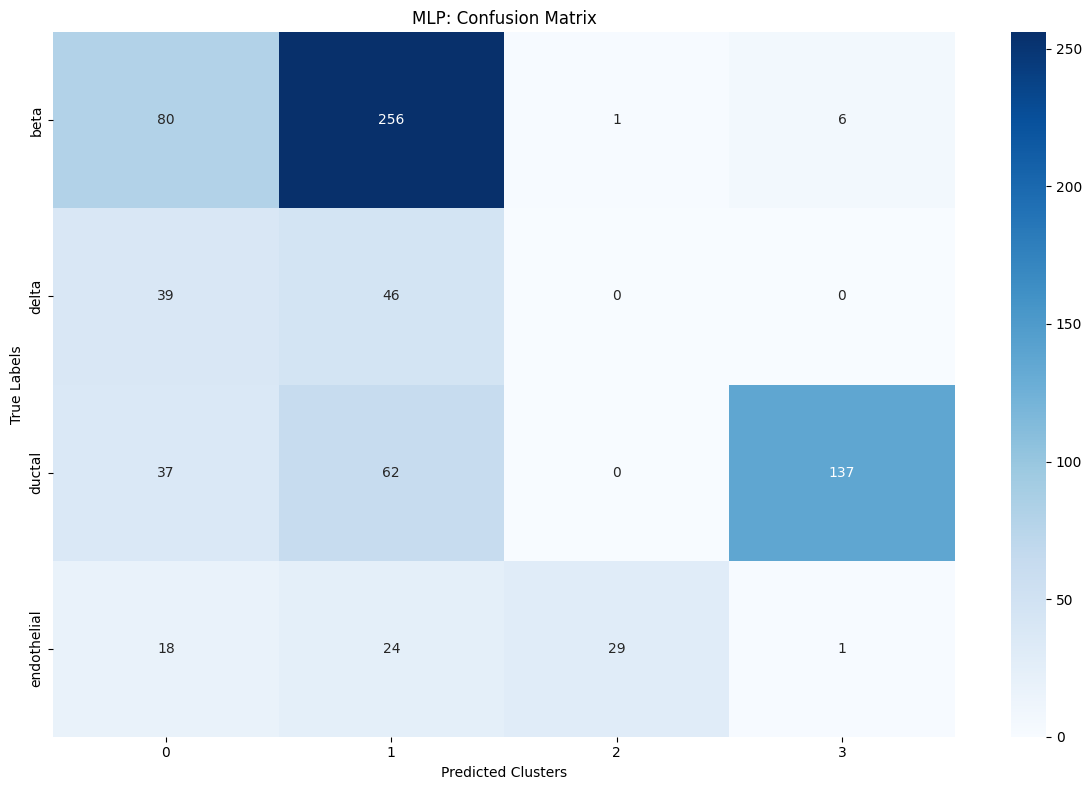

[INFO] Running marker gene analysis...


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


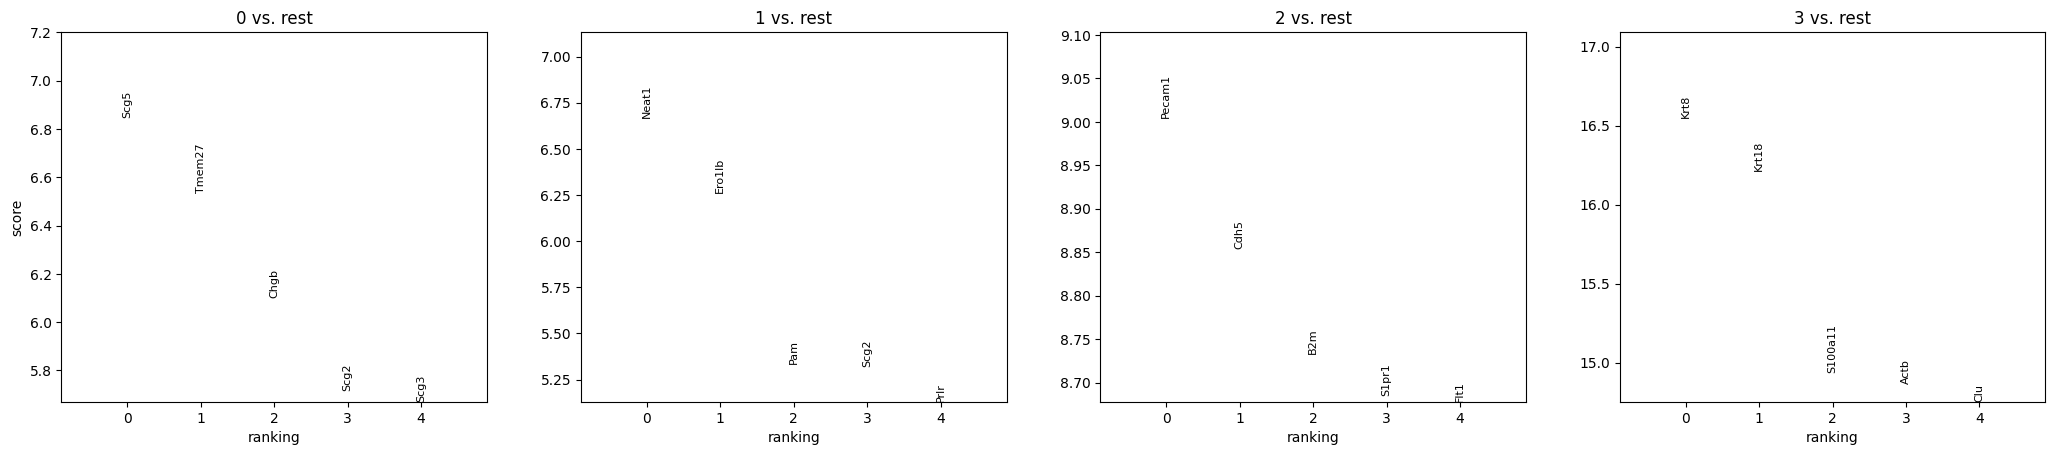


MLP Cluster 0 top marker genes:
  Scg5: logFC=nan, adj.p=1.5e-08 ***
  Tmem27: logFC=nan, adj.p=6.31e-08 ***
  Chgb: logFC=nan, adj.p=6.96e-07 ***
  Scg2: logFC=nan, adj.p=5.49e-06 ***
  Scg3: logFC=nan, adj.p=5.7e-06 ***

MLP Cluster 1 top marker genes:
  Neat1: logFC=nan, adj.p=5.31e-10 ***
  Ero1lb: logFC=nan, adj.p=6.72e-09 ***
  Pam: logFC=nan, adj.p=1.19e-06 ***
  Scg2: logFC=nan, adj.p=1.27e-06 ***
  Prlr: logFC=nan, adj.p=3.23e-06 ***

MLP Cluster 2 top marker genes:
  Pecam1: logFC=nan, adj.p=4.31e-16 ***
  Cdh5: logFC=nan, adj.p=8.49e-16 ***
  B2m: logFC=nan, adj.p=1.61e-15 ***
  S1pr1: logFC=nan, adj.p=1.61e-15 ***
  Flt1: logFC=nan, adj.p=1.61e-15 ***

MLP Cluster 3 top marker genes:
  Krt8: logFC=nan, adj.p=3.09e-58 ***
  Krt18: logFC=nan, adj.p=4.18e-56 ***
  S100a11: logFC=nan, adj.p=1.28e-47 ***
  Actb: logFC=nan, adj.p=2.83e-47 ***
  Clu: logFC=nan, adj.p=1.19e-46 ***
[INFO] Generating visualizations (PCA, UMAP)...


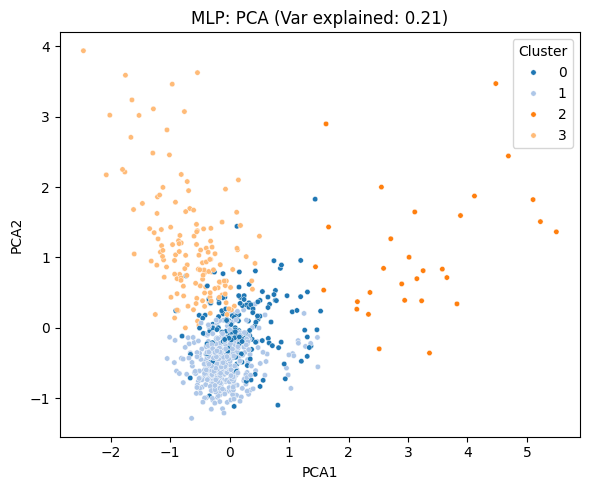

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


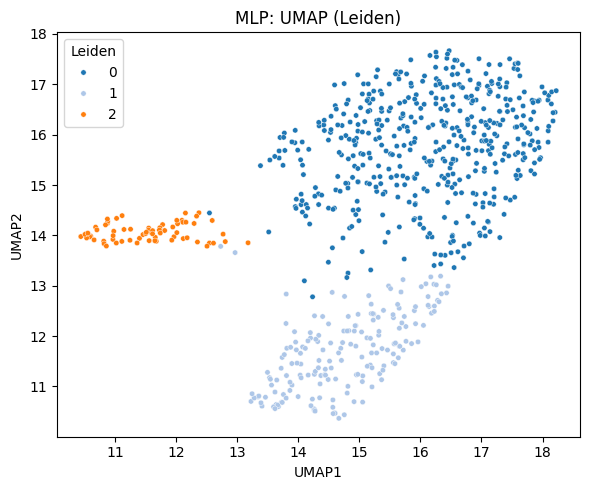

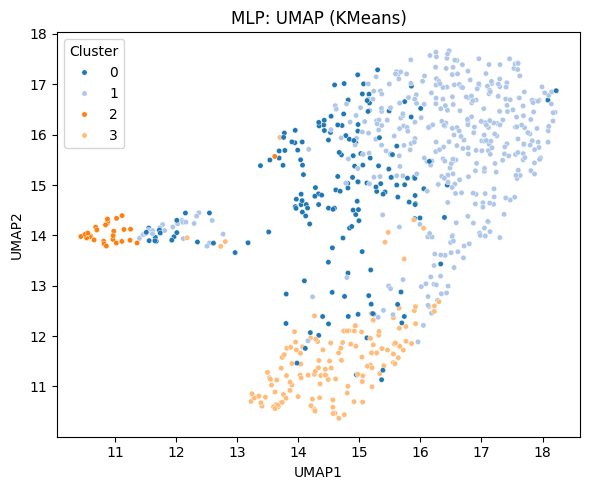

In [23]:
# @title
# ---- DEVICE SETUP ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Using device:", device)

# ---- 1. Same preprocessing as main method ----
def preprocess_sctransform(adata, regress_vars=None, hvg_n=2000):
    print("[INFO] Preprocessing with SCTransform-like workflow (highly variable genes + regression)...")
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=hvg_n)
    adata = adata[:, adata.var['highly_variable']]
    if regress_vars is not None:
        sc.pp.regress_out(adata, regress_vars)
    sc.pp.scale(adata)
    print("[INFO] Preprocessing completed.")
    return adata

# ---- 2. MLP Autoencoder Model ----
class MLPAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], latent_dim=32, dropout=0.2):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        # Latent layer
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        # Output layer
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

    def encode(self, x):
        return self.encoder(x)

# ---- 3. Alternative: Simple MLP for dimensionality reduction ----
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256], output_dim=32, dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# ---- 4. Contrastive Loss for MLP ----
def contrastive_loss_mlp(embeddings, drop_prob=0.2, temperature=0.5):
    """
    Contrastive loss for MLP embeddings using dropout augmentation
    """
    # Dropout-based augmentation
    mask = (torch.rand_like(embeddings) > drop_prob).float()
    embeddings_aug = embeddings * mask
    N = embeddings.shape[0]
    z1 = F.normalize(embeddings, dim=1)
    z2 = F.normalize(embeddings_aug, dim=1)
    representations = torch.cat([z1, z2], dim=0)
    similarity_matrix = torch.matmul(representations, representations.T)
    mask_eye = torch.eye(2*N, dtype=torch.bool, device=embeddings.device)
    similarity_matrix = similarity_matrix.masked_fill(mask_eye, -9e15)
    positives = torch.cat([torch.diag(similarity_matrix, N), torch.diag(similarity_matrix, -N)], dim=0)
    negatives = similarity_matrix[~mask_eye].view(2*N, -1)
    logits = torch.cat([positives.unsqueeze(1), negatives], dim=1) / temperature
    labels = torch.zeros(2*N, dtype=torch.long, device=embeddings.device)
    loss = F.cross_entropy(logits, labels)
    return loss.item(), loss

# ---- 5. Training Functions ----
def train_mlp_autoencoder(data, model_type='autoencoder', hidden_dims=[512, 256, 128],
                         latent_dim=32, epochs=100, batch_size=256, learning_rate=0.001,
                         early_stop_patience=15, early_stop_delta=1e-4, device="cuda"):
    """
    Train MLP autoencoder or simple MLP with contrastive loss
    """
    print(f"[INFO] Training MLP {model_type} with contrastive loss...")

    n_cells, n_genes = data.shape
    data_tensor = torch.tensor(data, dtype=torch.float32)

    # Create DataLoader
    dataset = torch.utils.data.TensorDataset(data_tensor)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    if model_type == 'autoencoder':
        model = MLPAutoencoder(n_genes, hidden_dims, latent_dim).to(device)
    else:  # simple MLP
        model = SimpleMLP(n_genes, hidden_dims, latent_dim).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_loss = float("inf")
    patience = 0

    for epoch in range(epochs):
        epoch_loss = 0
        n_batches = 0

        for batch_data, in dataloader:
            batch_data = batch_data.to(device)
            optimizer.zero_grad()

            if model_type == 'autoencoder':
                latent, reconstructed = model(batch_data)
                # Reconstruction loss
                recon_loss = F.mse_loss(reconstructed, batch_data)
                # Contrastive loss on latent space
                cont_loss_val, cont_loss = contrastive_loss_mlp(latent, drop_prob=0.2, temperature=0.5)
                # Combined loss
                total_loss = recon_loss + 0.1 * cont_loss  # weight contrastive loss lower
            else:
                embeddings = model(batch_data)
                cont_loss_val, total_loss = contrastive_loss_mlp(embeddings, drop_prob=0.2, temperature=0.5)

            total_loss.backward()
            optimizer.step()

            epoch_loss += total_loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches

        # Early stopping
        if avg_loss + early_stop_delta < best_loss:
            best_loss = avg_loss
            patience = 0
        else:
            patience += 1

        if patience > early_stop_patience:
            print(f"[INFO] Early stopped at epoch {epoch+1} (best loss: {best_loss:.4f})")
            break

        if (epoch+1) % 20 == 0 or epoch == 0:
            print(f"[INFO] Epoch {epoch+1}, average loss: {avg_loss:.4f}")

    # Get final embeddings
    model.eval()
    with torch.no_grad():
        data_tensor = data_tensor.to(device)
        if model_type == 'autoencoder':
            final_emb, _ = model(data_tensor)
        else:
            final_emb = model(data_tensor)
        final_emb = final_emb.cpu().numpy()

    print(f"[INFO] Training completed. Final embeddings shape: {final_emb.shape}")
    return final_emb

# ---- 6. Clustering and Evaluation ----
def cluster_and_eval_mlp(final_emb, cells, adata, n_clusters=None, leiden_res_list=None):
    print("[INFO] Running clustering (Leiden + KMeans)...")

    if leiden_res_list is None:
        leiden_res_list = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

    adata.obsm['X_mlp'] = final_emb
    sc.pp.neighbors(adata, use_rep='X_mlp', n_neighbors=15)

    leiden_silhouettes = []
    leiden_label_sets = {}

    # Leiden clustering
    for res in leiden_res_list:
        sc.tl.leiden(adata, resolution=res, key_added=f'mlp_leiden_{res}')
        leiden_labels = adata.obs[f'mlp_leiden_{res}'].astype(str).reindex(cells).fillna('NA').tolist()
        leiden_labels_num = pd.factorize(leiden_labels)[0]

        if len(set(leiden_labels_num)) > 1:
            sil = silhouette_score(final_emb, leiden_labels_num)
        else:
            sil = -1
        leiden_silhouettes.append(sil)
        leiden_label_sets[res] = leiden_labels
        print(f"[INFO] Leiden res={res:.2f}, clusters={len(set(leiden_labels))}, silhouette={sil:.3f}")

    best_res = leiden_res_list[np.argmax(leiden_silhouettes)]
    best_leiden_labels = leiden_label_sets[best_res]
    best_leiden_silhouette = max(leiden_silhouettes)

    # KMeans clustering
    if n_clusters is None:
        sil_scores = []
        for k in range(3, 15):
            labels = KMeans(n_clusters=k, random_state=42).fit_predict(final_emb)
            sil_scores.append(silhouette_score(final_emb, labels))
        n_clusters = np.argmax(sil_scores) + 3
        print(f"[INFO] Using elbow method: n_clusters={n_clusters}")
    elif n_clusters == "unique":
        n_clusters = adata.obs['assigned_cluster'].nunique()
        print(f"[INFO] Using unique assigned clusters: n_clusters={n_clusters}")

    kmeans_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(final_emb)
    kmeans_silhouette = silhouette_score(final_emb, kmeans_labels)

    # Evaluation metrics
    if 'assigned_cluster' in adata.obs:
        true_labels = adata.obs.loc[cells, 'assigned_cluster']
        metrics = {
            'Leiden ARI': adjusted_rand_score(true_labels, best_leiden_labels),
            'Leiden NMI': normalized_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden AMI': adjusted_mutual_info_score(true_labels, best_leiden_labels),
            'Leiden Silhouette': best_leiden_silhouette,
            'KMeans ARI': adjusted_rand_score(true_labels, kmeans_labels),
            'KMeans NMI': normalized_mutual_info_score(true_labels, kmeans_labels),
            'KMeans AMI': adjusted_mutual_info_score(true_labels, kmeans_labels),
            'KMeans Silhouette': kmeans_silhouette
        }
        print("[INFO] MLP Clustering metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.3f}")

        # Confusion matrix
        true_labels = adata.obs.loc[cells, 'assigned_cluster'].astype(str).values
        pred_labels = kmeans_labels.astype(str)
        cm_df = pd.crosstab(pd.Series(true_labels, name="True"), pd.Series(pred_labels, name="Predicted"))
        plt.figure(figsize=(12,8))
        sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted Clusters")
        plt.ylabel("True Labels")
        plt.title("MLP: Confusion Matrix")
        plt.tight_layout()
        plt.show()

    return best_leiden_labels, kmeans_labels, best_res, best_leiden_silhouette, kmeans_silhouette

# ---- 7. Visualization ----
def visualize_mlp(final_emb, cluster_labels, cells, leiden_labels=None):
    print("[INFO] Generating visualizations (PCA, UMAP)...")

    # PCA
    pca = PCA(n_components=2)
    pca_proj = pca.fit_transform(final_emb)
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=pca_proj[:,0], y=pca_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title(f'MLP: PCA (Var explained: {pca.explained_variance_ratio_.sum():.2f})')
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_proj = reducer.fit_transform(final_emb)

    if leiden_labels is not None:
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=leiden_labels, palette='tab20', s=15)
        plt.title("MLP: UMAP (Leiden)")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.legend(title="Leiden")
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=umap_proj[:,0], y=umap_proj[:,1], hue=cluster_labels, palette='tab20', s=15)
    plt.title("MLP: UMAP (KMeans)")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()


# ---- 9. Main Pipeline ----
def run_mlp_baseline_pipeline(
    expr_csv, metadata_cols=['barcode', 'assigned_cluster'],
    regress_vars=None, hvg_n=2000, model_type='autoencoder',
    hidden_dims=[512, 256, 128], latent_dim=32, epochs=100, batch_size=256,
    learning_rate=0.001, early_stop_patience=15, early_stop_delta=1e-4,
    top_n_marker_genes=5, n_clusters=None, rare_cell_thresh=40,
    device="cuda"
):
    print("[INFO] === MLP BASELINE (No Graph, No Pathway Information) ===")
    print("[INFO] Loading expression matrix...")

    df = pd.read_csv(expr_csv, index_col=0)
    metadata = df[metadata_cols]
    expr_df = df.drop(columns=metadata_cols)
    expr_df = expr_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    adata = sc.AnnData(expr_df)
    adata.obs = metadata

    # Fix duplicate names
    if adata.obs_names.duplicated().any():
        print("[WARNING] Found duplicate cell names. Making unique...")
        adata.obs_names_make_unique()
    if adata.var_names.duplicated().any():
        print("[WARNING] Found duplicate gene names. Making unique...")
        adata.var_names_make_unique()

    # Remove rare cell clusters
    if 'assigned_cluster' in adata.obs:
        counts = adata.obs['assigned_cluster'].value_counts()
        keep = counts[counts >= rare_cell_thresh].index
        before = adata.n_obs
        adata = adata[adata.obs['assigned_cluster'].isin(keep)]
        print(f"[INFO] Removed rare cell types (<{rare_cell_thresh} cells). {before} → {adata.n_obs} cells kept.")

    # Preprocess
    adata = preprocess_sctransform(adata, regress_vars=regress_vars, hvg_n=hvg_n)

    cells = list(adata.obs_names)
    data = adata.X

    # Train MLP
    final_emb = train_mlp_autoencoder(
        data, model_type=model_type, hidden_dims=hidden_dims, latent_dim=latent_dim,
        epochs=epochs, batch_size=batch_size, learning_rate=learning_rate,
        early_stop_patience=early_stop_patience, early_stop_delta=early_stop_delta,
        device=device
    )

    # Clustering and evaluation
    leiden_labels, kmeans_labels, best_res, leiden_sil, kmeans_sil = cluster_and_eval_mlp(
        final_emb, cells, adata, n_clusters=n_clusters
    )

    # Marker gene analysis
    print("[INFO] Running marker gene analysis...")
    adata.obs["cluster"] = kmeans_labels.astype(str)
    sc.tl.rank_genes_groups(adata, groupby="cluster", method="wilcoxon", use_raw=False)
    sc.pl.rank_genes_groups(adata, n_genes=top_n_marker_genes, sharey=False)

    markers_df = sc.get.rank_genes_groups_df(adata, group=None)
    for c in sorted(adata.obs["cluster"].unique()):
        top_genes = markers_df[markers_df["group"] == c].head(top_n_marker_genes)
        print(f"\nMLP Cluster {c} top marker genes:")
        for _, row in top_genes.iterrows():
            sig = (
                "***" if row["pvals_adj"] < 0.001 else
                "**" if row["pvals_adj"] < 0.01 else
                "*" if row["pvals_adj"] < 0.05 else ""
            )
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, adj.p={row['pvals_adj']:.3g} {sig}")

    # Visualizations
    visualize_mlp(final_emb, kmeans_labels, cells, leiden_labels)


# Example usage:
run_mlp_baseline_pipeline(
    '/content/drive/MyDrive/Pathway GNN Project/pancreas5.csv',
    model_type=None, epochs=150, n_clusters="unique"
)